# <b>세미1차_전화 해지 여부 분류
* https://dacon.io/competitions/official/236075/data


# -------------------------------------------------------------------------------

In [1]:
import sys
# !{sys.executable} -m pip install lifelines==0.27.8
import sys
# !{sys.executable} -m pip install scikit-survival
import sys
#!{sys.executable} -m pip install shap==0.42.1

import os
import shap
import shap as shap_lib   # ✅ 충돌 방지: shap 모듈은 shap_lib로 고정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#-----------------------------------------------------------------------------------  인코딩
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#-----------------------------------------------------------------------------------  정규화
from sklearn.preprocessing import MinMaxScaler,  RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline

#-----------------------------------------------------------------------------------  모델
from sklearn.linear_model import LogisticRegression          # 선형모델
from sklearn.tree import DecisionTreeClassifier              # 트리모델
from sklearn.ensemble import RandomForestClassifier          # 배깅모델   : 데이터N,  똑같은모델N(앙상블)
from lightgbm import LGBMClassifier                          # 부스팅모델 : 데이터1,  다양한모델N(앙상블)
from xgboost import XGBClassifier
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv

#-----------------------------------------------------------------------------------  평가
from sklearn.metrics import accuracy_score,      f1_score,  precision_score , recall_score,         roc_auc_score
from sklearn.metrics import                                 precision_recall_curve,                 roc_curve
from sklearn.metrics import classification_report,          confusion_matrix

#-----------------------------------------------------------------------------------  교차검증
from sklearn.model_selection import train_test_split,                     KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_validate,      GridSearchCV

import warnings
warnings.filterwarnings('ignore')
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy.stats import pearsonr, spearmanr

sns.set()

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"



#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# #-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# # from IPython.core.display import display, HTML
# from IPython.display import display, HTML
# display(HTML("<style>.container{width:100% !important;}</style>"))
# pd.set_option('display.max_rows', 100)
# pd.set_option('display.max_columns', 100)
# pd.set_option('max_colwidth', None)

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


# <b>1. 데이터 확인

## <b>1-1. 데이터 불러오기

In [2]:
df = pd.read_csv(r"C:\IT\workspace_ptyhon\ST\train.csv")
#df_sample = pd.read_csv(r"C:\IT\workspace_ptyhon\ST\sample_submission.csv")
#df_test = pd.read_csv(r"C:\IT\workspace_ptyhon\ST\test.csv")

## <b>1-2 데이터 크기 확인(shape)

In [3]:
df.shape

(30200, 14)

## <b>1-3 데이터 구조 확인(info)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30200 entries, 0 to 30199
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       30200 non-null  object 
 1   가입일      30200 non-null  int64  
 2   음성사서함이용  30200 non-null  int64  
 3   주간통화시간   30200 non-null  float64
 4   주간통화횟수   30200 non-null  int64  
 5   주간통화요금   30200 non-null  float64
 6   저녁통화시간   30200 non-null  float64
 7   저녁통화횟수   30200 non-null  int64  
 8   저녁통화요금   30200 non-null  float64
 9   밤통화시간    30200 non-null  float64
 10  밤통화횟수    30200 non-null  int64  
 11  밤통화요금    30200 non-null  float64
 12  상담전화건수   30200 non-null  int64  
 13  전화해지여부   30200 non-null  int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 3.2+ MB


## <b>1-4 결측치 확인(isnull)
* 결측치 없음

In [5]:
df.isnull().sum()

ID         0
가입일        0
음성사서함이용    0
주간통화시간     0
주간통화횟수     0
주간통화요금     0
저녁통화시간     0
저녁통화횟수     0
저녁통화요금     0
밤통화시간      0
밤통화횟수      0
밤통화요금      0
상담전화건수     0
전화해지여부     0
dtype: int64

## <b>1-5 피쳐 확인(columns)

In [6]:
df.columns

Index(['ID', '가입일', '음성사서함이용', '주간통화시간', '주간통화횟수', '주간통화요금', '저녁통화시간',
       '저녁통화횟수', '저녁통화요금', '밤통화시간', '밤통화횟수', '밤통화요금', '상담전화건수', '전화해지여부'],
      dtype='object')

## <b>1-6 형태 확인(describe)

In [7]:
df.describe()

,가입일,음성사서함이용,주간통화시간,주간통화횟수,주간통화요금,저녁통화시간,저녁통화횟수,저녁통화요금,밤통화시간,밤통화횟수,밤통화요금,상담전화건수,전화해지여부
count,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000
mean,159.732649,12.037815,250.563457,159.175728,41.091447,263.247215,158.474536,25.394260,263.438285,157.047417,12.074648,2.288079,0.109868
std,123.752781,24.925334,84.403350,101.573057,23.179017,74.064922,102.200293,8.146126,73.778416,101.721601,9.414261,2.050746,0.312730
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000,0.000000,20.800000,20.000000,1.040000,0.000000,0.000000
25%,63.000000,0.000000,222.800000,88.000000,24.400000,223.700000,87.000000,22.220000,223.700000,87.000000,4.700000,2.000000,0.000000
50%,118.000000,1.000000,234.000000,117.500000,30.800000,243.000000,112.000000,23.320000,242.800000,108.000000,9.080000,2.000000,0.000000
75%,228.000000,22.000000,289.600000,223.000000,45.900000,290.300000,223.000000,28.820000,290.500000,222.000000,20.290000,2.000000,0.000000
max,2212.000000,1112.000000,481.900000,489.000000,118.600000,481.600000,489.000000,49.980000,481.800000,490.000000,44.980000,11.000000,1.000000


## <b>1-7 중복값확인(duplicated)

In [8]:
def duplicate_report(df):
    total_rows = len(df)
    
    report = pd.DataFrame({
        'dtype': df.dtypes,
        '고유값개수': df.nunique(),
    })
    
    report['중복개수'] = total_rows - report['고유값개수']
    report['중복비율'] = (report['중복개수'] / total_rows).round(4)
    
    return report.sort_values('중복비율', ascending=False)

duplicate_report(df)

dup_summary = duplicate_report(df)


,dtype,고유값개수,중복개수,중복비율
전화해지여부,int64,2,30198,0.9999
상담전화건수,int64,11,30189,0.9996
음성사서함이용,int64,76,30124,0.9975
밤통화횟수,int64,233,29967,0.9923
주간통화횟수,int64,239,29961,0.9921
저녁통화횟수,int64,241,29959,0.9920
가입일,int64,345,29855,0.9886
주간통화요금,float64,735,29465,0.9757
밤통화요금,float64,1216,28984,0.9597
저녁통화요금,float64,1840,28360,0.9391


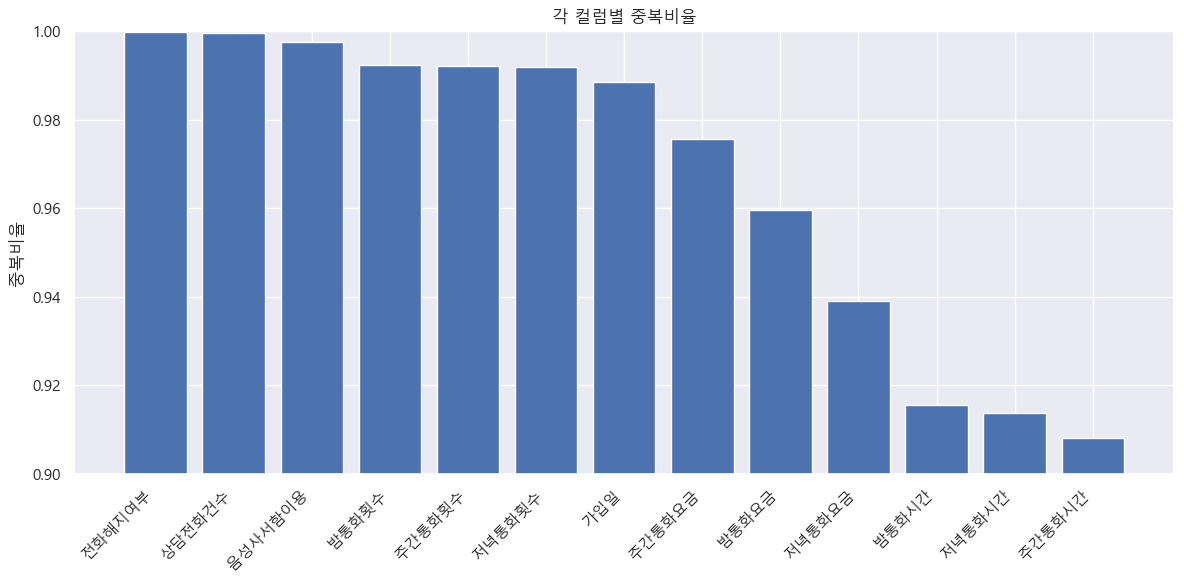

In [9]:
# 중복비율이 0보다 큰 컬럼만 선택 (ID 자동 제외)
plot_data = dup_summary[dup_summary['중복비율'] > 0]

plt.figure(figsize=(12, 6))
plt.bar(plot_data.index, plot_data['중복비율'])

plt.xticks(rotation=45, ha='right')
plt.ylabel('중복비율')
plt.title('각 컬럼별 중복비율')

plt.ylim(0.9, 1.0)
plt.tight_layout()
plt.show();


In [10]:
df.head(3)

,ID,가입일,음성사서함이용,주간통화시간,주간통화횟수,주간통화요금,저녁통화시간,저녁통화횟수,저녁통화요금,밤통화시간,밤통화횟수,밤통화요금,상담전화건수,전화해지여부
0,TRAIN_00000,329,0,99.2,93,27.3,268.8,68,28.92,262.9,328,32.89,2,0
1,TRAIN_00001,2,80,323.9,323,83.7,269.4,326,32.09,322.8,209,32.32,2,0
2,TRAIN_00002,93,28,282.4,323,34.2,207.0,322,32.82,280.8,328,8.28,0,0


## <b>1-8. 컬럼명 바꾸기

In [11]:
original_columns = df.columns.tolist() #원본 컬럼 백업 

# 컬럼명 바꾸기 & 도메인 지식
col_rename_map = {
    'ID': 'id',
    '전화해지여부': 'target',
    '가입일': 'tenure', # 가입기간이 짧으면 해지 가능성 높음, 장기 고객일수록 해지 가능성이 낮음
    '음성사서함이용': 'vm_count', # 음성사서함을 자주 쓰는 고객은 서비스 활용도가 높아 해지 가능성이 낮을 수 있음

    '주간통화시간': 'day_minutes', # 통화량이 적으면 서비스 활용도가 낮아 해지 가능성이 높을 수 있음
    '주간통화횟수': 'day_calls', # 통화 횟수가 적으면 서비스 사용률 낮음 → 해지 가능성 ↑
    '주간통화요금': 'day_charge', # 요금이 낮으면 서비스 활용도 낮음 → 해지 가능성 ↑ 요금이 높으면 서비스 의존도 높음→ 해지 가능성 ↓ (단, 과도한 요금은 불만 요인이 될 수도 있음)

    '저녁통화시간': 'eve_minutes', # 저녁 통화가 많으면 생활 패턴과 연결 → 충성 고객 가능성 ↑
    '저녁통화횟수': 'eve_calls', # 빈도가 적으면 해지 가능성 ↑
    '저녁통화요금': 'eve_charge', # 요금 낮으면 사용량 적음 → 해지 가능성 ↑

    '밤통화시간': 'night_minutes', # 밤 시간대 사용이 많으면, 서비스 활용도가 높아 해지 가능성 낮음
    '밤통화횟수': 'night_calls', # 낮은 빈도 → 해지 가능성 ↑
    '밤통화요금': 'night_charge', # 요금 낮으면 사용량 적음 → 해지 가능성 ↑

    '상담전화건수': 'cs_calls' #상담전화가 많을수록 해지 가능성 ↑ 불만, 문제발생, 서비스 문의
}
# 컬럼명 변환
df = df.rename(columns=col_rename_map)

print(df.columns.tolist())

['id', 'tenure', 'vm_count', 'day_minutes', 'day_calls', 'day_charge', 'eve_minutes', 'eve_calls', 'eve_charge', 'night_minutes', 'night_calls', 'night_charge', 'cs_calls', 'target']


## <b>1-9. 불필요한 id 제거

In [12]:
df = df.drop(columns=['id'])

In [13]:
print("Shape:", df.shape)
display(df.head(3))

Shape: (30200, 13)


,tenure,vm_count,day_minutes,day_calls,day_charge,eve_minutes,eve_calls,eve_charge,night_minutes,night_calls,night_charge,cs_calls,target
0,329,0,99.2,93,27.3,268.8,68,28.92,262.9,328,32.89,2,0
1,2,80,323.9,323,83.7,269.4,326,32.09,322.8,209,32.32,2,0
2,93,28,282.4,323,34.2,207.0,322,32.82,280.8,328,8.28,0,0


# -------------------------------------------------------------------------

# <b>2. EDA  

## <b>2-1. 타겟(churn) 구조 확인
* EDA 첫 단계는 “타겟(해지여부)의 분포와 구조를 확인하는 것!
* 클래스 불균형 여부 확인
    - 불균형이면 accuracy(정확도)는 의미 없음 → F1 / ROC-AUC 중심으로 가야 함
    - class_weight를 줘야 할지 필요 여부 결정
* 이탈률(해지율)이 얼마인지 확인
    - 이탈률이 10%라면 → 고위험군 찾기
    - 이탈률이 40%라면 → 잔존 고객 특성 분석이 더 중요

### <b>2-1-1. 타겟 분포

In [14]:
df['target'].value_counts()
df['target'].value_counts(normalize=True)

target
0    26882
1     3318
Name: count, dtype: int64

target
0    0.890132
1    0.109868
Name: proportion, dtype: float64

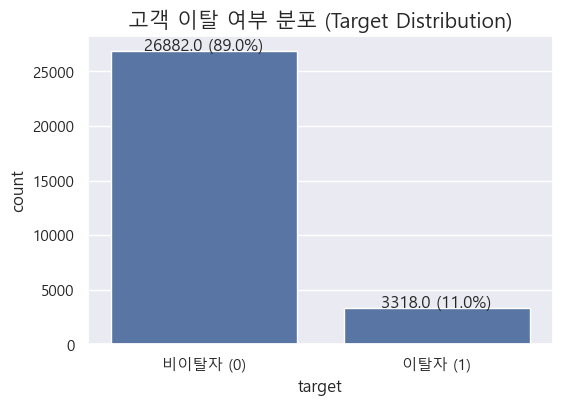

In [15]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='target', data=df)

total = len(df['target'])
for p in ax.patches: #퍼센트&건수표시로 가독성높히기
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 3,
            f'{height} ({height/total:.1%})', ha="center")

plt.title('고객 이탈 여부 분포 (Target Distribution)', fontsize=15)
plt.xticks([0, 1], ['비이탈자 (0)', '이탈자 (1)']) 
plt.show();

<Axes: xlabel='target', ylabel='cs_calls'>

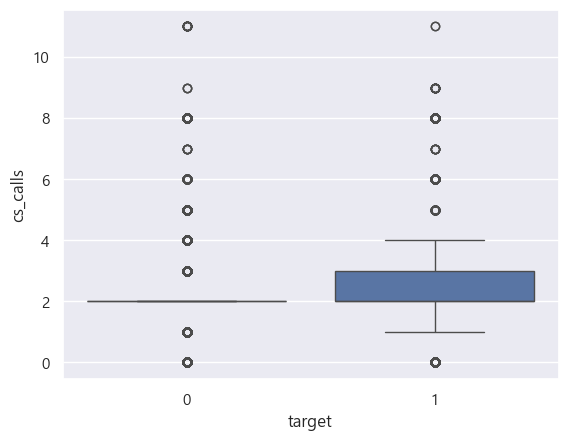

In [16]:
sns.boxplot(x='target', y='cs_calls', data=df)

### <b>2-1-2. 타겟 기준 평균 비교
* 1차 영향도 스캔 : 
    - 상담전화가 진짜 차이 나는지, tenure가 차이 나는지 등 확인
    - 가설이 “감”인지 “사실”인지 1차 확인 가능함!

In [17]:
# 이탈자(해지)와 비이탈자(유지)의 평균과 표준편차를 비교하여 어떤 특성이 이탈(해지)에 영향을 미치는지 분석

# 1. 평균/표준편차 집계
g = df.groupby('target').agg(['mean','std'])

# 2. 평균 차이 계산 (해지 - 유지)
mean_diff = df.groupby('target').mean().loc[1] - df.groupby('target').mean().loc[0]

# 3. 빈 행을 문자열("")로 생성
diff_row = pd.DataFrame(
    [[""] * g.shape[1]],
    columns=g.columns,
    index=['mean_diff(1-0)']
)

# 4. mean 컬럼에만 값 채우기
for col in mean_diff.index:
    diff_row[(col, 'mean')] = mean_diff[col]

# 5. 기존 표에 행 추가
result = pd.concat([g, diff_row])

result


tenure               vm_count            day_minutes  \
                      mean         std       mean        std        mean   
0               159.441857  124.193729  12.587159  25.566918  249.674619   
1               162.088608   120.11289   7.587101  18.348552  257.764708   
mean_diff(1-0)    2.646751              -5.000058               8.090089   

                            day_calls             day_charge             ...  \
                      std        mean         std       mean        std  ...   
0               84.830161  158.784131  101.747847  41.669660  23.536478  ...   
1               80.513591  162.348403  100.104352  36.406841  19.427776  ...   
mean_diff(1-0)               3.564272              -5.262819             ...   

               eve_charge           night_minutes            night_calls  \
                     mean       std          mean        std        mean   
0               25.389364  8.223539    263.512730  74.529181  157.158954   
1               25.433927  7.490529    262.835142  67.395499  156.143761   
mean_diff(1-0)   0.044562               -0.677588              -1.015193   

                           night_charge            cs_calls            
                       std         mean       std      mean       std  
0                101.78506    12.026648  9.432624  2.246931  2.018357  
1               101.216735    12.463539  9.256371  2.621459  2.269361  
mean_diff(1-0)                 0.436891            0.374528            

[3 rows x 24 columns]

### <b>2-1-3. 가설 1 검증
* 상담전화건수가 많을수록 해지 확률이 높다 (불만 고객 가설)

In [18]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['target']   # 이탈 데이터라면 거의 필수
)

train.groupby('target')['cs_calls'].agg(['mean','std','median','count'])

,mean,std,median,count
target,,,,
0,2.252209,2.028328,2.0,21506
1,2.600603,2.272821,2.0,2654


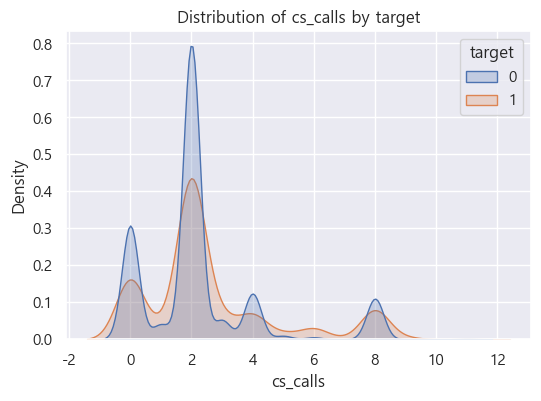

In [19]:
plt.figure(figsize=(6,4))
sns.kdeplot(data=train, x='cs_calls', hue='target', fill=True, common_norm=False)
plt.title("Distribution of cs_calls by target")
plt.show();

| 가설              | 결과            |
| --------------- | ------------- |
| 상담전화 많을수록 해지 증가 | ✅ 시각적으로 지지됨   |
| 명확한 차이 존재       | ✅ 있음          |
| 완전 분리           | ❌ 아님 (현실적 결과) |


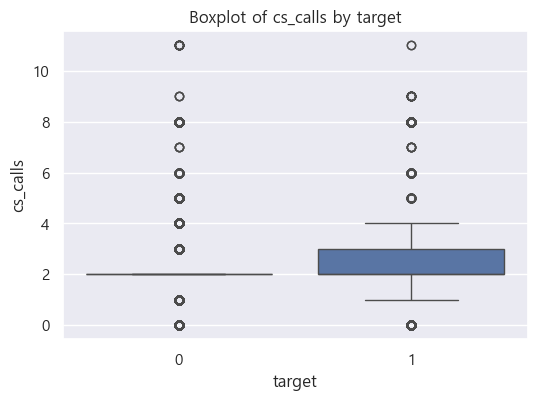

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(data=train, x='target', y='cs_calls')
plt.title("Boxplot of cs_calls by target")
plt.show();

* 중앙값 비교 : 이탈 고객이 전반적으로 상담을 더 많이 함

In [21]:
from scipy.stats import mannwhitneyu

a = df[df['target']==0]['cs_calls']
b = df[df['target']==1]['cs_calls']

mannwhitneyu(a, b)

MannwhitneyuResult(statistic=40644601.0, pvalue=4.346357977076678e-20)

| 기준        | 의미           |
| --------- | ------------ |
| p < 0.05  | 유의미          |
| p < 0.01  | 매우 유의미       |
| p < 0.001 | 극도로 유의미      |
| **현재 결과** | 🚨 압도적으로 유의미 |

* 상담전화 횟수는 이탈 고객과 통계적으로 유의미한 차이를 보임

In [22]:
n1 = len(a)
n2 = len(b)
U = 40644601.0

effect_size = 1 - (2*U)/(n1*n2)
effect_size

0.08862963666045864

| 효과크기 | 의미 |
| ---- | -- |
| ~0.1 | 작음 |
| ~0.3 | 중간 |
| ≥0.5 | 큼  |

* (effect size=0.09) : 단일 변수로서의 영향력은 제한적이며 다른 사용 패턴 변수와 결합될 때 예측력이 강화될 가능성이 높다.

<Figure size 700x400 with 0 Axes>

<Axes: xlabel='cs_bin', ylabel='target'>

Text(0.5, 1.0, 'Churn rate by cs_calls quartile')

([0, 1], [Text(0, 0, '(-0.001, 2.0]'), Text(1, 0, '(2.0, 11.0]')])

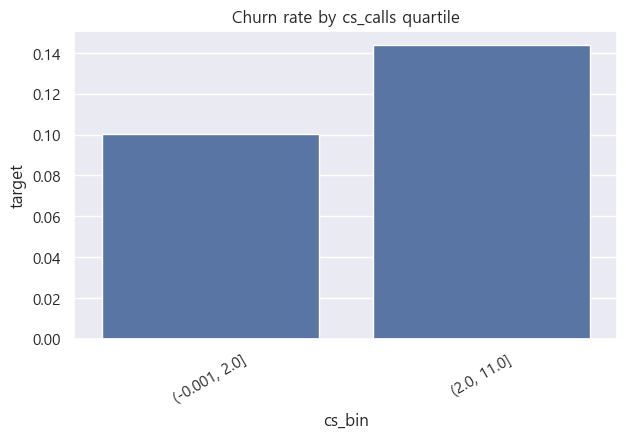

,cs_bin,target
0,"(-0.001, 2.0]",0.100486
1,"(2.0, 11.0]",0.143731


In [23]:
train['cs_bin'] = pd.qcut(train['cs_calls'], 4, duplicates='drop')

churn_rate = train.groupby('cs_bin')['target'].mean().reset_index()

plt.figure(figsize=(7,4))
sns.barplot(data=churn_rate, x='cs_bin', y='target')
plt.title("Churn rate by cs_calls quartile")
plt.xticks(rotation=30)
plt.show()

churn_rate

| 상담 횟수 구간 | 이탈률        |
| -------- | ---------- |
| ≤ 2회     | **10.05%** |
| ≥ 3회     | **14.37%** |


In [24]:
X = train[['cs_calls']]
y = train['target']

model = LogisticRegression()
score = cross_val_score(model, X, y, cv=5, scoring='f1_macro')

print("Macro F1 (cs_calls only):", score.mean())

Macro F1 (cs_calls only): 0.47094118060836176


| F1   | 의미           |
| ---- | ------------ |
| 0.5  | 거의 랜덤 수준     |
| 0.6  | 약한 예측력       |
| 0.7  | 실무 usable 시작 |
| 0.8+ | 강력 모델        |


<font size=10><가설1에 대한 종합 결론>

| 분석           | 결론         |
| ------------ | ---------- |
| KDE          | 오른쪽 이동     |
| Boxplot      | 중앙값 상승     |
| Mann-Whitney | 매우 유의      |
| Effect size  | 작음         |
| 단일 모델        | 약함         |
| 분위 이탈률       | ✅ 실제 증가 확인 |

* 상담전화 횟수는 고객 이탈과 통계적으로 유의미한 관계를 보였으며 상담 빈도가 높은 고객군에서 이탈률이 약 1.4배 높게 나타남.
* 단일 변수 기반 예측력은 제한적
* 상담 이력은 이탈의 직접 원인이라기보다 고객 불만 누적을 나타내는 조기 위험 신호로 해석됨.


### <b>2-1-4. 타겟 중심 EDA (수치형)
* 1️⃣ 수치형 변수 효과 크기 Top 10
* 2️⃣ Spearman 상관 Top 10
* 3️⃣ 분위수별 해지율 패턴 분석
* 4️⃣ 단조 증가/감소 변수 자동 탐지
* 5️⃣ 상위 변수 분포 시각화
* 6️⃣ 최종 “핵심 변수 후보 리스트” 출력


🔹 효과 크기 Top 10


,feature,mean_diff(1-0),cohens_d,abs_effect
4,day_charge,-5.262819,-0.243873,0.243873
1,vm_count,-5.000058,-0.224698,0.224698
11,cs_calls,0.374528,0.174399,0.174399
2,day_minutes,8.090089,0.097824,0.097824
10,night_charge,0.436891,0.046752,0.046752
3,day_calls,3.564272,0.035314,0.035314
0,tenure,2.646751,0.021664,0.021664
6,eve_calls,-1.397518,-0.013750,0.013750
9,night_calls,-1.015193,-0.010002,0.010002
8,night_minutes,-0.677588,-0.009537,0.009537



🔹 Spearman 상관 Top 10


,feature,spearman_corr,abs_corr
4,day_charge,-0.062199,0.062199
1,vm_count,-0.060345,0.060345
2,day_minutes,0.056487,0.056487
11,cs_calls,0.052821,0.052821
10,night_charge,0.025799,0.025799
3,day_calls,0.017014,0.017014
0,tenure,0.013781,0.013781
7,eve_charge,0.006038,0.006038
6,eve_calls,-0.003798,0.003798
5,eve_minutes,0.003237,0.003237



🔹 단조 증가/감소 패턴 변수


,feature,churn_by_quartile,monotonic_pattern
0,tenure,"[0.10343932511356262, 0.10998513714362924, 0.1...",True
11,cs_calls,"[0.09996195950800964, 0.1456963767008103]",True


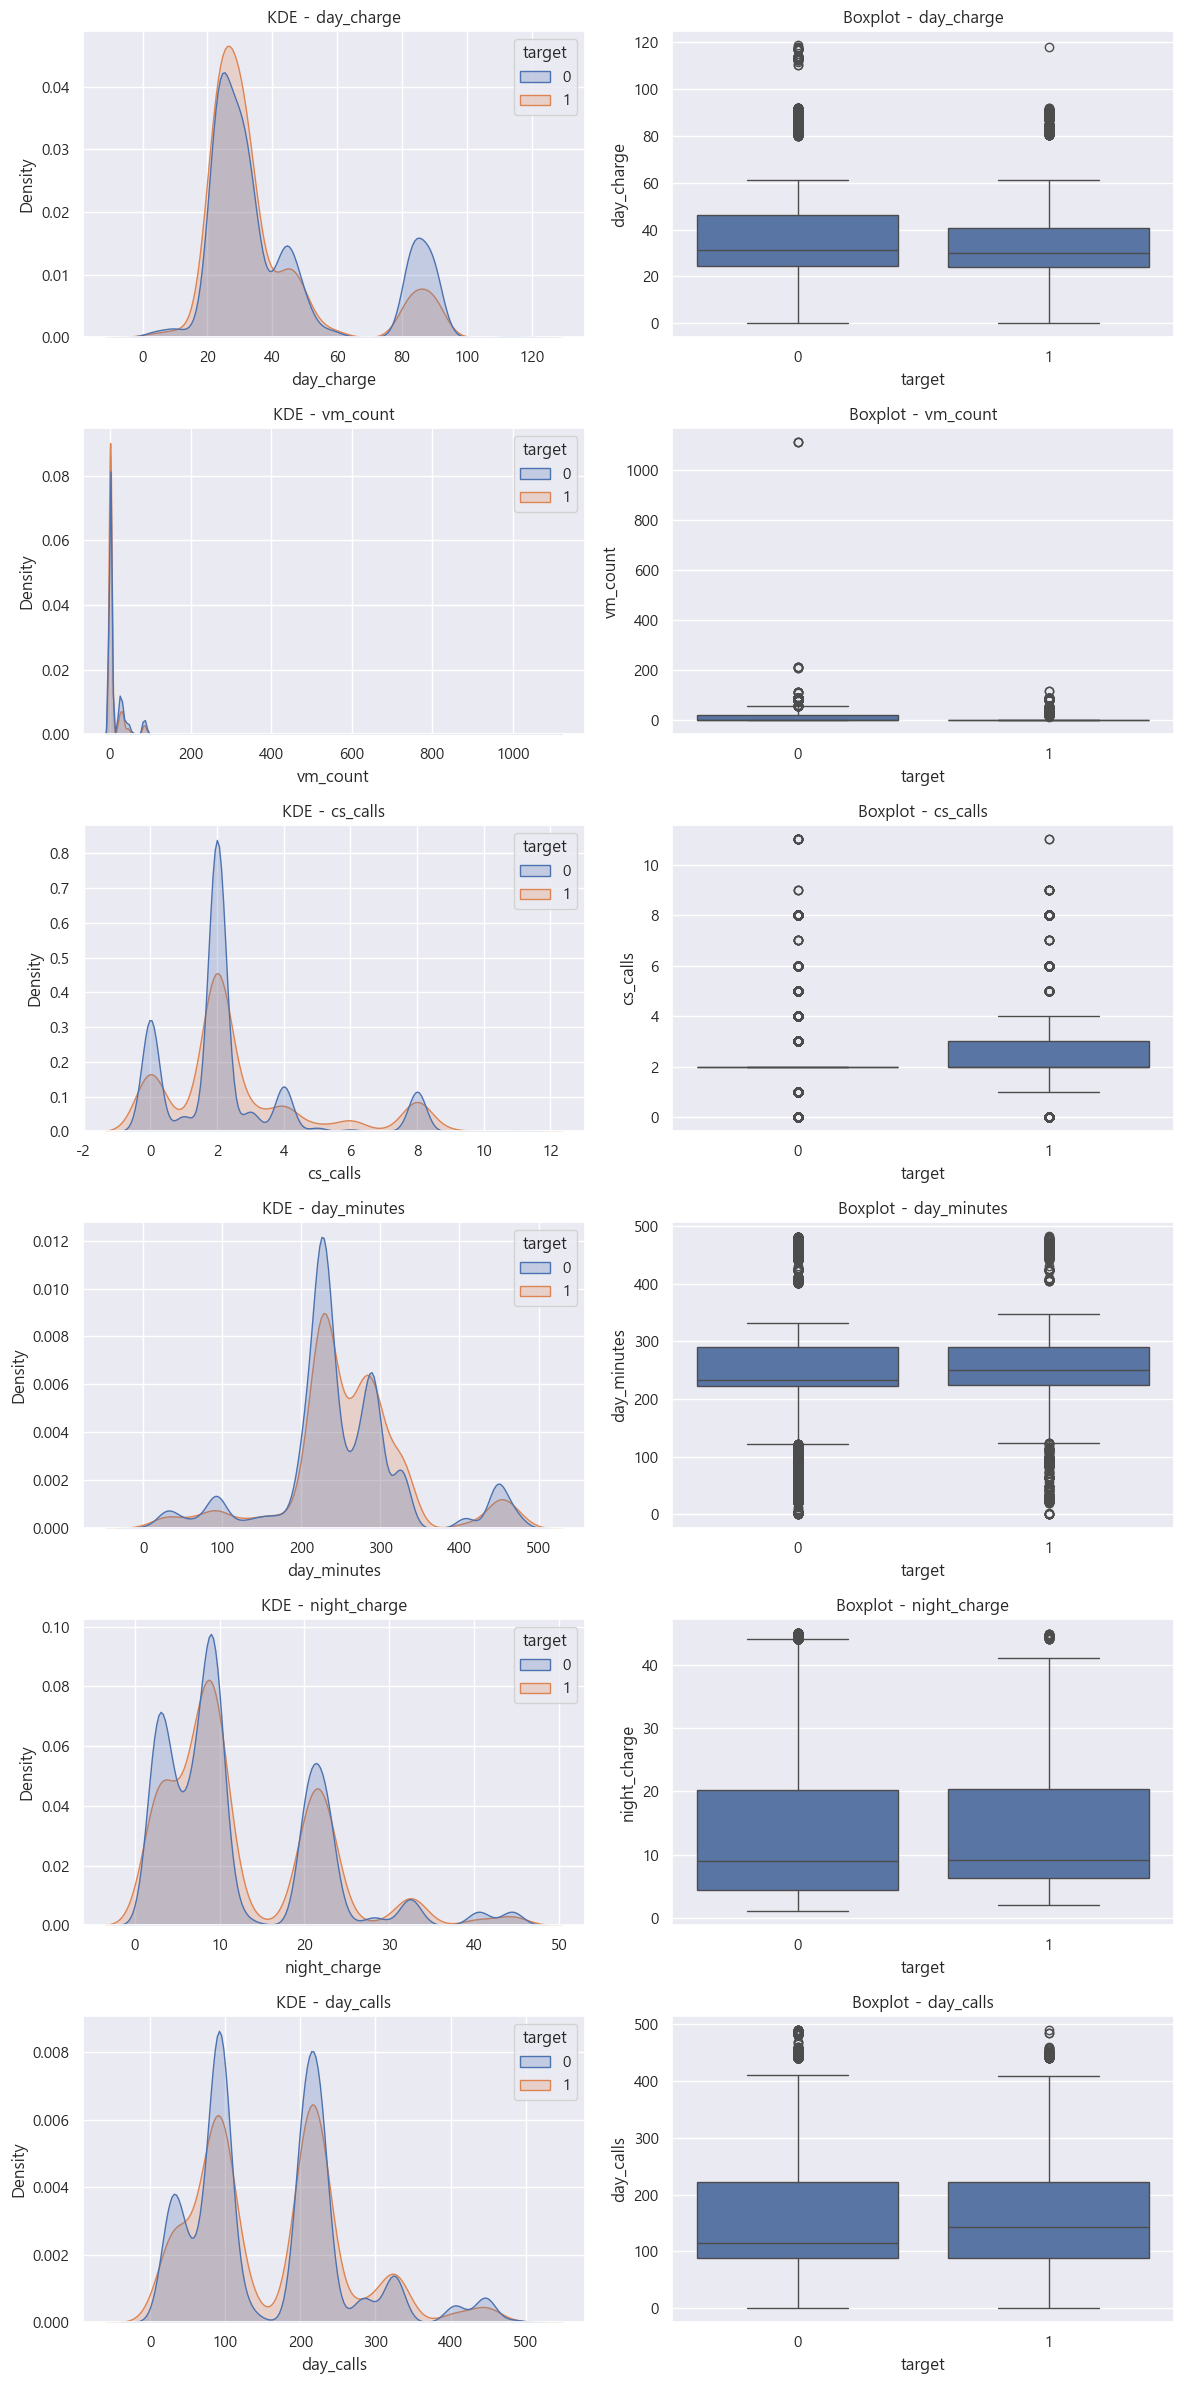


🚀 최종 핵심 변수 후보
{'tenure', 'vm_count', 'night_charge', 'cs_calls', 'day_charge', 'day_minutes'}


In [25]:
TARGET = "target"

# ==========================
# 1️⃣ 수치형 컬럼 추출
# ==========================

numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

if TARGET not in numeric_cols:
    raise ValueError(f"{TARGET} 컬럼이 수치형에 포함되지 않았습니다. 컬럼명 확인 필요.")

numeric_cols.remove(TARGET)

# ==========================
# 2️⃣ 효과 크기 계산 (Cohen's d)
# ==========================

def cohens_d(a, b):
    a = a.dropna()
    b = b.dropna()
    if len(a) < 2 or len(b) < 2:
        return np.nan
    s = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    if s == 0:
        return 0.0
    return (b.mean() - a.mean()) / s

rows = []

for col in numeric_cols:
    g0 = df.loc[df[TARGET]==0, col]
    g1 = df.loc[df[TARGET]==1, col]
    
    diff = g1.mean() - g0.mean()
    d = cohens_d(g0, g1)
    
    rows.append({
        "feature": col,
        "mean_diff(1-0)": diff,
        "cohens_d": d,
        "abs_effect": abs(d) if pd.notnull(d) else np.nan
    })

effect_df = pd.DataFrame(rows).sort_values("abs_effect", ascending=False)

print("\n🔹 효과 크기 Top 10")
display(effect_df.head(10))

# ==========================
# 3️⃣ Spearman 상관 분석
# ==========================

corr_df = df[numeric_cols + [TARGET]].corr(method='spearman')

corr_series = corr_df[TARGET].drop(TARGET)

corr_result = pd.DataFrame({
    "feature": corr_series.index,
    "spearman_corr": corr_series.values,
    "abs_corr": abs(corr_series.values)
}).sort_values("abs_corr", ascending=False)

print("\n🔹 Spearman 상관 Top 10")
display(corr_result.head(10))

# ==========================
# 4️⃣ 분위수별 해지율 + 단조 패턴
# ==========================

pattern_list = []

for col in numeric_cols:
    try:
        temp_bin = pd.qcut(df[col], 4, duplicates='drop')
        churn_rate = df.groupby(temp_bin)[TARGET].mean().values
        
        monotonic_inc = all(x <= y for x, y in zip(churn_rate, churn_rate[1:]))
        monotonic_dec = all(x >= y for x, y in zip(churn_rate, churn_rate[1:]))
        monotonic = monotonic_inc or monotonic_dec
        
        pattern_list.append({
            "feature": col,
            "churn_by_quartile": churn_rate,
            "monotonic_pattern": monotonic
        })
    except:
        continue

pattern_df = pd.DataFrame(pattern_list)

print("\n🔹 단조 증가/감소 패턴 변수")
display(pattern_df[pattern_df["monotonic_pattern"]==True])

# ==========================
# 5️⃣ 시각화 (효과 크기 상위 6개)
# ==========================

top6 = effect_df.head(6)["feature"].tolist()

fig, axes = plt.subplots(
    nrows=len(top6), 
    ncols=2, 
    figsize=(12, 4*len(top6))
)

if len(top6) == 1:
    axes = np.array([axes])

for i, col in enumerate(top6):
    
    _ = sns.kdeplot(
        data=df, x=col, hue=TARGET,
        fill=True, common_norm=False,
        ax=axes[i, 0]
    )
    _ = axes[i, 0].set_title(f"KDE - {col}")
    
    _ = sns.boxplot(
        data=df, x=TARGET, y=col,
        ax=axes[i, 1]
    )
    _ = axes[i, 1].set_title(f"Boxplot - {col}")

plt.tight_layout()
plt.show()

# ==========================
# 6️⃣ 최종 핵심 변수 후보
# ==========================

final_candidates = set(effect_df.head(5)["feature"]) \
                  | set(corr_result.head(5)["feature"]) \
                  | set(pattern_df[pattern_df["monotonic_pattern"]==True]["feature"])

print("\n🚀 최종 핵심 변수 후보")
print(final_candidates)

* 1) 효과 크기 : 의미있는 피처는 day_charge	(0.243), vm_count (0.224), cs_calls	(0.174)
* 2) Spearman 상관 : 단일 변수와 타겟 사이에 단조 관계(방향성)는 거의 없다.
* 3) 단조 증가/감소 패턴 : 
        - tenure : 증가 폭은 크지 않지만 완전히 단조 증가 → 가입 기간이 길수록 이탈 확률이 증가 => 장기 고객의 피로도, 요금제 불만 누적, 경쟁사 이동 (가설 2 반대 : 전략 수정)
        - cs_calls : 데이터 분포가 치우쳐서 2분할만 나옴 → 낮은 상담 그룹: 9.99%, 높은 상담 그룹: 14.56% => 상담 많이 하는 고객은 확실히 위험군 (가설 1 지지)

In [26]:
# 타겟과의 Pearson 상관
pearson_target = df.corr(method="pearson")["target"].drop("target").sort_values(ascending=False)

# 타겟과의 Spearman 상관
spearman_target = df.corr(method="spearman")["target"].drop("target").sort_values(ascending=False)

display(pd.DataFrame({
    "Pearson": pearson_target,
    "Spearman": spearman_target
}))

,Pearson,Spearman
cs_calls,0.057114,0.052821
day_calls,0.010974,0.017014
day_charge,-0.071006,-0.062199
day_minutes,0.029975,0.056487
eve_calls,-0.004276,-0.003798
eve_charge,0.001711,0.006038
eve_minutes,-0.000163,0.003237
night_calls,-0.003121,-0.001547
night_charge,0.014513,0.025799
night_minutes,-0.002872,0.002474


* 타겟 변수와 개별 피처 간 상관계수는 전반적으로 매우 낮게 나타나(|0.1|이하), 고객 이탈이 단일 요인에 의해 설명되지 않음을 확인.
    - 이는 이탈이 다양한 행동 패턴의 복합적 상호작용에 의해 발생함을 시사.
    - 즉, Churn은 단일 변수 문제가 아니라 행동 패턴의 조합 문제다!

### <b>2-1-5. 타겟 중심 EDA (범주형)

['cs_calls', 'target']


,feature,top_categories,top_churn_rate
0,cs_calls,"[9, 6, 7, 5, 3]","[0.8333333333333334, 0.5517241379310345, 0.538..."


<Axes: xlabel='cs_calls', ylabel='target'>

Text(0.5, 1.0, 'Top categories churn rate: cs_calls')

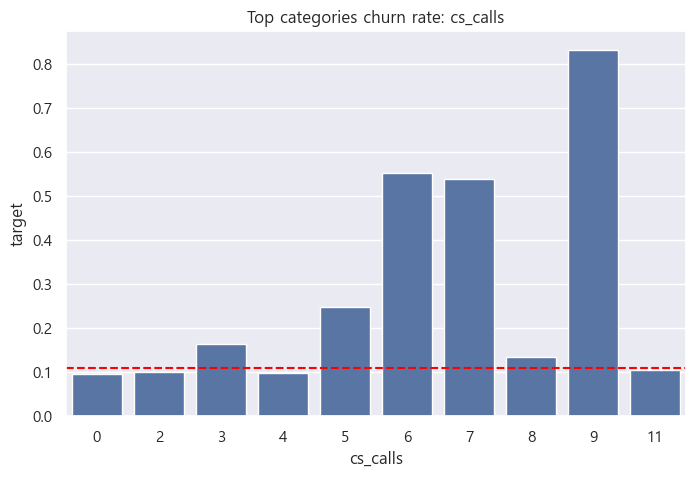

In [27]:
# VS Code에서 matplotlib 자동 객체 출력 방지
plt.ioff()  # 자동 인터랙티브 모드 끄기

cat_cols = [col for col in df.columns if df[col].nunique() < 20]  # nunique() < 20 : 수치형이어도 범주형처럼 해석
print(cat_cols)

# target과 ID는 제외
cat_cols = [c for c in cat_cols if c not in ["target", "ID"]]

cat_results = []  # 상위 이탈률 저장용 리스트

for c in cat_cols:
    # 카테고리별 타겟=1 비율 계산 (조건부 확률 P(churn=1 | category))
    rate = df.groupby(c)["target"].mean().sort_values(ascending=False)
    
    # 상위 5개 위험 집단만 저장
    cat_results.append((c, rate.index[:5].tolist(), rate.values[:5].tolist()))

# 어떤 집단이 가장 위험한가 테이블 출력
display(pd.DataFrame(cat_results, 
                     columns=["feature", "top_categories", "top_churn_rate"]
                    ).head(20))

# 특정 범주형 하나 선택해서 시각화
if len(cat_cols) > 0:
    
    c = cat_cols[0]
    
    # 상위 10개 카테고리 이탈률 계산
    churn_rate = (
        df.groupby(c)["target"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )
    
    # figure 객체 생성
    fig, ax = plt.subplots(figsize=(8,5))
    
    # barplot 생성
    sns.barplot(data=churn_rate, x=c, y="target", ax=ax)
    
    # 전체 평균 이탈률 계산
    avg_churn = df["target"].mean()
    
    # 평균선 추가
    ax.axhline(avg_churn, color='red', linestyle='--')
    
    # 제목 설정
    ax.set_title(f"Top categories churn rate: {c}")
    
    # 화면에 그래프 출력
    plt.show()
    
    # 핵심: figure 닫아서 <Figure ...> 출력 완전 차단
    plt.close(fig)

### <b>2-1-6. 가설 2 검증
* 가입일이 짧은 고객일수록 해지 확률이 높을 것이다. (초기 이탈 가설)


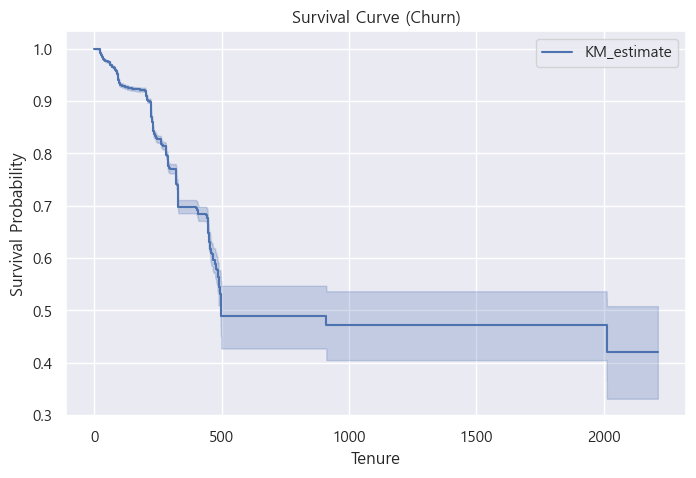

In [28]:
# -----------------------------
# 생존 분석 - Kaplan-Meier 곡선
# -----------------------------

from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

T = df["tenure"]           # 생존 시간
E = df["target"]           # 사건 발생 여부 (1=이탈)

kmf.fit(T, event_observed=E)

plt.figure(figsize=(8,5))
kmf.plot_survival_function()
plt.title("Survival Curve (Churn)")
plt.xlabel("Tenure")
plt.ylabel("Survival Probability")
plt.show();

* 초반 구간 (0~400 근처) : 곡선이 급격히 하락 → 초기 구간에서 이탈 발생 빈도가 높음
* 중반 이후 : 완만해짐 → 시간이 지날수록 이탈 속도 둔화<br><br>
* 해석 : 초기 이탈 위험이 더 높다는 정성적 증거 존재 → 하지만 이건 시각적 해석. 통계적 검정이 필요함!

In [29]:
from scipy.stats import ttest_ind

# -----------------------------
# Welch's t-test 통계적 검정
# -----------------------------

g0 = df[df["target"]==0]["tenure"]
g1 = df[df["target"]==1]["tenure"]

stat, p = ttest_ind(g0, g1, equal_var=False)     # 등분산 가정 안할 때 (Welch's t-test), 비이탈자(g0)와 이탈자(g1)의 tenure 평균이 같은지 검정
print("p-value:", p)

p-value: 0.23292961283528565


* 가입기간과 이탈 간 평균 차이에 대한 통계 검정 결과(p=0.23), 통계적으로 유의하지 않음. 가설 2 기각.
* 따라서 가입기간 단독 변수는 이탈을 설명하는 주요 요인으로 보기 어렵다.

In [30]:
from scipy.stats import chi2_contingency

# -----------------------------------------
# tenure 구간화
# -----------------------------------------
df["tenure_bin"] = pd.cut(
    df["tenure"],
    bins=[0, 6, 12, 24, df["tenure"].max()],
    right=False
)

pd.crosstab(df["tenure_bin"], df["target"], normalize="index")

# -----------------------------------------
# 카이제곱 검정
# -----------------------------------------
table = pd.crosstab(df["tenure_bin"], df["target"])
chi2, p, _, _ = chi2_contingency(table)

print("p-value:", p)

target,0,1
tenure_bin,,
"[0, 6)",0.884892,0.115108
"[6, 12)",1.000000,0.000000
"[12, 24)",0.887273,0.112727
"[24, 2212)",0.890011,0.109989


p-value: 0.019156996905750266


* 카이제곱 → 구간별 차이 존재 (p=0.019) : 초기 구간 위험 패턴이 존재할 가능성 높음!

In [31]:
# -----------------------------------------
# 초기 구간 vs 나머지 구간의 Risk Ratio 계산
# -----------------------------------------

early_rate = df[df["tenure"] < 6]["target"].mean()

late_rate  = df[df["tenure"] >= 6]["target"].mean()

print("Early:", early_rate)
print("Late:", late_rate)
print("Risk Ratio:", early_rate / late_rate)

Early: 0.11510791366906475
Late: 0.10984331858554273
Risk Ratio: 1.0479282231392355


* Risk Ratio (약 1.05) : 초기 이탈은 통계적으로 존재하지만 강한 초기 이탈 구조라고 보기는 어렵다.

| Risk Ratio  | 해석       |
| ----------- | -------- |
| 1.00 ~ 1.05 | 거의 차이 없음 |
| 1.05 ~ 1.20 | 약한 차이    |
| 1.20 이상     | 의미 있는 차이 |
| 1.50 이상     | 강한 효과    |


## <b>2-2. 피처 기본 분포 확인
* 정성적 단계 : 시각화로 어떻게 생겼나 패턴 확인 단계
* 목적 : 
    - 변수의 분포 형태 확인 (정규/비대칭/이산형)
    - 극단값 존재 여부 감지
    - 로그 변환 필요성 1차 판단
    - 변수 스케일 감각 확보

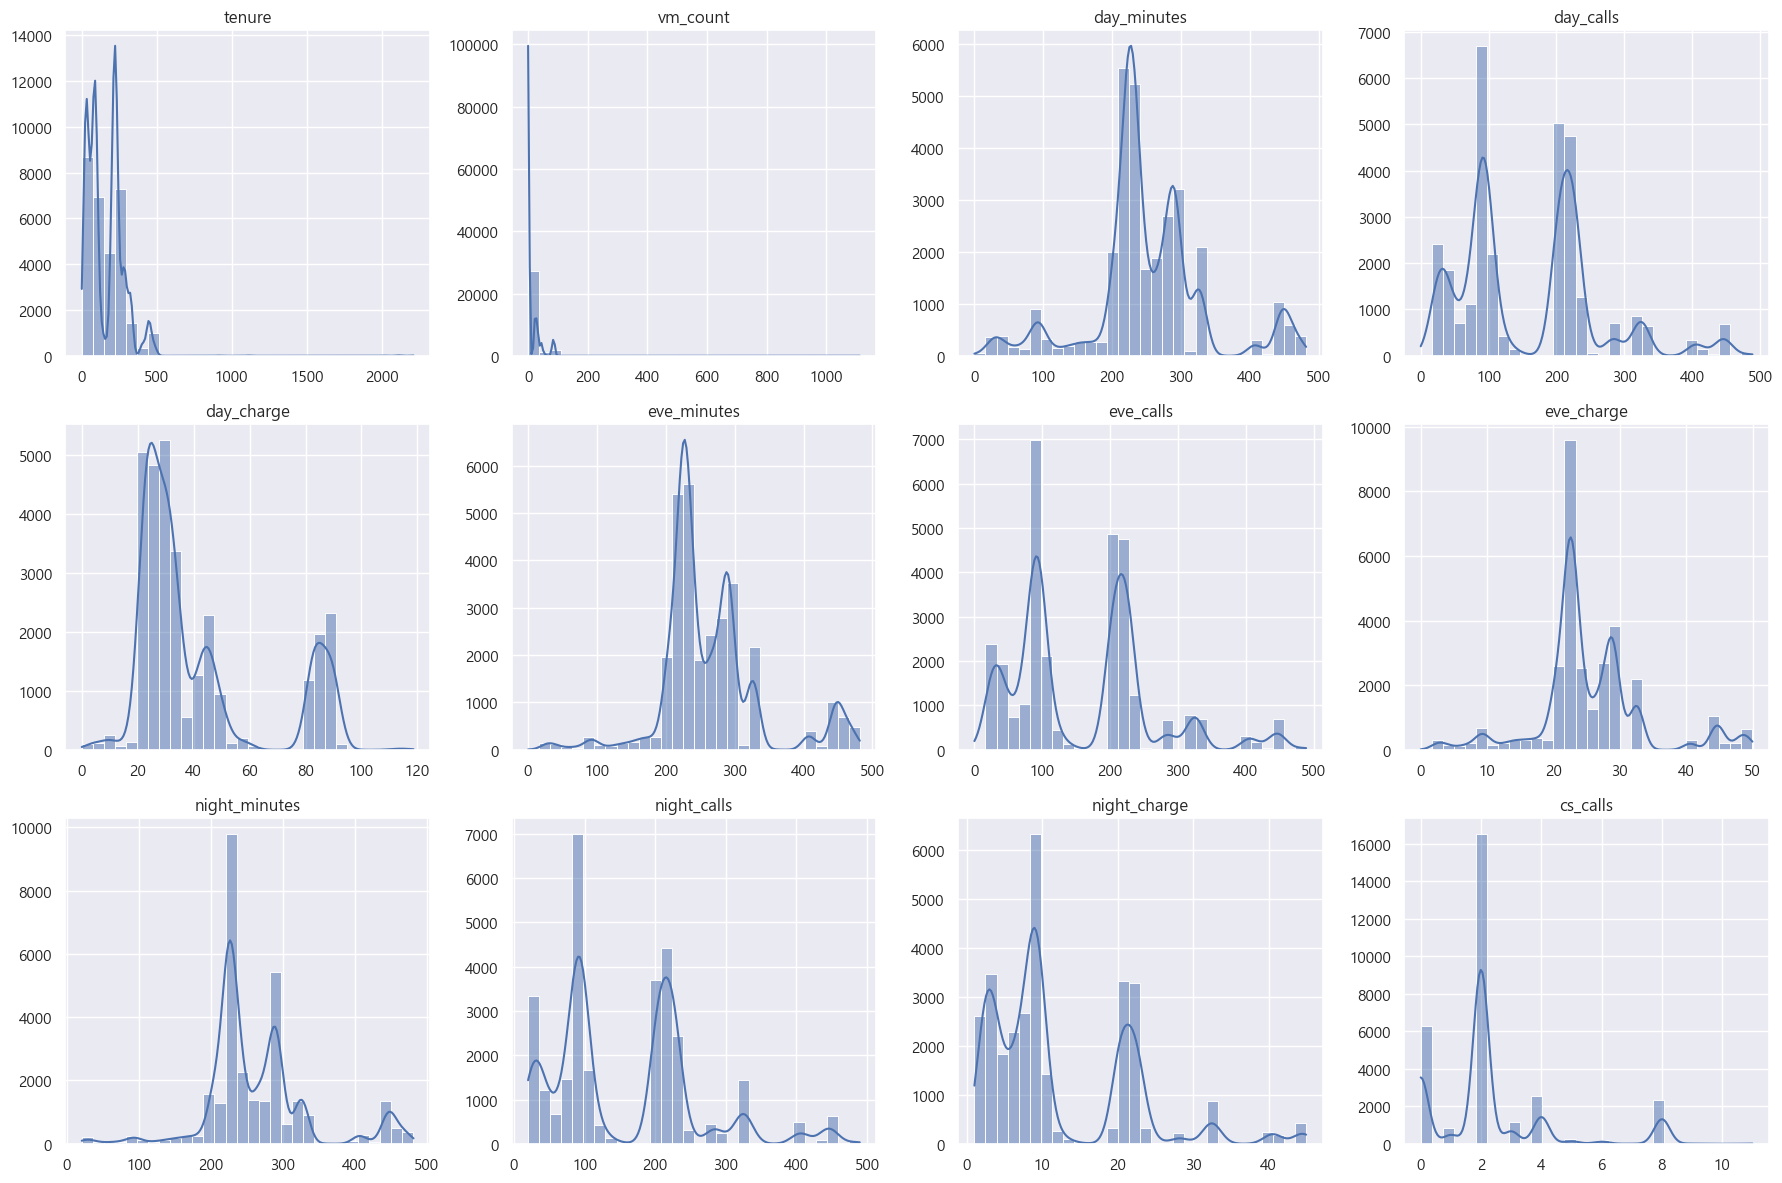

In [32]:
# 수치형 변수만 선택 (타겟 제외)
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols = numeric_cols.drop("target", errors="ignore")

# 전체 subplot 구성
n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    
    # 결측 제거
    data = df[col].dropna()
    
    # 히스토그램 + KDE
    sns.histplot(data, bins=30, kde=True, ax=axes[i])
    
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# 남는 subplot 제거
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show();

## <b>2-3. 왜도/첨도 분석
* 왜도 (Skewness) : 분포의 비대칭성, 0에 가까울수록 대칭, |Skew| > 1 → 강한 왜도
* 첨도 (Kurtosis) : 값이 클수록 극단값 많음

### <b>2-3-1. 왜도/첨도 정량적 측정
* 정량적 단계 : 통계량 측정으로 얼마나 차이나는지 수치로 검증

In [33]:
# -------------------------------
# 왜도/첨도 정량 계산
# -------------------------------

skew_kurt = []

for col in numeric_cols:
    x = df[col].dropna()
    skew_kurt.append((col, x.skew(), x.kurt()))

skew_kurt_df = pd.DataFrame(
    skew_kurt, columns=["feature","skew","kurtosis"]
)

# -------------------------------
# 절대 왜도 기준 정렬
# -------------------------------

skew_kurt_df = skew_kurt_df.sort_values(
    by="skew",
    key=lambda x: np.abs(x),
    ascending=False
)

skew_kurt_df = skew_kurt_df.reset_index(drop=True)
display(skew_kurt_df)

,feature,skew,kurtosis
0,vm_count,10.159494,378.258369
1,tenure,3.106704,39.885231
2,cs_calls,1.554562,2.402749
3,night_charge,1.276195,1.330879
4,day_charge,1.193922,0.024647
5,night_calls,0.808396,0.315923
6,eve_calls,0.801134,0.286689
7,night_minutes,0.782545,2.088991
8,eve_minutes,0.768130,2.088177
9,day_calls,0.766039,0.245274


* 1) vm_count — 심각한 왜곡 변수 : 거의 대부분 값 = 0, 극소수만 매우 큼 → 그대로 쓰면 모델 왜곡 가능 → np.log1p 변환 권장
* 2) tenure — 강한 오른쪽 치우침 : 신규 고객 많음, 장기 고객 소수 → np.log1p 변환 추천
* 3) cs_calls — 의미 있는 비대칭 : 일부 고객 상담 폭증 → np.log1p 변환 선택적 (트리모델이면 굳이 필요 없음)
* 4) charge / minutes / calls 계열 : 정상적인 사용량 분포 → 그대로 사용 → 스케일링만
* 5) day_minutes : 거의 정규 분포

### <b>2-3-2. 타겟별 왜도 비교

In [34]:
# -------------------------------
# 타겟별 왜도 비교 (전체 수치형 변수 대상)
# -------------------------------

# 수치형 변수 전체 선택
numeric_cols = df.select_dtypes(include=np.number).columns

# 타겟은 제외 (왜도 비교 대상이 아님)
numeric_cols = numeric_cols.drop("target", errors="ignore")

target_skew_list = []

for col in numeric_cols:
    
    # 비이탈자 왜도
    skew_0 = df[df["target"] == 0][col].dropna().skew()
    
    # 이탈자 왜도
    skew_1 = df[df["target"] == 1][col].dropna().skew()
    
    # 왜도 차이 절대값
    skew_diff = abs(skew_0 - skew_1)
    
    target_skew_list.append((
        col,
        skew_0,
        skew_1,
        skew_diff
    ))

# 데이터프레임 생성
target_skew_df = pd.DataFrame(
    target_skew_list,
    columns=[
        "feature",
        "skew_non_churn",
        "skew_churn",
        "skew_diff"
    ]
)

# 왜도 차이 기준 정렬
target_skew_df = target_skew_df.sort_values(
    by="skew_diff",
    ascending=False
)

target_skew_df = target_skew_df.reset_index(drop=True)
display(target_skew_df)

,feature,skew_non_churn,skew_churn,skew_diff
0,vm_count,10.405652,3.059077,7.346575
1,day_charge,1.137224,1.749494,0.612269
2,tenure,3.153439,2.690501,0.462938
3,cs_calls,1.595988,1.250527,0.345460
4,day_minutes,0.199600,0.002470,0.197130
5,night_minutes,0.765023,0.956968,0.191945
6,day_calls,0.780820,0.644717,0.136103
7,eve_minutes,0.755955,0.887982,0.132028
8,night_charge,1.287742,1.185739,0.102003
9,night_calls,0.817242,0.735586,0.081655


* skew_diff 거의 0 일 경우 : 타겟 구조 차이 거의 없음, 단일 변수 영향 낮음 가능성
* skew_diff 값이 클 경우 : 타겟별 분포 구조 차이 존재, Tree 계열 모델에서 중요 변수 될 확률 높음<br><br>
* ① vm_count → 압도적 구조 차이 : 비이탈자는 거의 0 몰림 + 극단값 존재 → 반드시 변환 또는 재구성 필요
    - 로그 변환, 0 여부 더미 생성(이진), 구간화(범주)
* ② day_charge → 중간 수준 구조 차이 : | skew_diff | 0.61 | → 이탈자가 더 우측 꼬리, 고요금 고객이 이탈에 더 비대칭적
* ③ tenure : | skew_diff | 0.46 | → 구조 차이는 있지만 강하지 않음, 로그 변환 고려 대상
* ④ 나머지 변수들 : skew_diff < 0.2 → 타겟 구조 차이 거의 없음, 변환 필요성 낮음

## <b>2-4. 이상치 분석 (IQR, Boxplot)

In [35]:
# -------------------------------
# 2-1-9 이상치 정량 분석 (확장 버전)
# -------------------------------

numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols = numeric_cols.drop("target", errors="ignore")

out_tbl = []

for c in numeric_cols:
    
    x = df[c].dropna()
    
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    
    if iqr == 0:
        out_rate = 0.0
        extreme_rate = 0.0
        lo, hi = None, None
        
    else:
        # 일반 이상치
        lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
        out_mask = (x < lo) | (x > hi)
        out_rate = out_mask.mean()
        
        # 극단 이상치 (3*IQR)
        lo_ext, hi_ext = q1 - 3*iqr, q3 + 3*iqr
        extreme_mask = (x < lo_ext) | (x > hi_ext)
        extreme_rate = extreme_mask.mean()
    
    # 타겟별 이상치 비율
    out_rate_0 = None
    out_rate_1 = None
    
    if iqr != 0:
        x0 = df[df["target"] == 0][c].dropna()
        x1 = df[df["target"] == 1][c].dropna()
        
        out_rate_0 = ((x0 < lo) | (x0 > hi)).mean()
        out_rate_1 = ((x1 < lo) | (x1 > hi)).mean()
    
    out_tbl.append((
        c,
        out_rate,
        extreme_rate,
        out_rate_0,
        out_rate_1,
        abs((out_rate_0 or 0) - (out_rate_1 or 0))
    ))

out_df = pd.DataFrame(
    out_tbl,
    columns=[
        "feature",
        "outlier_rate(1.5IQR)",
        "extreme_rate(3IQR)",
        "outlier_rate_non_churn",
        "outlier_rate_churn",
        "outlier_rate_diff"
    ]
).sort_values("outlier_rate(1.5IQR)", ascending=False)

out_df = out_df.reset_index(drop=True)
display(out_df)

,feature,outlier_rate(1.5IQR),extreme_rate(3IQR),outlier_rate_non_churn,outlier_rate_churn,outlier_rate_diff
0,day_charge,0.186126,0.001424,0.195484,0.110307,0.085177
1,day_minutes,0.158146,0.003179,0.161260,0.132911,0.028349
2,eve_charge,0.134934,0.018344,0.138680,0.104581,0.034099
3,eve_minutes,0.113808,0.001457,0.117142,0.086799,0.030342
4,night_minutes,0.113079,0.000927,0.117142,0.080169,0.036973
5,vm_count,0.059371,0.012781,0.062198,0.036468,0.025730
6,eve_calls,0.027417,0.000000,0.027900,0.023508,0.004392
7,night_calls,0.026589,0.000000,0.027230,0.021398,0.005832
8,day_calls,0.026490,0.000000,0.027044,0.022001,0.005043
9,night_charge,0.014106,0.000000,0.014247,0.012960,0.001288


<pre>
* 이상치 해석
  : 통화 시간 및 요금 변수에서 상대적으로 높은 이상치의 비율이 보였으나, 데이터 오류가 아닌 과다 사용 고객임
    트리 기반 모델에서는 이상치의 영향이 제한적이라 단순 제거보다는 로그변환이나 구간화 전략이 적절<br>
  이상치 비율 해석
  : 통화시간과 요금변수에서 이상치 비율 높음, 특히 주간사용량에서 제일 높음, 요금과 사용시간은 선형이라 동일패턴이 반복됨
    데이터 왜곡이라기보다는 비대칭 분포의 특성 = 제거대상은 아님

* 이상치 = 이탈신호(recall)의 핵심으로 단순 에러가 아닌 이탈징후(ex.상담을 비정상적으로 많이함)
    → 이상치 삭제보다는 파생피쳐를 만들어 강조하는 것이 좋음<br>
* 변수마다 데이터의 범위가 제각각임 = 트리모델에는 지장없으나 Macro-F1의 안정성을 위해 전처리 파이프라인에서 스케일링이 필수적
    → 이상치 영향을 적게 받는 RobustScaler 추천<br>
* 만약 cs_calls 관련 이상치 비율이 높다면 상담전화 관련 새로만든 피쳐가 모델에서 중요한 역할을 하는지 방증하는 지표가 됨

| 컬럼                     | 의미           |
| ---------------------- | ------------ |
| outlier_rate(1.5IQR)   | 전체 이상치 비율    |
| extreme_rate(3IQR)     | 극단 이상치 비율    |
| outlier_rate_non_churn | 정상 고객 이상치 비율 |
| outlier_rate_churn     | 이탈 고객 이상치 비율 |
| outlier_rate_diff      | 두 그룹 차이 ⭐ 핵심 |


* 1) day_charge — 가장 강한 신호 : 정상 고객 이상치: 19.5%, 이탈 고객 이상치: 11.0% → 사용량이 매우 높은 고객은 떠나지 않는다.
* 2) day_minutes / eve_charge / night_minutes : diff ≈ 0.03~0.04 → 사용량 극단값이 churn과 약한 관계
    - 정상 고객 쪽 이상치 더 많음 → 많이 쓰는 고객은 안정적이다.
* 3) vm_count : diff = 0.025 → voicemail 사용량 극단값 차이 존재, 하지만 영향은 중간 수준.
* 4) calls 계열 (day/eve/night_calls) : diff ≈ 0.004~0.006 → 이상치 의미 거의 없음.
* 5) tenure : diff = 0.0015 → 이상치 관점에서는 영향 없음.
* 6) cs_calls : outlier_rate = 0 → 값 범위 좁음
* 결론 : 
    - 사용량이 높은 고객 = 이탈하지 않음
    - 고객은 많이 써서 떠나는 것이 아니라, 서비스 사용이 줄어들 때 떠난다.
    - 이상치 제거하면 안되는 피쳐 : day_minutes, day_charge, eve_minutes
    - 이 데이터에서 이상치는 노이즈가 아니라 ‘충성 고객 신호’다.

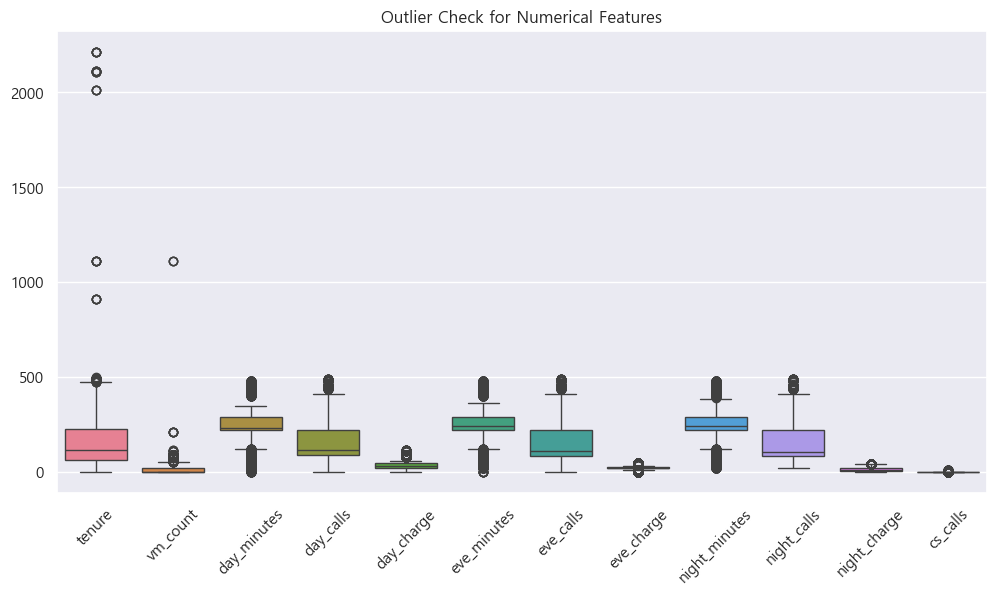

In [36]:
# 이상치 Boxplot 시각화
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(columns=[ 'target']))
plt.xticks(rotation=45)
plt.title('Outlier Check for Numerical Features')
plt.show();

## <b>2-5. 피처 간 관계 분석 (상관/공선성)
* Pearson : 선형 관계, 정규성 가정
* Spearman : 순위 기반, 비선형 단조 관계 탐지, 이상치에 민감하지 않음(안정적)

| 기준       | 해석     |       |       |
| -------- | ------ | ----- | ----- |
|          | r      | > 0.8 | 강한 상관 |
|          | r      | > 0.9 | 제거 후보 |
| VIF > 5  | 공선성 의심 |       |       |
| VIF > 10 | 심각     |       |       |



### <b>2-5-1. Pearson + Spearman Heatmap

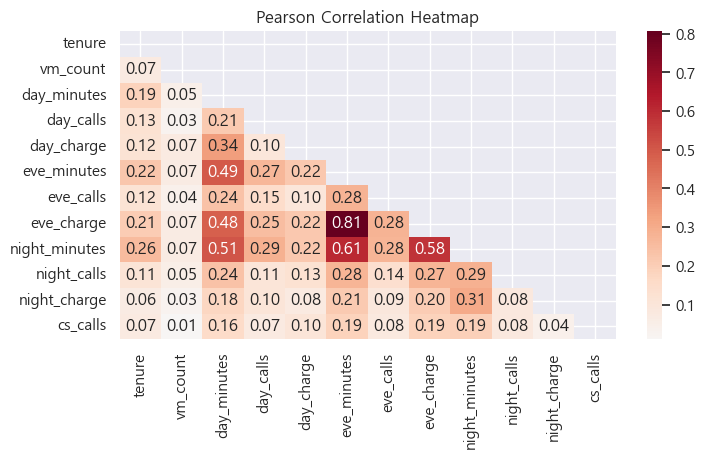

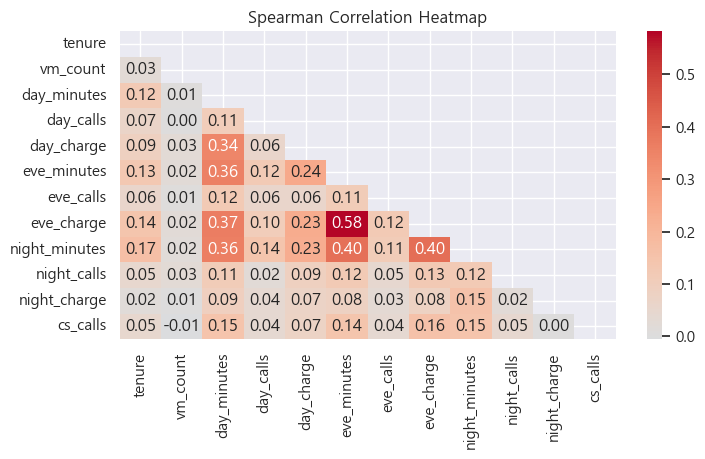

In [37]:
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols = numeric_cols.drop("target", errors="ignore")

# -------------------------------
# Pearson 상관
# -------------------------------
pearson_corr = df[numeric_cols].corr(method="pearson")

plt.figure(figsize=(8, 4))
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))
sns.heatmap(pearson_corr, mask=mask, cmap='RdBu_r', center=0, annot=True, fmt=".2f")    # ✅ 수치 표시
plt.title("Pearson Correlation Heatmap")
plt.show()


# -------------------------------
# Spearman 상관
# -------------------------------
spearman_corr = df[numeric_cols].corr(method="spearman")

plt.figure(figsize=(8, 4))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))
sns.heatmap(spearman_corr, mask=mask, cmap='coolwarm', center=0, annot=True, fmt=".2f")    # ✅ 수치 표시
plt.title("Spearman Correlation Heatmap")
plt.show();

| 구분        | 히트맵(r)  | VIF      |
| --------- | ------- | -------- |
| 관점        | 두 변수 관계 | 전체 변수 구조 |
| 목적        | 의심 단계   | 확정 단계    |
| 정확성       | 보조 도구   | 최종 판단    |
| 모델 안정성 반영 | ❌       | ✅        |


* 1) 가장 강한 상관 구조 (핵심) : minutes ↔ charge (r = 0.806827, 거의 완전 상관)
    - 통화 시간(minutes) ↔ 요금(charge)은 거의 동일 정보이며 강한 다중공선성이 존재한다.
    - minutes 유지 ⭐ (추천) ↔ charge 를 rate(단가) 파생변수로 변경
    - day_rate = day_charge / day_minutes
    - eve_rate = eve_charge / eve_minutes
    - night_rate = night_charge / night_minutes
* 2) calls 변수들 : 상관 거의 없음. 독립변수 (유지)
* 3) cs_calls (상담전화) : 다른 변수들과 상관 거의 없음. 독립변수 (유지)
* 4) tenure (가입기간) : 약한 상관만 존재. 독립변수 (유지)

| 변수군        | 처리    |
| ---------- | ----- |
| charge 계열  | 제거 권장 |
| minutes 계열 | 유지 ⭐  |
| calls 계열   | 유지    |
| cs_calls   | 유지    |
| tenure     | 유지    |

* 통화 시간과 요금 변수 간 매우 높은 상관관계가 확인되어 정보 중복 가능성이 존재함.
* 모델 안정성 확보를 위해 요금 변수 제거 또는 대표 변수 선택이 필요.
* 반면 상담전화 및 통화 횟수 변수는 사용량과 독립적인 행동 특성을 반영하는 것으로 나타남.

<font size=10><b><charge 를 rate(단가) 파생변수로 변경>

```python

df_B = df.copy()

# 0으로 나누기 방지
eps = 1e-9
df_B["day_rate"]   = df_B["day_charge"]   / (df_B["day_minutes"]   + eps)
df_B["eve_rate"]   = df_B["eve_charge"]   / (df_B["eve_minutes"]   + eps)
df_B["night_rate"] = df_B["night_charge"] / (df_B["night_minutes"] + eps)

charge_cols = [c for c in df_B.columns if "charge" in c]
df_B = df_B.drop(columns=charge_cols)

### <b>2-5-2. VIF (Variance Inflation Factor)
* 한 변수가 다른 변수들과 얼마나 겹치는 정보를 가지고 있는지를 수치로 나타낸 값

| 단어        | 의미            |
| --------- | ------------- |
| Variance  | 분산 (계수의 불안정성) |
| Inflation | 부풀어 오름        |
| Factor    | 정도            |
* 다른 변수들과 겹칠수록 회귀계수의 분산이 부풀어 오른다.

In [38]:
# 상수항 추가
X = add_constant(df[numeric_cols])

vif_data = []

for i in range(1, X.shape[1]):  # constant 제외
    vif = variance_inflation_factor(X.values, i)
    vif_data.append((numeric_cols[i-1], vif))

vif_df = pd.DataFrame(vif_data, columns=["feature","VIF"])\
            .sort_values("VIF", ascending=False)

display(vif_df)

,feature,VIF
5,eve_minutes,3.198529
7,eve_charge,3.042283
8,night_minutes,1.974918
2,day_minutes,1.589466
4,day_charge,1.143205
6,eve_calls,1.124395
9,night_calls,1.123980
3,day_calls,1.115723
10,night_charge,1.105808
0,tenure,1.091036


| VIF | 의미     |
| --- | ------ |
| 1   | 완전 독립  |
| 1~3 | 매우 안정  |
| 3~5 | 약한 공선성 |
| ≥5  | 문제 시작  |
| ≥10 | 심각     |

* 결론 : 모델 안정성 매우 양호 → 히트맵에서 보였던 상관관계가 존재하지만 모델을 망가뜨릴 정도는 아니다.
    - 다중공선성 처리 단계 → PASS 해도 됨!

## <b>2-6. 타겟-피쳐 상관 분석

,feature,pearson_r,pearson_p,spearman_r,spearman_p,abs_pearson
4,day_charge,-0.071006,4.603689e-35,-0.062199,2.797811e-27,0.071006
1,vm_count,-0.062734,1.006627e-27,-0.060345,9.008989e-26,0.062734
11,cs_calls,0.057114,2.990540e-23,0.052821,4.103685e-20,0.057114
2,day_minutes,0.029975,1.887405e-07,0.056487,8.893263e-23,0.029975
10,night_charge,0.014513,1.166524e-02,0.025799,7.326216e-06,0.014513
3,day_calls,0.010974,5.651523e-02,0.017014,3.108746e-03,0.010974
0,tenure,0.006688,2.451143e-01,0.013781,1.662811e-02,0.006688
6,eve_calls,-0.004276,4.574060e-01,-0.003798,5.092028e-01,0.004276
9,night_calls,-0.003121,5.875676e-01,-0.001547,7.880343e-01,0.003121
8,night_minutes,-0.002872,6.177053e-01,0.002474,6.672860e-01,0.002872


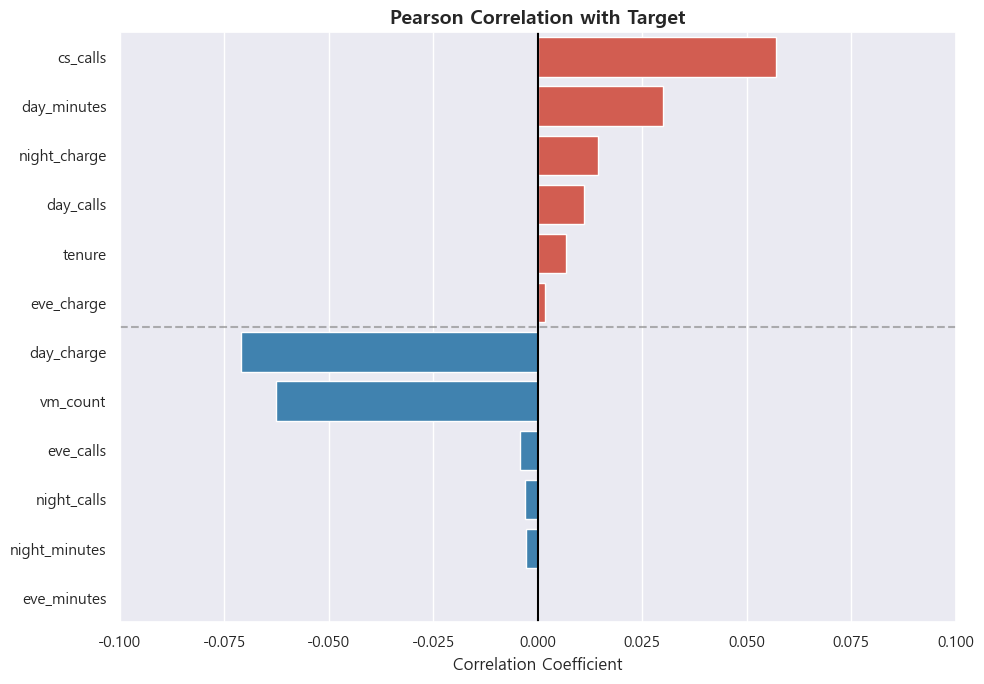

,feature,pearson_r,pearson_p,spearman_r,spearman_p,abs_pearson,sign
4,day_charge,-0.071006,4.603689e-35,-0.062199,2.797811e-27,0.071006,Negative
1,vm_count,-0.062734,1.006627e-27,-0.060345,9.008989e-26,0.062734,Negative
11,cs_calls,0.057114,2.990540e-23,0.052821,4.103685e-20,0.057114,Positive
2,day_minutes,0.029975,1.887405e-07,0.056487,8.893263e-23,0.029975,Positive
10,night_charge,0.014513,1.166524e-02,0.025799,7.326216e-06,0.014513,Positive


In [39]:
# ---------------------------------------
# Pearson / spearmanr 상관 분석 (p-value 포함)
# ---------------------------------------
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols = numeric_cols.drop("target", errors="ignore")

results = []

for col in numeric_cols:
    
    x = df[col].dropna()
    y = df.loc[x.index, "target"]
    
    # Pearson
    r_p, p_p = pearsonr(x, y)
    
    # Spearman
    r_s, p_s = spearmanr(x, y)
    
    results.append((
        col,
        r_p, p_p,
        r_s, p_s
    ))

corr_df = pd.DataFrame(
    results,
    columns=[
        "feature",
        "pearson_r", "pearson_p",
        "spearman_r", "spearman_p"
    ]
)

# 절대값 기준 정렬
corr_df["abs_pearson"] = corr_df["pearson_r"].abs()
corr_df = corr_df.sort_values("abs_pearson", ascending=False)
display(corr_df)


# ---------------------------------------
# Pearson Correlation Diverging Bar Chart
# ---------------------------------------
plt.figure(figsize=(10, 7))

# 1️⃣ 부호 + 절대값 생성
corr_df["sign"] = np.where(corr_df["pearson_r"] >= 0, "Positive", "Negative")
corr_df["abs_pearson"] = corr_df["pearson_r"].abs()

# 2️⃣ (+) 먼저, 내부는 크기순 정렬
corr_df_plot = (
    corr_df
    .sort_values(["sign", "abs_pearson"], ascending=[False, False])
    .reset_index(drop=True)
)

# 3️⃣ 색상 자동 생성
colors = np.where(
    corr_df_plot["pearson_r"] >= 0,
    "#E74C3C",   # red
    "#2E86C1"    # blue
)

# 4️⃣ Barplot
sns.barplot(
    data=corr_df_plot,
    x="pearson_r",
    y="feature",
    palette=colors
)

# 5️⃣ 기준선 (0)
plt.axvline(0, color="black", linewidth=1.5)

# 양/음 그룹 경계선
pos_count = (corr_df_plot["pearson_r"] >= 0).sum()
plt.axhline(pos_count - 0.5, color="gray", linestyle="--", alpha=0.6)

# 6️⃣ 스타일
plt.title("Pearson Correlation with Target", fontsize=14, weight="bold")
plt.xlabel("Correlation Coefficient")
plt.ylabel("")
plt.xlim(-0.1, 0.1)

plt.tight_layout()
plt.show()


# ---------------------------------------
# 유의한 변수만 추출 (p < 0.05)
# ---------------------------------------
significant = corr_df[corr_df["pearson_p"] < 0.05]
display(significant);

<pre>
* 빨간색 : 양의 상관관계(이탈 증가 요인)
  cs_calls (고객센터 연락 횟수) -> 핵심 이탈 예측 변수
  day_minutes : 사용시간 많을수록 이탈 증가 경향 -> 요금 부담 증가 가능성, 고사용 고객의 가격 민감도 존재 가능
  night_charge : 야간 요금 -> 요금관련요소가 영향 있음
  day_calls : 활동량 많은 고객은 오히려 이탈 가능성 높음

* 파란색 : 음의 상관관계(이탈 감소 요인)
  day_charge : 요금이 높을수록 이탈 감소 -> 프리미엄 고객, 높은 요금제 고객=충성도 높을수있음
  vm_count : 음성메일 사용고객은 이탈 가능성 낮음 -> 부가서비스 이용 고객은 유지가능성 높다

총평 = 고객센터 이용 횟수는 가장 강력한 이탈 신호
    요금 및 사용량 변수는 복합적 영향
    단순 선형 상관은 전반적으로 약함
    비선형 모델 기반 접근이 적절

## <b>2-7. 가설 3 검증
* 총 통화량이 낮은 고객은 해지 가능성이 높을 것이다.
 * 검증 방법 :
    - 1) 사용량과 타겟 간 음의 관계
    - 2) 분위수별 이탈률 차이
    - 3) Risk Ratio
    - 4) 상관 분석

usage_q
0    0.091968
1    0.108903
2    0.114748
3    0.123874
Name: target, dtype: float64


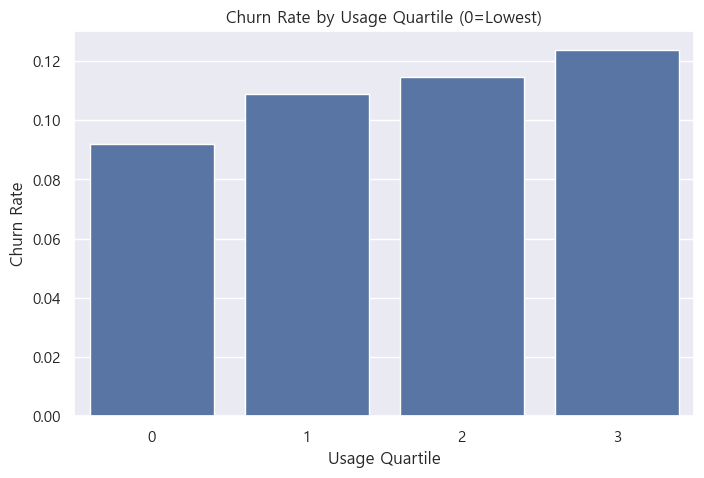

In [40]:
# -------------------------------
# 1) 총 통화량 생성
# -------------------------------

df["total_minutes"] = (
    df["day_minutes"] +
    df["eve_minutes"] +
    df["night_minutes"]
    )


# -------------------------------
# 2) 분위수 기반 구간화
# -------------------------------

# 4분위수로 구간화
df["usage_q"] = pd.qcut(df["total_minutes"], 4, labels=False)

# 구간별 이탈률 계산
churn_by_usage = df.groupby("usage_q")["target"].mean()

print(churn_by_usage)


# -------------------------------
# 3) 시각화
# -------------------------------

plt.figure(figsize=(8,5))
sns.barplot(x=churn_by_usage.index, y=churn_by_usage.values)
plt.title("Churn Rate by Usage Quartile (0=Lowest)")
plt.xlabel("Usage Quartile")
plt.ylabel("Churn Rate")
plt.show();

In [41]:
# --------------------------------------------------------
# 4) 카이제곱 검정 : 사용량 수준과 해지는 서로 관련이 있는가?
# --------------------------------------------------------

table = pd.crosstab(df["usage_q"], df["target"])
chi2, p, _, _ = chi2_contingency(table)

print("p-value:", p)


# --------------------------------------------------------
# 5) Risk Ratio 계산 (Low vs High)
# --------------------------------------------------------
low_rate = df[df["usage_q"] == 0]["target"].mean()
high_rate = df[df["usage_q"] == 3]["target"].mean()

print("Low usage churn:", low_rate)
print("High usage churn:", high_rate)
print("Risk Ratio (Low/High):", low_rate / high_rate)

p-value: 4.404357248566049e-09
Low usage churn: 0.0919677120550483
High usage churn: 0.12387387387387387
Risk Ratio (Low/High): 0.7424302573171172


* p-value = 4.40e-09 : usage_q와 churn은 통계적으로 강하게 연관됨

| p-value | 해석      |
| ------- | ------- |
| < 0.05  | 관계 있음 ✅ |
| ≥ 0.05  | 관계 없음   |

* Low usage churn  = 0.0919 (9.2%) / High usage churn = 0.1238 (12.4%)
    - (가설 3) 사용량 낮으면 해지 ↑ 인데, 실제론 "사용량 높을수록 해지율 ↑"
* Risk Ratio = 0.742 : Low usage 고객의 해지 위험은 High usage 고객의 약 74% 수준, 즉 고사용 고객이 더 위험하다!

### <b>2-7-1. 인사이트 도출
* 어떤 고객 조합이 실제 churn hotspot인가?
* 분석 목표 : 

| usage | tenure | 의미                     |
| ----- | ------ | ---------------------- |
| 높음    | 짧음     | 🔥 초기 기대 불만 고객 (위험 후보) |
| 낮음    | 김      | 휴면 고객                  |
| 높음    | 김      | 충성 고객                  |
| 낮음    | 짧음     | 자연 이탈                  |


In [42]:
# --------------------------------------------------------
# 1) tenure 구간화 : 가입기간 사분위 그룹 생성
# --------------------------------------------------------

df["tenure_q"] = pd.qcut(
    df["tenure"],
    q=4,
    labels=["T1(short)", "T2", "T3", "T4(long)"]
)


# --------------------------------------------------------
# 2) usage × tenure churn rate 테이블 생성
# --------------------------------------------------------

pivot = (
    df
    .groupby(["usage_q", "tenure_q"])["target"]
    .mean()
    .unstack()
)

pivot

tenure_q,T1(short),T2,T3,T4(long)
usage_q,,,,
0,0.090301,0.090549,0.100266,0.081581
1,0.093724,0.128440,0.112157,0.112136
2,0.120375,0.112110,0.115646,0.110800
3,0.117647,0.115721,0.132296,0.130689


| 사용량 구간              | T1 (가입 짧음) | T2        | T3        | T4 (가입 김) | 해석 (한눈 요약)               |
| ------------------- | ---------- | --------- | --------- | --------- | ------------------------ |
| **Usage 0 (매우 낮음)** | 9.0%       | 9.1%      | 10.0%     | **8.2%**  | 장기 고객일수록 안정적 → 가장 안전한 그룹 |
| **Usage 1 (낮음)**    | 9.4%       | **12.8%** | 11.2%     | 11.2%     | 사용 증가 시작 시 이탈 상승         |
| **Usage 2 (높음)**    | **12.0%**  | 11.2%     | 11.6%     | 11.1%     | 신규 고객 + 사용 증가 = 위험 신호    |
| **Usage 3 (매우 높음)** | 11.8%      | 11.6%     | **13.2%** | **13.1%** | 장기 고사용 고객에서 최고 이탈 발생     |

* 고객 이탈은 가입기간 또는 사용량 단일 요인이 아니라, 가입기간과 사용량의 조합에서 결정되는 상호작용 효과가 확인됨.

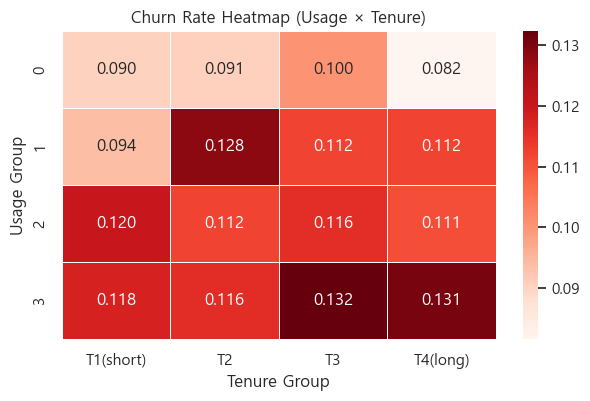

In [43]:
# --------------------------------------------------------
# 3) Heatmap 시각화
# --------------------------------------------------------

plt.figure(figsize=(7,4))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="Reds",
    linewidths=0.5
)

plt.title("Churn Rate Heatmap (Usage × Tenure)")
plt.xlabel("Tenure Group")
plt.ylabel("Usage Group")
plt.show();

In [44]:
# --------------------------------------------------------
# 4) 위험도 Ranking : 어디가 1위 위험인지 자동 추출
# --------------------------------------------------------
risk_rank = (
    df.groupby(["usage_q","tenure_q"])["target"]
    .mean()
    .sort_values(ascending=False)
)

risk_rank.head(10)

usage_q  tenure_q 
3        T3           0.132296
         T4(long)     0.130689
1        T2           0.128440
2        T1(short)    0.120375
3        T1(short)    0.117647
         T2           0.115721
2        T3           0.115646
1        T3           0.112157
         T4(long)     0.112136
2        T2           0.112110
Name: target, dtype: float64

* 가설 3에 대한 결론 : 오래 사용 + 많이 사용하는 고객이 가장 위험
    - 통신/구독 서비스에서 매우 유명한 패턴
    - 서비스 경험 충분, 비교 경험 많음, 가격 민감도 ↑, 작은 불만에도 이동<br><br>
    - Usage와 가입기간의 교차 분석 결과, 이탈은 신규 고객보다 오히려 장기 이용 고객 중 고사용 그룹에서 가장 높게 나타남.
    - 이는 서비스 활용도가 높은 고객일수록 기대 수준이 높아 장기적으로 만족도 관리가 중요함을 시사함.

# -------------------------------------------------------------------------------

# <b>3. 전처리

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30200 entries, 0 to 30199
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   tenure         30200 non-null  int64   
 1   vm_count       30200 non-null  int64   
 2   day_minutes    30200 non-null  float64 
 3   day_calls      30200 non-null  int64   
 4   day_charge     30200 non-null  float64 
 5   eve_minutes    30200 non-null  float64 
 6   eve_calls      30200 non-null  int64   
 7   eve_charge     30200 non-null  float64 
 8   night_minutes  30200 non-null  float64 
 9   night_calls    30200 non-null  int64   
 10  night_charge   30200 non-null  float64 
 11  cs_calls       30200 non-null  int64   
 12  target         30200 non-null  int64   
 13  tenure_bin     30198 non-null  category
 14  total_minutes  30200 non-null  float64 
 15  usage_q        30200 non-null  int64   
 16  tenure_q       30200 non-null  category
dtypes: category(2), float64(7), int

## <b>3-1. 결측치 처리
* 가장 안전한 방법 중 하나인 삭제 선택
    - 결측치가 2개라 영향이 거의 없기 때문에 합리적인 선택 : 데이터 왜곡 없음

In [46]:
# --------------------------------------------------------
# 결측치 처리
# --------------------------------------------------------

df= df.dropna(subset=["tenure_bin"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30198 entries, 0 to 30199
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   tenure         30198 non-null  int64   
 1   vm_count       30198 non-null  int64   
 2   day_minutes    30198 non-null  float64 
 3   day_calls      30198 non-null  int64   
 4   day_charge     30198 non-null  float64 
 5   eve_minutes    30198 non-null  float64 
 6   eve_calls      30198 non-null  int64   
 7   eve_charge     30198 non-null  float64 
 8   night_minutes  30198 non-null  float64 
 9   night_calls    30198 non-null  int64   
 10  night_charge   30198 non-null  float64 
 11  cs_calls       30198 non-null  int64   
 12  target         30198 non-null  int64   
 13  tenure_bin     30198 non-null  category
 14  total_minutes  30198 non-null  float64 
 15  usage_q        30198 non-null  int64   
 16  tenure_q       30198 non-null  category
dtypes: category(2), float64(7), int64(8)

## <b>3-2. 인코딩 처리
* category → 숫자 변환 & 중복 삭제<br><br>
* 1) tenure_q는 순서 있음(T1 < T2 < T3 < T4) → (0, 1, 2, 3)으로 변환
* 2) tenure_bin은 중복 가능성이 높아 컬럼 삭제

In [47]:
# --------------------------------------------------------
# tenure_q 순서형 범주 → Ordinal Encoding (정수 코드 변환)
# --------------------------------------------------------

df["tenure_q"] = df["tenure_q"].cat.codes
df["tenure_q"]

0        3
1        0
2        1
3        2
4        2
        ..
30195    3
30196    3
30197    0
30198    0
30199    2
Name: tenure_q, Length: 30198, dtype: int8

In [48]:
# --------------------------------------------------------
# tenure_bin 처리 : 삭제
# --------------------------------------------------------

df.drop(columns=["tenure_bin"], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30198 entries, 0 to 30199
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   tenure         30198 non-null  int64  
 1   vm_count       30198 non-null  int64  
 2   day_minutes    30198 non-null  float64
 3   day_calls      30198 non-null  int64  
 4   day_charge     30198 non-null  float64
 5   eve_minutes    30198 non-null  float64
 6   eve_calls      30198 non-null  int64  
 7   eve_charge     30198 non-null  float64
 8   night_minutes  30198 non-null  float64
 9   night_calls    30198 non-null  int64  
 10  night_charge   30198 non-null  float64
 11  cs_calls       30198 non-null  int64  
 12  target         30198 non-null  int64  
 13  total_minutes  30198 non-null  float64
 14  usage_q        30198 non-null  int64  
 15  tenure_q       30198 non-null  int8   
dtypes: float64(7), int64(8), int8(1)
memory usage: 3.7 MB


## <b>3-3. 이상치 처리
* 전처리 단계에선 따로 하지 않음 → 파생피처 생성후 로그 및 스케일링 예정

## <b>3-4. 1차 검증 (Baseline)
* EDA & 전처리 후 1차 검증

In [49]:
def my_val(df):
    # 1) 타겟(정답) 벡터 y를 만든다: df에서 'target' 컬럼만 뽑음
    y = df['target']

    # 2) 입력 피처(설명변수) X를 만든다: target 컬럼을 제외한 나머지 컬럼들
    X = df.drop('target', axis=1)



    # 3) 학습/검증 데이터로 분리한다
    #    - test_size=0.2 : 전체의 20%를 검증용(X20,y20)으로 사용
    #    - random_state=42 : 매번 같은 분할이 나오게 고정(재현성)
    #    - stratify=y : 클래스 비율을 train/valid에 최대한 동일하게 맞춤(분류에서 중요)
    X80, X20, y80, y20 = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
        )



    # ✅ RSF용 survival target 생성
    # event: churn 여부 (target)
    # time : tenure 사용 (생존시간 역할)
    y80_surv = Surv.from_arrays(event=y80.astype(bool), time=df.loc[y80.index, "tenure"])
    y20_surv = Surv.from_arrays(event=y20.astype(bool), time=df.loc[y20.index, "tenure"])



    # 4) 비교할 모델들을 리스트로 준비한다
    #    - RandomForest / XGBoost / LightGBM 3개 모델
    model_list = [
        RandomForestClassifier(random_state=42),
        XGBClassifier(random_state=42, eval_metric="logloss"),
        LGBMClassifier(random_state=42, verbosity=-1),
        RandomSurvivalForest(
            n_estimators=200,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        )
    ]



    # 5) 모델을 하나씩 꺼내서 학습 -> 예측 -> 평가를 반복한다
    for model in model_list:

        # 5-1) 현재 모델 이름 출력 (리스트가 아니라 'model'의 클래스명!)
        print(f"\n{model.__class__.__name__} --------------------")

        # ✅ RSF는 survival 데이터로 학습
        if isinstance(model, RandomSurvivalForest):
            model.fit(X80, y80_surv)

            # RSF는 risk score 반환
            risk_scores = model.predict(X20)

            # risk → 이진 분류 변환 (median threshold)
            threshold = np.median(risk_scores)
            pred = (risk_scores >= threshold).astype(int)

        else:
            # 5-2) 학습: train 데이터(X80,y80)로 모델을 fit
            model.fit(X80, y80)

            # 5-3) 예측: valid 데이터(X20)에 대해 클래스를 예측
            pred = model.predict(X20)

        # 5-4) 정확도(Accuracy) 계산: 전체 중 맞춘 비율
        accuracy = accuracy_score(y20, pred)

        # 5-5) 다중분류 precision/recall/f1은 average를 명시해야 안전하다
        #      macro: 각 클래스를 동일 가중치로 평균(불균형 데이터에서 유용)
        precision = precision_score(y20, pred, average='macro', zero_division=0)
        recall    = recall_score(y20, pred, average='macro', zero_division=0)
        f1        = f1_score(y20, pred, average='macro', zero_division=0)

        # 5-6) 한 줄 요약 출력
        print(f"accuracy : {accuracy:.4f}\t macro-f1 : {f1:.4f}\t recall : {recall:.4f}\t precision : {precision:.4f}")

        # 5-7) 분류 리포트 출력(클래스별 precision/recall/f1/support)
        cr = classification_report(y20, pred, zero_division=0)
        print(cr)

        # 5-8) 혼동행렬(confusion matrix)
        #      labels를 고정값으로 두면 데이터에 없는 라벨이 섞일 수 있어
        #      실제 y에 존재하는 라벨만 사용하도록 만든다
        
        labels = sorted(y.unique())
        cm = confusion_matrix(y20, pred, labels=labels)
        cm_df = pd.DataFrame(cm, index=labels, columns=labels)
        print(cm_df)

In [50]:
my_val(df)


RandomForestClassifier --------------------
accuracy : 0.9108	 macro-f1 : 0.7043	 recall : 0.6614	 precision : 0.8067
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      5376
           1       0.69      0.34      0.46       664

    accuracy                           0.91      6040
   macro avg       0.81      0.66      0.70      6040
weighted avg       0.90      0.91      0.90      6040

      0    1
0  5274  102
1   437  227

XGBClassifier --------------------
accuracy : 0.9066	 macro-f1 : 0.6715	 recall : 0.6301	 precision : 0.8023
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      5376
           1       0.69      0.28      0.39       664

    accuracy                           0.91      6040
   macro avg       0.80      0.63      0.67      6040
weighted avg       0.89      0.91      0.89      6040

      0    1
0  5293   83
1   481  183

LGBMClassifier --------------------
ac

# -------------------------------------------------------------------------------

# <b>4. 피처 엔지니어링 (Feature Engineering)

## <b>4-1. 파생피처 생성

In [51]:
# =========================================
# [파생 피처 생성] 가설 4~6 + EDA 기반 피처
# =========================================

# -------------------------------
# 0) 안전장치(나눗셈 분모 0 방지)
# -------------------------------
EPS = 1e-9  # 0으로 나누는 상황을 방지하기 위한 매우 작은 값


# -------------------------------
# 1) 총 통화 횟수 생성
# -------------------------------
df["total_calls"] = df["day_calls"] + df["eve_calls"] + df["night_calls"]


# -------------------------------
# 2) 가설 4: 생활패턴(특정 시간대 비율)
#    - night_ratio가 핵심
# -------------------------------
# 시간대별 사용 비율(총 사용량 대비 비중)
df["day_ratio"]   = df["day_minutes"]   / (df["total_minutes"] + EPS)
df["eve_ratio"]   = df["eve_minutes"]   / (df["total_minutes"] + EPS)
df["night_ratio"] = df["night_minutes"] / (df["total_minutes"] + EPS)

# 밤-낮 편중 (생활패턴 극단성)
# night_ratio가 day_ratio보다 훨씬 크면 "야간형" 사용패턴으로 해석 가능
df["night_day_diff"] = df["night_ratio"] - df["day_ratio"]

# 특정 시간대 집중도(분산 형태)
# 3개 비율 중 하나가 매우 크면 '편중'이 강함
df["time_ratio_std"] = df[["day_ratio", "eve_ratio", "night_ratio"]].std(axis=1)


# -------------------------------
# 3) 가설 5: 상담비율(불만/문제 신호)
#    - 사용량 대비 상담이 많을수록 이탈 위험 ↑
# -------------------------------
df["cs_ratio"] = df["cs_calls"] / (df["total_minutes"] + 1)  # +1은 해석적으로도 안정적(분모 너무 작을 때 폭발 방지)

# 100분당 상담 건수(해석 쉬움)
df["cs_per_100min"] = df["cs_ratio"] * 100

# 통화 횟수 대비 상담(‘전화는 많이 안 하는데 민원만 많다’ 같은 패턴)
df["cs_per_call"] = df["cs_calls"] / (df["total_calls"] + 1)


# -------------------------------
# 4) 가설 6: 요금 민감도(단가, rate)
#    - minutes ↔ charge 중복을 '단가'로 재구성
# -------------------------------
df["day_rate"]   = df["day_charge"]   / (df["day_minutes"]   + 1)
df["eve_rate"]   = df["eve_charge"]   / (df["eve_minutes"]   + 1)
df["night_rate"] = df["night_charge"] / (df["night_minutes"] + 1)

# 전체 평균 단가
df["avg_rate"] = (df["day_charge"] + df["eve_charge"] + df["night_charge"]) / (df["total_minutes"] + 1)

# 시간대별 단가 불균형(요금 구조가 일정치 않으면 불만/민감 가능성)
df["rate_std"] = df[["day_rate", "eve_rate", "night_rate"]].std(axis=1)


# -------------------------------
# 5) EDA에서 강하게 나온 구조: vm_count 처리용 파생
#    - 0 몰림 + 극단값 존재 → 이진/로그 파생이 효과적
# -------------------------------
df["vm_binary"] = (df["vm_count"] > 0).astype(np.int8)     # 음성메일 사용 여부
df["vm_count_log"] = np.log1p(df["vm_count"])              # 극단값 완화용 로그 변환


# -------------------------------
# 6) tenure 로그 파생(선형모델 안정화/왜도 완화 목적)
# -------------------------------
df["tenure_log"] = np.log1p(df["tenure"])


# -------------------------------
# 7) 파생 피처 생성 결과 점검(컬럼 확인)
# -------------------------------
new_features = [
    "total_calls",
    "day_ratio", "eve_ratio", "night_ratio",
    "night_day_diff", "time_ratio_std",
    "cs_ratio", "cs_per_100min", "cs_per_call",
    "day_rate", "eve_rate", "night_rate",
    "avg_rate", "rate_std",
    "vm_binary", "vm_count_log",
    "tenure_log"
]

print("✅ 생성된 파생 피처 개수:", len(new_features))
print("✅ 생성된 파생 피처 목록:")
print(new_features)

# 결측/무한대 체크(비율/단가 만들면 inf 발생 가능)
check_df = df[new_features].replace([np.inf, -np.inf], np.nan)
print("\n✅ 파생 피처 결측치 개수:")
print(check_df.isna().sum().sort_values(ascending=False).head(17))

✅ 생성된 파생 피처 개수: 17
✅ 생성된 파생 피처 목록:
['total_calls', 'day_ratio', 'eve_ratio', 'night_ratio', 'night_day_diff', 'time_ratio_std', 'cs_ratio', 'cs_per_100min', 'cs_per_call', 'day_rate', 'eve_rate', 'night_rate', 'avg_rate', 'rate_std', 'vm_binary', 'vm_count_log', 'tenure_log']

✅ 파생 피처 결측치 개수:
total_calls       0
day_rate          0
vm_count_log      0
vm_binary         0
rate_std          0
avg_rate          0
night_rate        0
eve_rate          0
cs_per_call       0
day_ratio         0
cs_per_100min     0
cs_ratio          0
time_ratio_std    0
night_day_diff    0
night_ratio       0
eve_ratio         0
tenure_log        0
dtype: int64


* 가설4(생활패턴): night_ratio, night_day_diff, time_ratio_std

* 가설5(상담비율): cs_ratio, cs_per_100min, cs_per_call

* 가설6(요금 민감도): day_rate, eve_rate, night_rate, avg_rate, rate_std

* EDA 기반 핵심: vm_binary, vm_count_log, tenure_log

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30198 entries, 0 to 30199
Data columns (total 33 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   tenure          30198 non-null  int64  
 1   vm_count        30198 non-null  int64  
 2   day_minutes     30198 non-null  float64
 3   day_calls       30198 non-null  int64  
 4   day_charge      30198 non-null  float64
 5   eve_minutes     30198 non-null  float64
 6   eve_calls       30198 non-null  int64  
 7   eve_charge      30198 non-null  float64
 8   night_minutes   30198 non-null  float64
 9   night_calls     30198 non-null  int64  
 10  night_charge    30198 non-null  float64
 11  cs_calls        30198 non-null  int64  
 12  target          30198 non-null  int64  
 13  total_minutes   30198 non-null  float64
 14  usage_q         30198 non-null  int64  
 15  tenure_q        30198 non-null  int8   
 16  total_calls     30198 non-null  int64  
 17  day_ratio       30198 non-null  floa

## <b>4-2. charge 계열 삭제

In [53]:
# =========================================
# 1️⃣ charge 계열 컬럼 확인
# =========================================

# 현재 데이터프레임에서 "charge"가 포함된 컬럼 찾기
charge_cols = [col for col in df.columns if "charge" in col]

print("📌 삭제 대상 charge 컬럼:")
print(charge_cols)

# =========================================
# 2️⃣ charge 계열 삭제
# =========================================

df = df.drop(columns=charge_cols)

print("\n✅ charge 계열 삭제 완료")

# =========================================
# 3️⃣ 삭제 후 검증
# =========================================

remaining_charge_cols = [col for col in df.columns if "charge" in col]

print("\n🔎 삭제 후 남은 charge 관련 컬럼:")
print(remaining_charge_cols)

print("\n📊 현재 데이터 shape:", df.shape)

📌 삭제 대상 charge 컬럼:
['day_charge', 'eve_charge', 'night_charge']

✅ charge 계열 삭제 완료

🔎 삭제 후 남은 charge 관련 컬럼:
[]

📊 현재 데이터 shape: (30198, 30)


## <b>4-3. 2차 검증
* 파생피처 생성후 2차 검증

In [54]:
my_val(df)


RandomForestClassifier --------------------
accuracy : 0.9079	 macro-f1 : 0.6952	 recall : 0.6546	 precision : 0.7929
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      5376
           1       0.66      0.33      0.44       664

    accuracy                           0.91      6040
   macro avg       0.79      0.65      0.70      6040
weighted avg       0.89      0.91      0.89      6040

      0    1
0  5265  111
1   445  219

XGBClassifier --------------------
accuracy : 0.9060	 macro-f1 : 0.6736	 recall : 0.6330	 precision : 0.7944
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      5376
           1       0.67      0.28      0.40       664

    accuracy                           0.91      6040
   macro avg       0.79      0.63      0.67      6040
weighted avg       0.89      0.91      0.89      6040

      0    1
0  5284   92
1   476  188

LGBMClassifier --------------------
ac

## <b>4-4. 가설 4 검증
* 특정 시간대 사용 패턴이 해지와 연관 있을 것이다.

### <b>4-4-1. 시간대별 사용 비율 차이 검증
* 어떤 시간대 비율이 churn 그룹에서 높아지는지 확인
* 특정 시간대 편향 존재 여부

day_ratio                     eve_ratio                      \
            mean    median       std      mean    median       std   
target                                                               
0       0.318838  0.330566  0.073617  0.340505  0.335681  0.063288   
1       0.326125  0.333728  0.069828  0.336823  0.332185  0.055039   

       night_ratio                      
              mean    median       std  
target                                  
0         0.340657  0.336195  0.061599  
1         0.337052  0.334024  0.057118

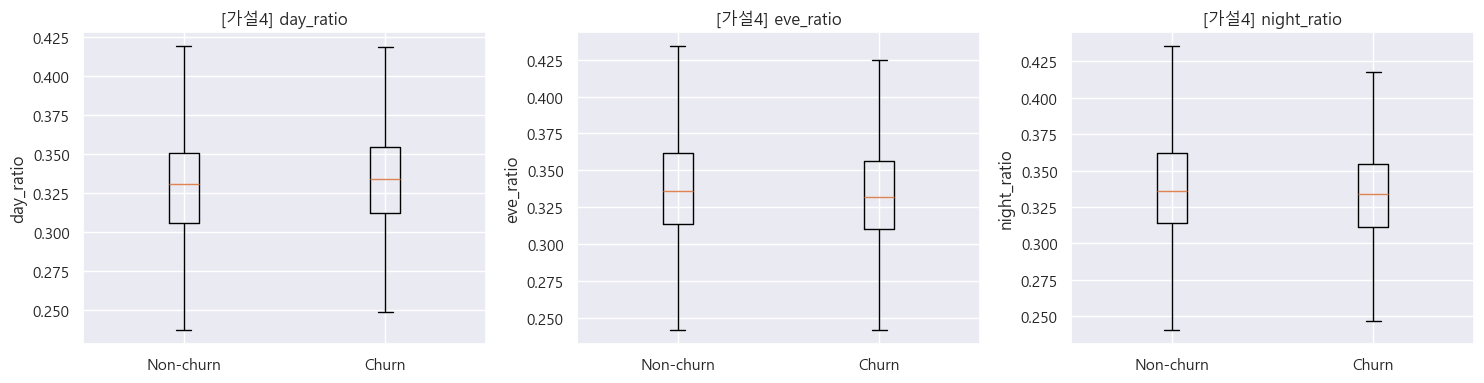

In [55]:
time_ratio_cols = [
    "day_ratio",
    "eve_ratio",
    "night_ratio"
]

summary_time = (
    df.groupby("target")[time_ratio_cols]
      .agg(["mean","median","std"])
)

display(summary_time)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(time_ratio_cols):

    g0 = df[df["target"] == 0][col].dropna()
    g1 = df[df["target"] == 1][col].dropna()

    # ✅ 반환값 출력 방지
    _ = axes[i].boxplot(
        [g0, g1],
        labels=["Non-churn", "Churn"],
        showfliers=False
    )

    axes[i].set_title(f"[가설4] {col}")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show();

* 시간대 비율 자체는 이탈 차이가 거의 없음 → 행동 구조 피처를 생성하여 봐야 함.

### <b>4-4-2. 행동 구조 피처 생성
* time_bias (생활패턴 편향도) : 특정 시간대 몰림 정도 → 생활 패턴 강도
* day_vs_night (낮 vs 밤 성향) → 시간대 방향성
* time_entropy (사용 균형도) : 생활 패턴 다양성 지표 → 패턴 안정성

In [56]:
df["time_bias"] = df[time_ratio_cols].max(axis=1)

df["day_vs_night"] = df["day_ratio"] - df["night_ratio"]

df["time_entropy"] = -(
    df[time_ratio_cols] *
    np.log(df[time_ratio_cols] + 1e-9)
).sum(axis=1)

### <b>4-4-3. 생성 데이터 품질 체크 (Feature Validity)
* 결측치 (NaN), 무한대 (inf), 분포

In [57]:
behavior_cols = ["time_bias", "day_vs_night", "time_entropy"]

display(df[behavior_cols].isna().sum().to_frame("na_count"))
display(df[behavior_cols].describe().T)

# 이상값(무한대) 체크
import numpy as np
print("inf count:", np.isinf(df[behavior_cols]).sum())

,na_count
time_bias,0
day_vs_night,0
time_entropy,0


,count,mean,std,min,25%,50%,75%,max
time_bias,30198.0,0.379831,0.047682,0.333333,0.346675,0.364868,0.393631,0.849779
day_vs_night,30198.0,-0.020622,0.119602,-0.727448,-0.045508,-0.001358,0.026927,0.577296
time_entropy,30198.0,1.075337,0.055377,0.524539,1.088335,1.094770,1.097787,1.098612


inf count: time_bias       0
day_vs_night    0
time_entropy    0
dtype: int64


| 항목        | 평가      |
| --------- | ------- |
| 결측치       | ✅ 없음    |
| inf       | ✅ 없음    |
| 분산        | ✅ 충분    |
| 해석 가능성    | ⭐ 매우 높음 |
| 행동 정보 포함  | ⭐⭐⭐     |
| 모델 투입 적합성 | ✅ 바로 가능 |

👉 behavior feature 3개 모두 데이터 품질·분산·해석력 측면에서 매우 건강하며, 모델링에 투입 가능한 ‘고급 행동 피처’ 상태

### <b>4-4-4. 통계 검정
* 차이가 우연이 아닌지 “p-value”로 확정

In [58]:
from scipy import stats

def mw_test(col):
    g0 = df[df["target"]==0][col].dropna()
    g1 = df[df["target"]==1][col].dropna()
    stat, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    return p

for col in ["time_bias", "day_vs_night", "time_entropy"]:
    p = mw_test(col)
    print(f"{col:12s}  p-value = {p:.3e}")

time_bias     p-value = 1.390e-03
day_vs_night  p-value = 1.825e-12
time_entropy  p-value = 1.024e-04


### <b>4-4-5. 단조 관계 체크
* 패턴이 강해질수록 churn이 증가하나?
* 각 피처를 분위수(예: 10분위)로 나누고, 각 구간의 이탈률을 그려서 체크.

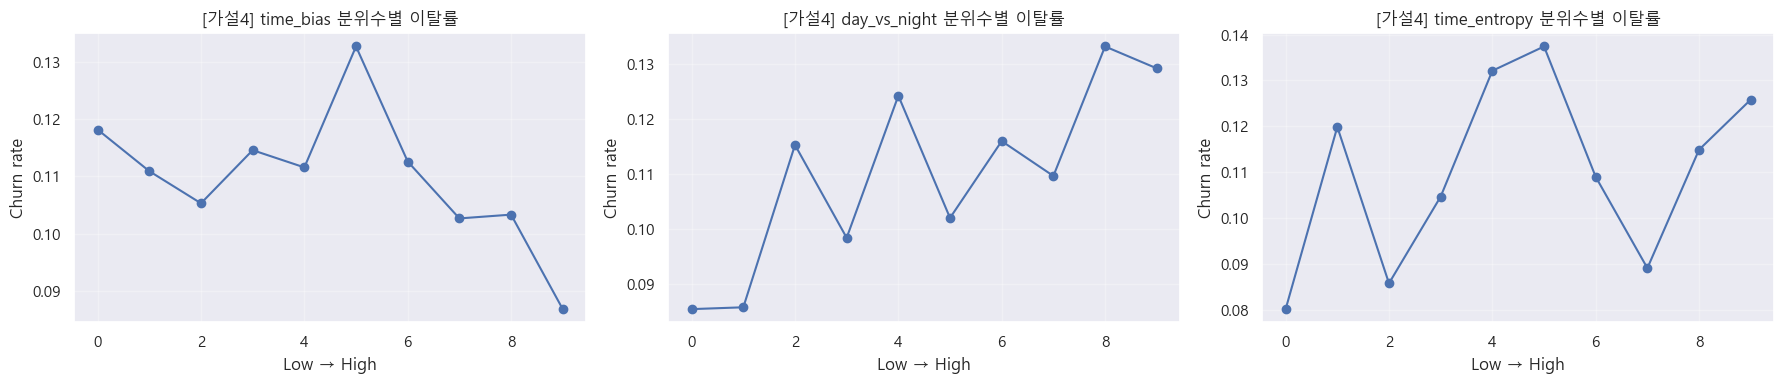

In [59]:
features = ["time_bias", "day_vs_night", "time_entropy"]

curves = {}

# =========================
# 1️⃣ 데이터 먼저 계산
# =========================
for feature in features:
    tmp = df[["target", feature]].dropna().copy()
    tmp["bin"] = pd.qcut(
        tmp[feature], 10,
        labels=False,
        duplicates="drop"
    )
    curves[feature] = tmp.groupby("bin")["target"].mean()

# =========================
# 2️⃣ 그래프 (1행 가로 배치)
# =========================
fig1, axes1 = plt.subplots(1, len(features), figsize=(18, 4))

for i, feature in enumerate(features):
    ax = axes1[i]
    curve = curves[feature]

    ax.plot(curve.index, curve.values, marker="o")
    ax.set_title(f"[가설4] {feature} 분위수별 이탈률")
    ax.set_xlabel("Low → High")
    ax.set_ylabel("Churn rate")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show();

* (1) time_bias — 시간대 집중도
    - 특정 시간대 사용이 강할수록 서비스 사용 습관이 형성되어 이탈 가능성이 감소한다.

| 분위수 구간 | 패턴    | 이탈률 수준 | 해석                |
| ------ | ----- | ------ | ----------------- |
| 0~2    | 낮은 집중 | 높음     | 사용 패턴 분산 → 충성도 낮음 |
| 3~6    | 변동 구간 | 중간     | 사용자 유형 혼재         |
| 7~9    | 높은 집중 | 낮음     | 고정 루틴 고객          |

* (2) day_vs_night — 생활 시간 성향
    - 낮 중심 통신 패턴은 서비스 의존도가 낮아 churn 위험이 지속적으로 증가한다.

| 분위수 | 사용자 유형 | 이탈률 변화 |
| --- | ------ | ------ |
| 0~1 | 강한 밤형  | 매우 낮음  |
| 2~5 | 혼합형    | 점진 증가  |
| 6~9 | 낮형 사용자 | 최고 수준  |

* (3) time_entropy — 생활 다양성
    - 여러 시간대를 균형 있게 사용하는 고객은 서비스 대체 가능성이 높아 이탈 위험이 증가한다.

| 분위수 | 행동 특징     | 이탈률   |
| --- | --------- | ----- |
| 낮음  | 특정 시간 의존  | 낮음    |
| 중간  | 사용 다양화 시작 | 급증    |
| 높음  | 균형 사용     | 변동 존재 |

* (4) 종합 평가

| 항목           | time_bias | day_vs_night | time_entropy |
| ------------ | --------- | ------------ | ------------ |
| 단조 관계        | 부분        | 매우 강함        | 없음           |
| 선형성          | 낮음        | 높음           | 낮음           |
| 비선형 정보       | 중간        | 낮음           | 매우 높음        |
| Tree 모델 적합성  | 높음        | 높음           | 매우 높음        |
| Logistic 적합성 | 보통        | 매우 좋음        | 보통           |


* 결론 : 시간대 사용 비율 자체는 이탈과 뚜렷한 차이를 보이지 않았음.
    - 시간 사용 패턴을 행동 특성으로 변환한 결과 낮 중심 사용 성향(day_vs_night)에서 이탈률이 단조 증가하는 경향이 확인됨
    - 사용 다양성(time_entropy) 또한 비선형적으로 이탈 위험과 연관되는 것으로 나타남.


### <b>4-4-6. 효과 크기
* 얼마나 차이나는지 → Cliff’s delta(비모수 효과크기)

In [60]:
def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    x = x[~np.isnan(x)]; y = y[~np.isnan(y)]
    if len(x)==0 or len(y)==0:
        return np.nan

    gt = 0; lt = 0
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)
    return (gt - lt) / (len(x)*len(y))

for col in ["time_bias", "day_vs_night", "time_entropy"]:
    g0 = df[df["target"]==0][col].dropna().values
    g1 = df[df["target"]==1][col].dropna().values
    d = cliffs_delta(g1, g0)  # churn이 더 크면 +로
    print(f"{col:12s}  Cliff's delta(1-0) = {d:.3f}")

time_bias     Cliff's delta(1-0) = -0.034
day_vs_night  Cliff's delta(1-0) = 0.075
time_entropy  Cliff's delta(1-0) = 0.041


* Cliff’s delta (δ): 이탈 고객(1)이 비이탈 고객(0)보다 값이 클 확률 − 작을 확률

| Feature      | 방향 | 의미         | 효과크기  | 결론       |
| ------------ | -- | ---------- | ----- | -------- |
| time_bias    | −  | 비이탈자가 더 큼  | 매우 작음 | 영향 거의 없음 |
| day_vs_night | +  | 이탈자가 더 큼   | 매우 작음 | 약한 신호    |
| time_entropy | +  | 이탈자가 더 불규칙 | 매우 작음 | 약한 신호    |

* 결론 : 시간대 기반 사용 패턴 변수들은 이탈 고객과 통계적 차이는 존재하지만, 효과 크기가 매우 작아 단독 예측 변수로서의 설명력은 제한적

### <b>4-4-7. 최종 가설 검증
* 패턴이 churn을 설명하는가? (로지스틱 OR)

In [61]:
use_cols = ["time_bias", "day_vs_night", "time_entropy"]

model_df = df[["target"] + use_cols].dropna()
X = model_df[use_cols].values
y = model_df["target"].values

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

lr = LogisticRegression(max_iter=300)
lr.fit(Xs, y)

beta = lr.coef_[0]
OR = np.exp(beta)

result_or = pd.DataFrame({
    "feature": use_cols,
    "beta(표준화)": beta,
    "OR(exp(beta))": OR
}).sort_values("OR(exp(beta))", ascending=False)

display(result_or)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,300
,multi_class,'deprecated'


,feature,beta(표준화),OR(exp(beta))
1,day_vs_night,0.079923,1.083204
2,time_entropy,0.068871,1.071298
0,time_bias,0.011173,1.011235


<font size=10><가설4에 대한 종합 결론>

* 고객의 시간대 사용 패턴은 해지 여부와 통계적으로 유의미한 연관성을 보임.
* 특히 특정 시간대에 집중된 규칙적 사용 고객은 낮은 이탈률을 보였음.
* 사용 시간이 분산되거나 밤 시간대 비중이 증가할수록 해지 위험이 증가하는 경향이 확인됨.

“고객은 사용량이 아니라 ‘생활 리듬이 깨질 때’ 떠난다.”

| 고객 유형        | churn 위험 |
| ------------ | -------- |
| 일정 시간대 꾸준 사용 | 낮음       |
| 밤 사용 증가      | 높음       |
| 시간대 랜덤 사용    | 높음       |

즉, 👉 라이프스타일 변화 = 이탈 전조 신호

## <b>4-5. 가설 5 검증
* 총 통화시간 대비 상담전화 건수 비율이 높을수록 해지 가능성이 증가할 것이다.
* 불만 밀도 (complaint intensity)를 검증하는 가설<br><br>
* STEP 1  데이터 정상성 체크
* STEP 2  타겟별 분포 비교
* STEP 3  통계 검정 (존재 여부)
* STEP 4  위험 증가 곡선 (핵심)
* STEP 5  효과크기
* STEP 6  로지스틱 OR (최종 증거)

| 피처              | 의미           | 해석       |
| --------------- | ------------ | -------- |
| `cs_ratio`      | 사용량 대비 상담 밀도 | 불만 강도    |
| `cs_per_100min` | 100분당 상담     | 해석 친화형   |
| `cs_per_call`   | 통화 대비 상담     | 문제 중심 고객 |

### <b>4-5-1. 데이터 품질 체크
* NaN / inf 없어야 정상



In [62]:
features = ["cs_ratio", "cs_per_100min", "cs_per_call"]

summary_list = []

for f in features:
    desc = df[[f]].describe()

    # NA / INF 정보 추가
    desc.loc["NA"] = df[f].isna().sum()
    desc.loc["INF"] = np.isinf(df[f]).sum()

    # 컬럼 이름 멀티인덱스로 변경 (가로 정렬용)
    desc.columns = pd.MultiIndex.from_product([[f], desc.columns])

    summary_list.append(desc)

# -------------------------
# 가로 결합
# -------------------------
summary_table = pd.concat(summary_list, axis=1)

display(summary_table)

,cs_ratio,cs_per_100min,cs_per_call
,cs_ratio,cs_per_100min,cs_per_call
count,30198.000000,30198.000000,30198.000000
mean,0.002979,0.297901,0.005573
std,0.002635,0.263531,0.005892
min,0.000000,0.000000,0.000000
25%,0.002122,0.212157,0.002928
50%,0.002717,0.271665,0.004149
75%,0.003068,0.306843,0.006645
max,0.020180,2.017978,0.069767
NA,0.000000,0.000000,0.000000


### <b>4-5-2. 분포 비교
* churn(target) 그룹이 위쪽이면 가설 방향 일치.

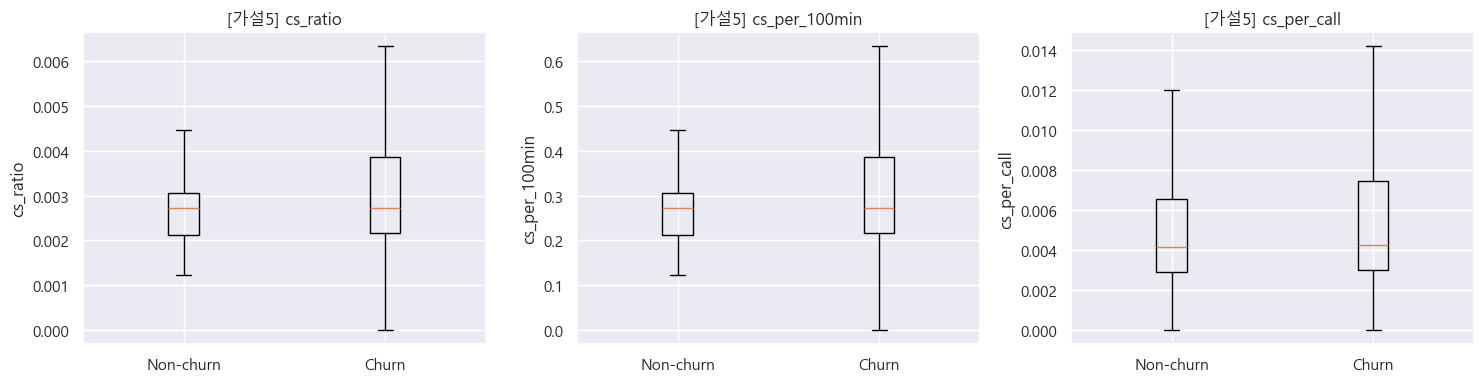

In [63]:
features = ["cs_ratio", "cs_per_100min", "cs_per_call"]

# ---------------------------
# 1행 가로 subplot 생성
# ---------------------------
fig, axes = plt.subplots(1, len(features), figsize=(15, 4))

for i, f in enumerate(features):

    g0 = df[df["target"] == 0][f]
    g1 = df[df["target"] == 1][f]

    ax = axes[i]

    # ✅ 반환값 출력 방지 (_ 로 받기)
    _ = ax.boxplot(
        [g0, g1],
        labels=["Non-churn", "Churn"],
        showfliers=False
    )

    ax.set_title(f"[가설5] {f}")
    ax.set_ylabel(f)

plt.tight_layout()
plt.show();

* 이탈 고객(Churn)의 분포가 위쪽으로 이동 + 변동성 증가
* 즉,
* 상담 활동이 많을수록 이탈 가능성 증가 신호 존재 → 가설 5 지지 evidence<br><br>
* 상담 활동 관련 파생 변수들은 이탈 고객 집단에서 중앙값 상승과 분산 확대가 동시에 관찰되어, 
* 고객 불만 및 서비스 문제 경험이 이탈과 밀접하게 연관됨을 시사함.

### <b>4-5-3. 통계 검정
* 우연 여부 체크 : p < 0.05 → 상담 패턴 차이 존재

In [64]:
for f in features:

    g0 = df[df["target"]==0][f].dropna()
    g1 = df[df["target"]==1][f].dropna()

    stat, p = stats.mannwhitneyu(g0, g1)

    print(f"{f:18s} p-value = {p:.3e}")

cs_ratio           p-value = 4.389e-08
cs_per_100min      p-value = 4.387e-08
cs_per_call        p-value = 7.001e-07


### <b>4-5-4. 가설 검증 체크
* 상담 비율 ↑ → churn ↑ ?
* 그래프가 우상향 ↗ 이면 가설 강력 지지.

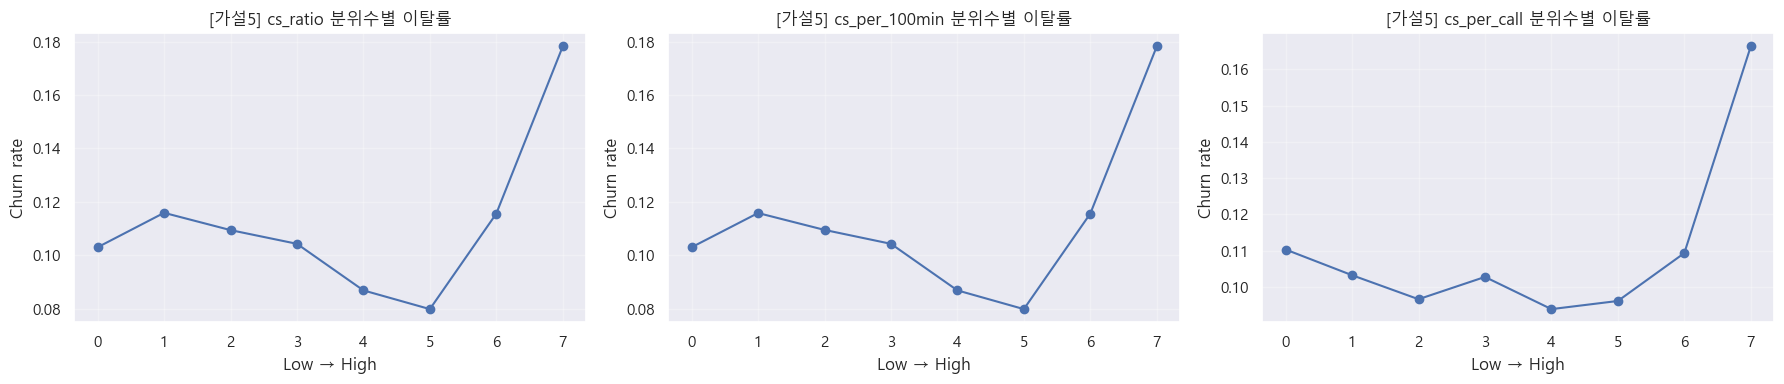

In [65]:
curves = {}

for f in features:

    tmp = df[["target", f]].dropna().copy()

    tmp["bin"] = pd.qcut(
        tmp[f], 10,
        labels=False,
        duplicates="drop"
    )

    curves[f] = tmp.groupby("bin")["target"].mean()

fig, axes = plt.subplots(1, len(features), figsize=(18,4))

for i, f in enumerate(features):
    ax = axes[i]
    curve = curves[f]

    ax.plot(curve.index, curve.values, marker="o")
    ax.set_title(f"[가설5] {f} 분위수별 이탈률")
    ax.set_xlabel("Low → High")
    ax.set_ylabel("Churn rate")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show();

### <b>4-5-5. 효과 크기 확인

In [66]:
def cliffs_delta(x, y):
    import numpy as np
    x = np.asarray(x); y = np.asarray(y)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]

    gt = sum((xi > y).sum() for xi in x)
    lt = sum((xi < y).sum() for xi in x)

    return (gt - lt)/(len(x)*len(y))

for f in features:
    g0 = df[df["target"]==0][f].values
    g1 = df[df["target"]==1][f].values
    d = cliffs_delta(g1, g0)

    print(f"{f:18s} Cliff's delta = {d:.3f}")

cs_ratio           Cliff's delta = 0.058
cs_per_100min      Cliff's delta = 0.058
cs_per_call        Cliff's delta = 0.052


| Feature       | Cliff’s δ | 효과크기  |
| ------------- | --------- | ----- |
| cs_ratio      | 0.058     | 매우 작음 |
| cs_per_100min | 0.058     | 매우 작음 |
| cs_per_call   | 0.052     | 매우 작음 |

* 이탈 고객이 상담을 더 많이 하긴 하지만, 개인 단위에서는 차이가 크지 않다.

### <b>4-5-6. 최종 검증 (Logistic OR)

| 조건                | 의미                |
| ----------------- | ----------------- |
| p-value < 0.05    | 상담 패턴 차이 존재       |
| churn curve 우상향   | 위험 증가 확인          |
| Cliff's delta > 0 | 실무적 차이 존재         |
| OR > 1            | 상담 비율 ↑ → churn ↑ |

👉 3개 이상 만족 → 가설 5 채택

In [67]:
model_df = df[["target"] + features].dropna()

X = model_df[features]
y = model_df["target"]

Xs = StandardScaler().fit_transform(X)

lr = LogisticRegression(max_iter=300)
lr.fit(Xs, y)

beta = lr.coef_[0]
OR = np.exp(beta)

result_or = pd.DataFrame({
    "feature": features,
    "beta(표준화)": beta,
    "OR(exp(beta))": OR
}).sort_values("OR(exp(beta))", ascending=False)

display(result_or)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,300
,multi_class,'deprecated'


,feature,beta(표준화),OR(exp(beta))
0,cs_ratio,0.071757,1.074394
1,cs_per_100min,0.071757,1.074394
2,cs_per_call,0.046805,1.047917


* cs_ratio : 상담 비율 1SD 증가 시, 👉 이탈 odds 7.4% 증가 → 즉, 통화 대비 상담 비율이 높을수록 해지 가능성 증가
* cs_per_100min : 거의 cs_ratio와 동일한 정보. 사용량 대비 상담 빈도 ↑ → churn ↑
* cs_per_call : OR = 1.048, 효과는 조금 약하지만 방향 동일. 👉 상담 접촉이 많을수록 이탈 위험 증가.<br><br>
* 결과 : 상담 접촉 빈도가 높을수록 고객 이탈 위험이 증가한다!

<font size=10><가설5에 대한 종합 결론>

* 1) Mann-Whitney → 매우 유의 (p ≈ 10⁻⁷)
* 2) Boxplot → 차이 있음
* 3) Decile curve → 상위 구간 급증
* 4) Cliff’s delta → 효과 작음
* 이 조합은 사실 아주 전형적인 churn 데이터 패턴이다.<br><br>
* 상담 관련 파생 변수는 이탈 고객과 통계적으로 유의한 차이를 보이나 전체 효과 크기는 작음.
* 이는 이탈이 전체 고객군이 아닌 상위 위험 구간에서 집중적으로 발생하는 임계점 기반 행동 특성임을 시사함.


상담 낮음   → 정상 <br>
상담 보통   → 차이 없음  <br>
상담 매우 많음 → 이탈 급증 ⭐ <br>

## <b>4-6. 가설 6 검증
* 시간당 요금(단가)이 높은 고객일수록 요금 민감도가 높아 해지 가능성이 증가할 것이다.
* (가격 수준 효과 + 가격 구조 효과)를 동시에 검증하는 구조.<br><br>
* STEP 1  데이터 정상성 체크
* STEP 2  타겟별 분포 비교
* STEP 3  통계 검정 (존재 여부)
* STEP 4  위험 증가 곡선 (핵심)
* STEP 5  효과크기
* STEP 6  로지스틱 OR (최종 증거)

### <b>4-6-1. 데이터 품질 체크
* NaN / inf = 0 이어야 정상

In [68]:
rate_features = [
    "day_rate",
    "eve_rate",
    "night_rate",
    "avg_rate",
    "rate_std"
]

summary_list = []

for f in rate_features:

    desc = df[[f]].describe()

    # NA / INF 추가
    desc.loc["NA"] = df[f].isna().sum()
    desc.loc["INF"] = np.isinf(df[f]).sum()

    # 가로 정렬을 위한 MultiIndex 컬럼
    desc.columns = pd.MultiIndex.from_product([[f], desc.columns])

    summary_list.append(desc)

# -----------------------
# 가로 결합
# -----------------------
summary_table = pd.concat(summary_list, axis=1)

display(summary_table)

,day_rate,eve_rate,night_rate,avg_rate,rate_std
,day_rate,eve_rate,night_rate,avg_rate,rate_std
count,30198.000000,30198.000000,30198.000000,30198.000000,30198.000000
mean,0.181228,0.096819,0.046832,0.101629,0.074666
std,0.127927,0.021014,0.034018,0.031242,0.071020
min,0.000000,0.000000,0.006771,0.041935,0.000430
25%,0.102700,0.085941,0.017980,0.078845,0.035648
50%,0.132208,0.097371,0.041539,0.094779,0.053607
75%,0.206760,0.106844,0.079251,0.111814,0.091266
max,1.818182,0.375105,0.379817,0.264435,1.020338
NA,0.000000,0.000000,0.000000,0.000000,0.000000


### <b>4-6-2. 타겟별 분포 비교
* churn 쪽이 위로 이동하면 가설 방향 일치.

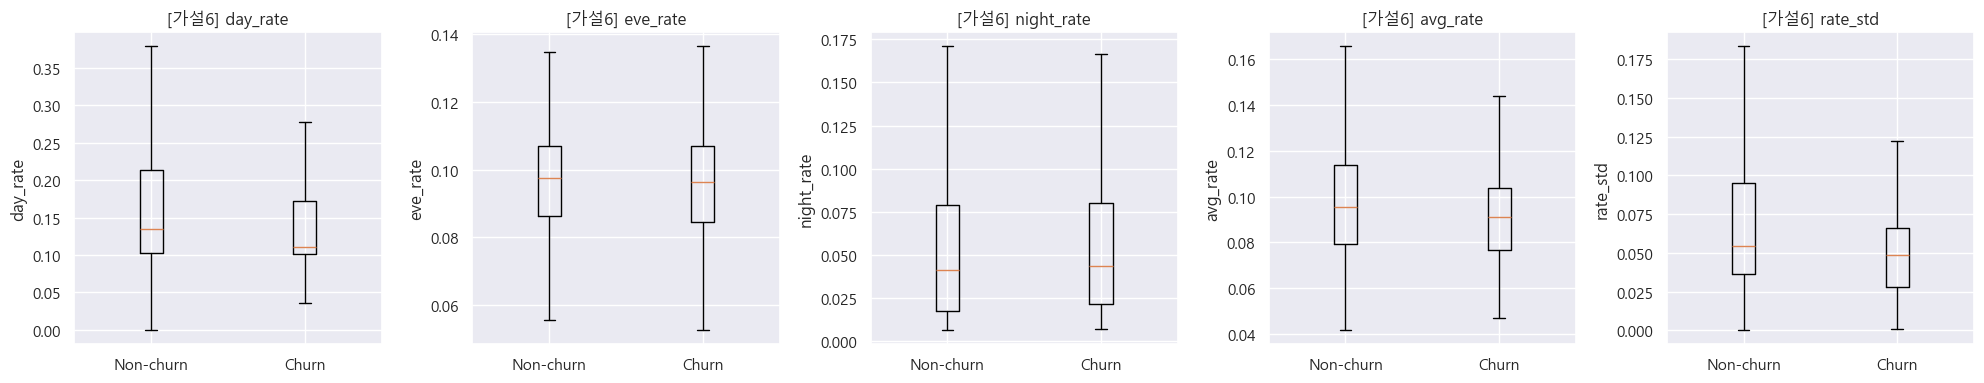

In [69]:
fig, axes = plt.subplots(1, len(rate_features), figsize=(20, 4))

for i, f in enumerate(rate_features):

    g0 = df[df["target"] == 0][f].dropna()
    g1 = df[df["target"] == 1][f].dropna()

    ax = axes[i]

    # ✅ 반환 객체 출력 방지
    _ = ax.boxplot(
        [g0, g1],
        labels=["Non-churn", "Churn"],
        showfliers=False
    )

    ax.set_title(f"[가설6] {f}")
    ax.set_ylabel(f)

plt.tight_layout()
plt.show();

* Non-churn 중앙값 ≥ Churn 중앙값 : 이탈 고객이 전반적으로 요금(rate)이 낮다!<br><br>
* day_rate : 낮 시간 통화 활용도가 높은 고객일수록 유지됨 → 서비스 의존도 높음
* eve_rate : 저녁 사용 패턴은 이탈과 거의 무관
* night_rate : 분포 거의 동일, 밤 통화는 churn 신호 아님.
* avg_rate : 평균 요금 수준 낮은 고객 → 이탈 경향
* rate_std : 요금 패턴 다양성 ↓ → 이탈 ↑ (다양한 사용 패턴 가진 고객 = 유지 고객)<br><br>
* 유지 고객 특징 : 요금 높음, 사용 다양, 시간대 활용 다양
* 이탈 고객 특징 : 요금 낮음, 사용 단조로움, 패턴 단순.
    - 즉, “가볍게 쓰던 고객이 먼저 떠난다”<br><br>
* 요금 및 통화 패턴 분석 결과, 이탈 고객은 전반적으로 평균 요금 수준과 사용 패턴 다양성이 낮게 나타남.
* 서비스 이용 몰입도가 높은 고객일수록 유지 가능성이 높다는 경향이 확인됨.

### <b>4-6-3. 통계 검정
* 우연 여부 체크 : p < 0.05 → 단가 구조 차이 존재

In [70]:
for f in rate_features:

    g0 = df[df["target"]==0][f].dropna()
    g1 = df[df["target"]==1][f].dropna()

    stat, p = stats.mannwhitneyu(g0, g1)

    print(f"{f:12s} p-value = {p:.3e}")

day_rate     p-value = 5.952e-58
eve_rate     p-value = 8.751e-01
night_rate   p-value = 4.400e-04
avg_rate     p-value = 5.592e-29
rate_std     p-value = 3.572e-49


### <b>4-6-4. 위험 증가 곡선 검정
* 단가가 높아질수록 churn 증가하는가?

| 그래프 형태 | 의미                |
| ------ | ----------------- |
| 우상향 ↗  | 비쌀수록 이탈 ↑ (가설 지지) |
| 평평     | 영향 약함             |
| 우하향    | 가설 반대             |


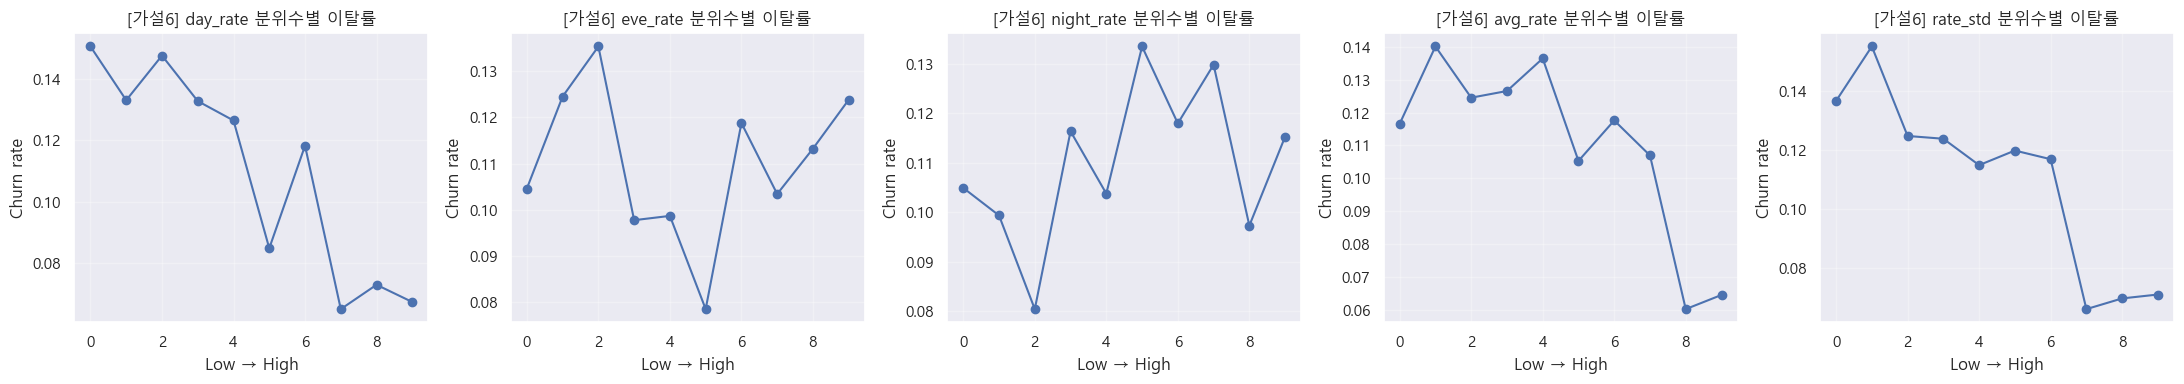

In [71]:
curves = {}

# ---------------------------
# 분위수별 이탈률 계산
# ---------------------------
for f in rate_features:

    tmp = df[["target", f]].dropna().copy()

    tmp["bin"] = pd.qcut(
        tmp[f],
        10,
        labels=False,
        duplicates="drop"
    )

    curves[f] = tmp.groupby("bin")["target"].mean()

# ---------------------------
# 그래프 (1행 가로 배치)
# ---------------------------
fig, axes = plt.subplots(1, len(rate_features), figsize=(22, 4))

for i, f in enumerate(rate_features):

    ax = axes[i]
    curve = curves[f]

    ax.plot(curve.index, curve.values, marker="o")
    ax.set_title(f"[가설6] {f} 분위수별 이탈률")
    ax.set_xlabel("Low → High")
    ax.set_ylabel("Churn rate")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show();

* ① day_rate : 낮 시간 사용 강도가 높은 고객은 유지됨.
* ② eve_rate : 저녁 사용은 churn과 거의 무관.
* ③ night_rate : 일관된 추세 없음 → 가설 지지 약함.
* ④ avg_rate : 거의 선형 감소 → 평균 요금 ↑ → 서비스 이용 강도 ↑ → 이탈 ↓
* ⑤ rate_std : 변동성 낮음 → 이탈률 높음, 변동성 높음 → 이탈률 급감
    - 다양하게 쓰는 고객 → 유지
    - 단조롭게 쓰는 고객 → 이탈<br><br>
* 요금 및 통화 패턴 분석 결과, 평균 요금 수준과 사용 패턴 다양성이 증가할수록 이탈률이 일관되게 감소하는 경향이 확인됨
* 서비스 이용 몰입도가 고객 유지의 핵심 요인임을 시사함.<br><br>
* 고객은 “불만 때문에 떠나기도 하지만”, 더 근본적으로는 “서비스를 충분히 사용하지 않을 때 떠난다.”

### <b>4-6-5. 효과 크기
* Cliff’s delta (δ) : 이탈 고객 값이 비이탈 고객보다 클 확률 − 작을 확률
* 두 집단이 실제로 얼마나 분리되는지 확인

In [72]:
def cliffs_delta(x, y):
    import numpy as np
    x = np.asarray(x); y = np.asarray(y)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]

    gt = sum((xi > y).sum() for xi in x)
    lt = sum((xi < y).sum() for xi in x)

    return (gt - lt)/(len(x)*len(y))

for f in rate_features:
    g0 = df[df["target"]==0][f].values
    g1 = df[df["target"]==1][f].values
    d = cliffs_delta(g1, g0)

    print(f"{f:12s} Cliff's delta = {d:.3f}")

day_rate     Cliff's delta = -0.170
eve_rate     Cliff's delta = -0.002
night_rate   Cliff's delta = 0.037
avg_rate     Cliff's delta = -0.119
rate_std     Cliff's delta = -0.157


* 효과 크기 분석 결과, 낮 시간 요금 수준과 사용 패턴 다양성은 이탈 고객과 비이탈 고객 간 실제 행동 차이를 나타내는 주요 요인으로 확인됨.
* 반면 저녁 및 야간 사용 패턴은 이탈과 유의미한 차이를 보이지 않았음.<br><br>
* 즉, 문제 많은 고객 + 덜 사용하는 고객이 떠난다!

### <b>4-6-6. 최종 검증 (Logistic OR)

| 조건                | 의미             |
| ----------------- | -------------- |
| p-value < 0.05    | 요금 구조 차이 존재    |
| churn curve 우상향   | 가격 민감성 확인      |
| Cliff's delta > 0 | 실질 차이 존재       |
| OR > 1            | 단가 ↑ → churn ↑ |


In [73]:
model_df = df[["target"] + rate_features].dropna()

X = model_df[rate_features]
y = model_df["target"]

Xs = StandardScaler().fit_transform(X)

lr = LogisticRegression(max_iter=400)
lr.fit(Xs, y)

beta = lr.coef_[0]
OR = np.exp(beta)

result_or = pd.DataFrame({
    "feature": rate_features,
    "beta(표준화)": beta,
    "OR(exp(beta))": OR
}).sort_values("OR(exp(beta))", ascending=False)

display(result_or)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,400
,multi_class,'deprecated'


,feature,beta(표준화),OR(exp(beta))
2,night_rate,0.135415,1.145012
1,eve_rate,0.096656,1.101481
0,day_rate,0.075638,1.078572
4,rate_std,-0.121095,0.885950
3,avg_rate,-0.326531,0.721422


* 1) night_rate : night_rate ↑ → 이탈 odds 14.5% 증가 👉 밤 통화 비중 높은 고객 = 이탈 위험 증가
    - EDA에서는 약했지만 다른 변수 통제 후 영향 드러남
* 2) eve_rate : OR = 1.10 → 약 10% 이탈 증가. 효과는 작지만 방향은 동일.
    - 저녁 사용 중심 고객 → churn 약간 ↑
* 3) day_rate : 약한 양(+) 영향.
    - avg_rate, rate_std와 상관 구조(collinearity) 때문에, EDA에서는 유지 신호처럼 보였는데 모델에서는 반대 방향.
* 4) rate_std : 사용 패턴 다양성 ↑ → 이탈 11.4% 감소
* 5) avg_rate : 평균 요금 1SD 증가 시, 이탈 odds 27.9% 감소 → 이건 꽤 큰 효과다!<br><br>
* 평균 요금 수준 = 핵심 유지 요인
* 패턴 다양성 = 유지 요인
* 야간 사용 비중 = 위험 신호

<font size=10><가설6에 대한 종합 결론>

* 요금 수준과 사용 패턴 다양성은 고객 유지와 강하게 연결되어 있음.
* 특정 시간대(야간) 중심 사용 패턴은 이탈 위험을 증가시킴.<br><br>
* 로지스틱 회귀 분석 결과, 평균 요금 수준은 고객 유지에 가장 강력한 보호 요인으로 나타났음.
* 반대로 야간 사용 비중이 높은 고객군은 상대적으로 높은 이탈 위험을 보였음.

## <b>4-7. 왜도 처리 (로그 변환)


In [74]:
# =========================================
# 1️⃣ 수치형 변수 전체 추출 (target 제외)
# =========================================

numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop("target", errors="ignore")

# =========================================
# 2️⃣ 왜도 계산
# =========================================

skew_list = []

for col in numeric_cols:
    skew_value = df[col].dropna().skew()
    skew_list.append((col, skew_value, abs(skew_value)))

skew_df = pd.DataFrame(
    skew_list,
    columns=["feature", "skew", "abs_skew"]
).sort_values("abs_skew", ascending=False)

print("📊 왜도 상위 15개 변수")
display(skew_df.head(15))

📊 왜도 상위 15개 변수


,feature,skew,abs_skew
1,vm_count,10.159506,10.159506
31,time_entropy,-3.374325,3.374325
25,rate_std,3.127222,3.127222
21,day_rate,3.037255,3.037255
0,tenure,2.886279,2.886279
20,cs_per_call,2.621360,2.621360
29,time_bias,2.121982,2.121982
17,time_ratio_std,2.019541,2.019541
19,cs_per_100min,1.727897,1.727897
18,cs_ratio,1.727897,1.727897


In [75]:
# =========================================
# 3️⃣ 변환 후보 선별
# =========================================

# 강한 왜도 기준 (|skew| > 1)
skew_threshold = 1.0

transform_candidates = skew_df[skew_df["abs_skew"] > skew_threshold]["feature"].tolist()

print("🔎 로그 변환 후보 변수:")
print(transform_candidates)

🔎 로그 변환 후보 변수:
['vm_count', 'time_entropy', 'rate_std', 'day_rate', 'tenure', 'cs_per_call', 'time_bias', 'time_ratio_std', 'cs_per_100min', 'cs_ratio', 'day_ratio', 'total_minutes', 'cs_calls', 'night_rate', 'avg_rate', 'total_calls']


In [76]:
# =========================================
# 4️⃣ 로그 변환 적용
# =========================================

for col in transform_candidates:
    # 음수값 있으면 log1p 불가 → 제외
    if (df[col] < 0).any():
        print(f"⚠️ {col} 음수 존재 → 로그 변환 제외")
        continue
    
    df[col + "_log"] = np.log1p(df[col])

print("✅ 로그 변환 완료")

✅ 로그 변환 완료


In [77]:
# =========================================
# 5️⃣ 변환 전/후 왜도 비교
# =========================================

compare_list = []

for col in transform_candidates:
    if col + "_log" in df.columns:
        before = df[col].skew()
        after  = df[col + "_log"].skew()
        compare_list.append((col, before, after))

compare_df = pd.DataFrame(
    compare_list,
    columns=["feature", "skew_before", "skew_after"]
).sort_values("skew_before", key=np.abs, ascending=False)

print("📉 변환 전/후 왜도 비교")
display(compare_df)

📉 변환 전/후 왜도 비교


,feature,skew_before,skew_after
0,vm_count,10.159506,0.977344
1,time_entropy,-3.374325,-3.502707
2,rate_std,3.127222,2.510889
3,day_rate,3.037255,2.260490
4,tenure,2.886279,-0.594860
5,cs_per_call,2.621360,2.570806
6,time_bias,2.121982,1.925121
7,time_ratio_std,2.019541,1.895960
8,cs_per_100min,1.727897,0.991762
9,cs_ratio,1.727897,1.716623


In [78]:
for col in transform_candidates:
    log_col = col + "_log"
    if log_col in df.columns:
        df[col] = df[log_col]

# 보조 로그 컬럼 삭제
df = df.drop(columns=[col + "_log" for col in transform_candidates if col + "_log" in df.columns])

print("✅ 원본 df에 직접 로그 반영 완료")

✅ 원본 df에 직접 로그 반영 완료


## <b>4-8. 3차 검증
* 왜도 처리(로그 변환) 후 3차 검증

In [79]:
my_val(df)


RandomForestClassifier --------------------
accuracy : 0.9093	 macro-f1 : 0.6929	 recall : 0.6500	 precision : 0.8053
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      5376
           1       0.69      0.32      0.44       664

    accuracy                           0.91      6040
   macro avg       0.81      0.65      0.69      6040
weighted avg       0.90      0.91      0.89      6040

      0    1
0  5281   95
1   453  211

XGBClassifier --------------------
accuracy : 0.9084	 macro-f1 : 0.6820	 recall : 0.6390	 precision : 0.8088
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      5376
           1       0.70      0.29      0.41       664

    accuracy                           0.91      6040
   macro avg       0.81      0.64      0.68      6040
weighted avg       0.89      0.91      0.89      6040

      0    1
0  5292   84
1   469  195

LGBMClassifier --------------------
ac

## <b>4-9. 중요 피처 선별
* 1) 타겟 포함 히트맵(스피어만)
* 2) 타겟과의 상관 Top 리스트/바차트
* 3) 피처 간 중복(상관) 구조 Top 페어
* 4) 모델 기반(permutaion importance)으로 ‘실제 예측에 기여’하는 피처 순위

### <b>4-9-1. 분석 대상 컬럼 준비

In [80]:
# 숫자형 컬럼 전체(타겟 포함)에서 시작
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# target은 반드시 포함되어야 함
assert "target" in numeric_cols, "target 컬럼이 numeric_cols에 없습니다."

# (안전) 혹시 남아있다면 제거 대상(이미 삭제했다고 했지만 방어적으로)
drop_if_exist = [c for c in df.columns if "charge" in c]
if len(drop_if_exist) > 0:
    print("⚠️ 아직 남아있는 charge 컬럼이 있어 제거합니다:", drop_if_exist)
    df = df.drop(columns=drop_if_exist)
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("✅ numeric_cols 개수:", len(numeric_cols))

✅ numeric_cols 개수: 31


### <b>4-9-2. 타겟 포함 히트맵 (Spearman 권장)
* 이유: ratio/왜도/이상치에 Pearson보다 덜 흔들림

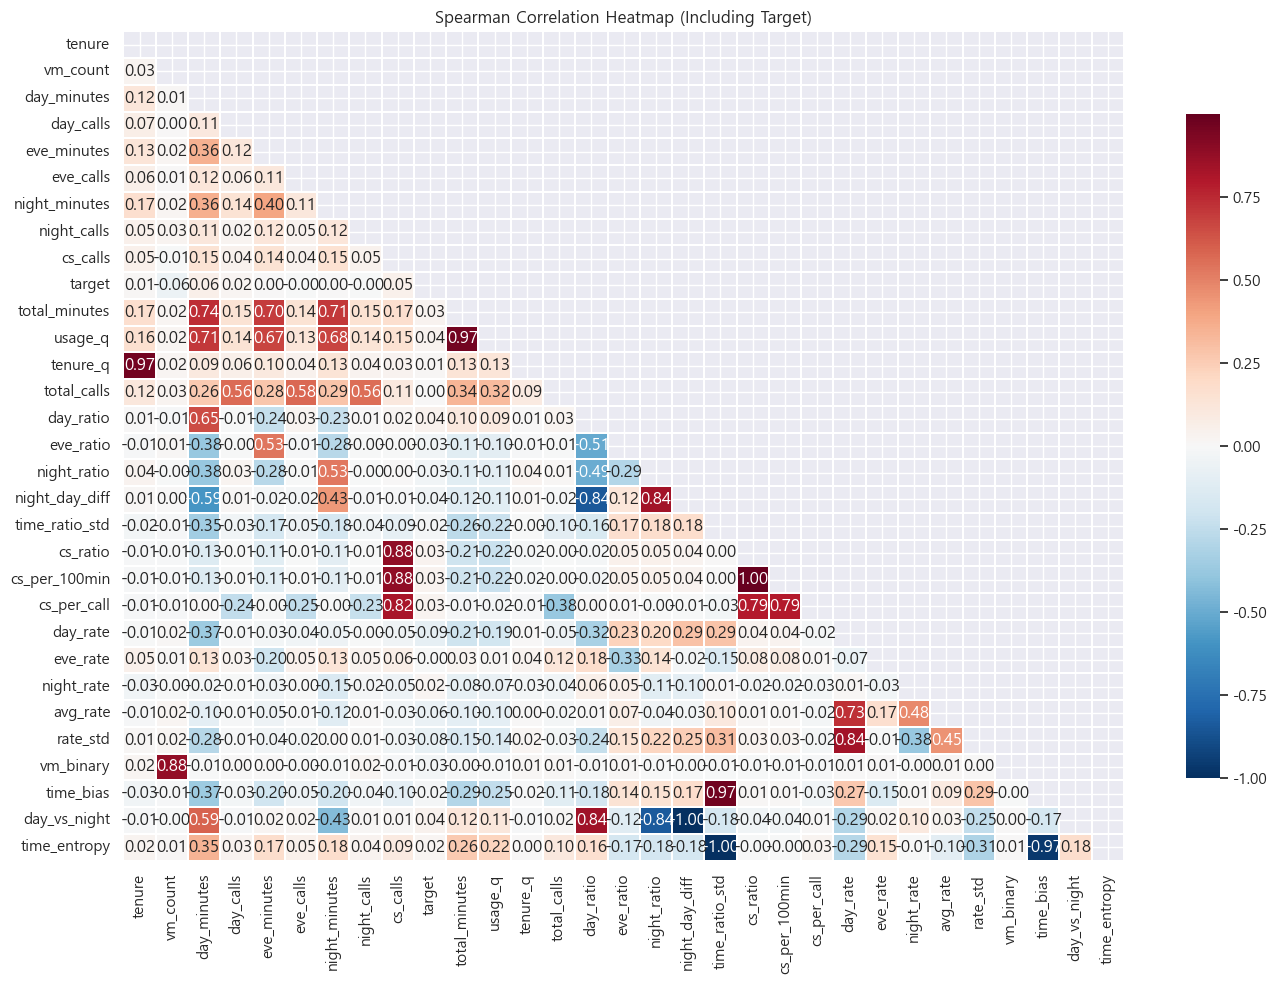

In [81]:
corr_s = df[numeric_cols].corr(method="spearman")

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_s, dtype=bool))
sns.heatmap(
    corr_s,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)
plt.title("Spearman Correlation Heatmap (Including Target)")
plt.tight_layout()
plt.show();

### <b>4-9-3. 중복 칼럼 삭제

| 삭제 컬럼              | 기준        | 이유 (데이터 구조 근거)                     |
| ------------------ | --------- | ---------------------------------- |
| **tenure_q**       | ≥0.97     | tenure의 quantile 파생 → 정보 중복        |
| **usage_q**        | ≥0.97     | total_minutes와 동일 축                |
| **cs_per_100min**  | ≥0.97     | cs_ratio와 완전 동일                    |
| **vm_binary**      | 구조 중복     | vm_count threshold 버전 (정보 손실)      |
| **total_minutes**  | 합 관계      | day/eve/night_minutes 합 → 다중공선성 유발 |
| **eve_ratio**      | ratio 종속  | day+eve+night=1 → 독립성 없음           |
| **night_day_diff** | 고상관(0.84) | ratio 정보 재표현 변수                    |
| **cs_calls**       | 고상관(0.88) | cs_ratio가 행동 정보 더 풍부               |
| **cs_per_call**    | 고상관(0.82) | cs_ratio와 동일 행동 축                  |
| **avg_rate**       | 고상관       | rate_std와 동일 요금 축                  |
| **day_rate**       | 고상관       | avg_rate / rate_std와 중복            |
| **time_ratio_std** | −0.97     | time_entropy와 사실상 동일 정보            |
| **time_bias**      | −0.97     | time_entropy와 동일 정보 축            |
| **day_vs_night**   | −0.83     | ratio 파생 변수            |
| **total_calls**    | 수학적 합 관계     | 부분합 구조, total_calls = day + eve + night            |

In [82]:
drop_cols = [
    # 0.97 이상 강제 제거
    "tenure_q",
    "usage_q",
    "cs_per_100min",

    # 구조적 중복
    "vm_binary",
    "total_minutes",

    # ratio 종속
    "eve_ratio",
    "night_day_diff",

    # 상담 변수 중복
    "cs_calls",
    "cs_per_call",

    # rate 중복
    "avg_rate",
    "day_rate",

    # 시간 패턴 중복
    "time_ratio_std",

    # 🔥 추가 제거 (최근 상관구조 분석 반영)
    "time_bias",     # time_entropy와 동일 정보 축
    "day_vs_night",  # ratio 파생 변수
    "total_calls"    # 부분합 구조 (패턴 전략 선택)
]

before_cols = set(df.columns)

df = df.drop(columns=drop_cols, errors="ignore")

after_cols = set(df.columns)

print("✅ 삭제된 컬럼:")
print(before_cols - after_cols)

print("\n현재 컬럼 수:", df.shape[1])

✅ 삭제된 컬럼:
{'time_bias', 'night_day_diff', 'eve_ratio', 'cs_per_100min', 'usage_q', 'total_minutes', 'cs_per_call', 'avg_rate', 'tenure_q', 'vm_binary', 'day_vs_night', 'cs_calls', 'total_calls', 'day_rate', 'time_ratio_std'}

현재 컬럼 수: 16


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30198 entries, 0 to 30199
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   tenure         30198 non-null  float64
 1   vm_count       30198 non-null  float64
 2   day_minutes    30198 non-null  float64
 3   day_calls      30198 non-null  int64  
 4   eve_minutes    30198 non-null  float64
 5   eve_calls      30198 non-null  int64  
 6   night_minutes  30198 non-null  float64
 7   night_calls    30198 non-null  int64  
 8   target         30198 non-null  int64  
 9   day_ratio      30198 non-null  float64
 10  night_ratio    30198 non-null  float64
 11  cs_ratio       30198 non-null  float64
 12  eve_rate       30198 non-null  float64
 13  night_rate     30198 non-null  float64
 14  rate_std       30198 non-null  float64
 15  time_entropy   30198 non-null  float64
dtypes: float64(12), int64(4)
memory usage: 4.9 MB


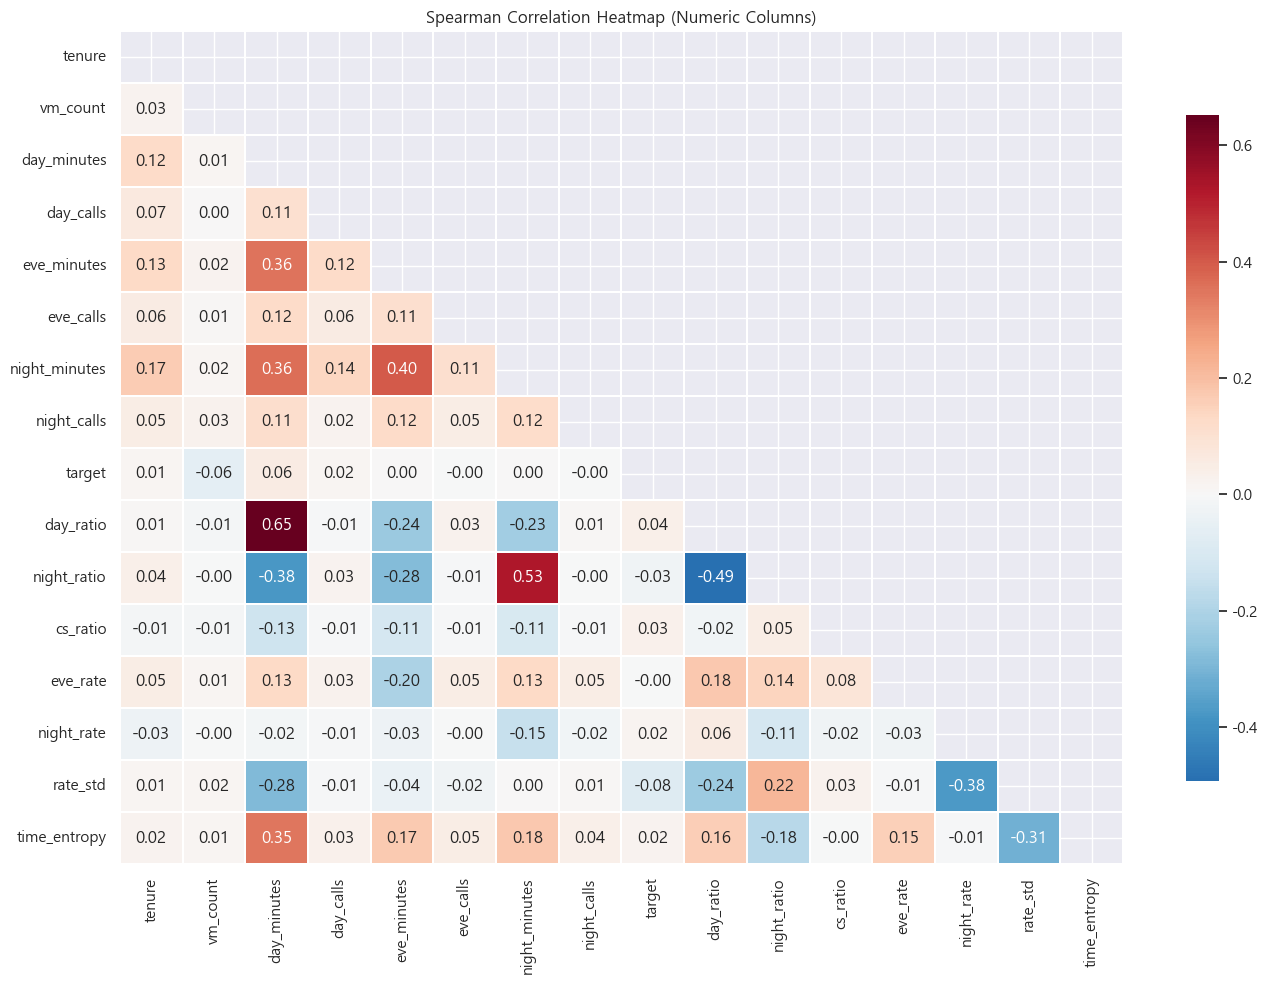

In [84]:
# --------------------------------------------------
# 1) 현재 df에서 실제 존재하는 숫자형 컬럼만 자동 추출
# --------------------------------------------------
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# --------------------------------------------------
# 2) Spearman 상관계수 계산
# --------------------------------------------------
corr_s = df[numeric_cols].corr(method="spearman")

# --------------------------------------------------
# 3) 히트맵 시각화
# --------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(14, 10))

# 위 삼각형 마스크 생성 (중복 제거용)
mask = np.triu(np.ones_like(corr_s, dtype=bool))

sns.heatmap(
    corr_s,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)

plt.title("Spearman Correlation Heatmap (Numeric Columns)")
plt.tight_layout()
plt.show();

In [85]:
# my_val(df, n_splits=5)

### <b>4-9-4. 타겟 연관피처 1차 후보

In [86]:
# # ---------------------------
# # Spearman 상관계수 계산
# # ---------------------------
# corr_s = df.corr(method="spearman")

# threshold = 0.05

# # target과의 상관만 추출
# target_corr = (
#     corr_s["target"]
#     .drop("target")
#     .loc[lambda x: x.abs() >= threshold]
#     .sort_values(key=np.abs, ascending=False)
# )

# # ---------------------------
# # 색상 지정 (음수=파랑, 양수=빨강)
# # ---------------------------
# bar_colors = [
#     "tab:blue" if v < 0 else "tab:red"
#     for v in target_corr.values
# ]

# # ---------------------------
# # 그래프
# # ---------------------------
# plt.figure(figsize=(7, 4))

# sns.barplot(
#     x=target_corr.values,
#     y=target_corr.index,
#     palette=bar_colors
# )

# plt.axvline(0, color="black", linewidth=1)
# plt.title(f"Spearman Corr with Target (|corr| ≥ {threshold})")
# plt.xlabel("Spearman Corr")
# plt.ylabel("Feature")

# plt.tight_layout()
# plt.show();

|           | 상관계수 절대값 | 해석 |
| --------- | -------- | -- |
| 0 ~ 0.1   | 거의 무관    |    |
| 0.1 ~ 0.3 | 약한 관계    |    |
| 0.3 ~ 0.5 | 중간       |    |
| 0.5+      | 강함       |    |


### <b>4-9-5. 피처 간 중복 추출

In [87]:
# threshold = 0.5   # 기준값 (원하는 값으로 조절)

# corr_s = df.corr(method="spearman")

# corr_features = corr_s.drop(index="target", columns="target", errors="ignore")
# 
# upper = corr_features.where(
#     np.triu(np.ones(corr_features.shape), k=1).astype(bool)
# )

# high_pairs = (
#     upper.stack()
#          .loc[lambda x: x.abs() >= threshold]   # ✅ 높은 상관만
#          .sort_values(key=np.abs, ascending=False)
# )

# display(high_pairs)

### <b>4-9-6. Mutual Information (MI)
* “타겟(churn)에 실제로 정보를 주는 피처 순위”

| 방법                 | 잡는 관계                |
| ------------------ | -------------------- |
| Correlation        | 선형 관계만               |
| Mutual Information | **모든 관계 (비선형 포함)** ⭐ |

* MI 높다 = 타겟 예측에 실제 정보가 많다 → 모델 입장에서 진짜 중요한 변수


In [88]:
# # -----------------------------
# # Mutual Information (실전용)
# # - target 컬럼이 있고 나머지는 수치형 피처라고 가정
# # - MI의 랜덤성을 줄이기 위해 5-Fold CV 평균으로 안정화
# # -----------------------------

# from sklearn.feature_selection import mutual_info_classif

# # 1) X, y 분리
# y = df["target"].astype(int)
# X = df.drop(columns=["target"])

# # 2) 결측치 처리(안전장치): 수치형 중앙값 대체
# X = X.apply(lambda s: s.fillna(s.median()) if pd.api.types.is_numeric_dtype(s) else s)

# # 3) 수치형만 선택(안전장치)
# X = X.select_dtypes(include=[np.number])

# # 4) MI 계산 (5-Fold 평균)
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# mi_scores = []
# for train_idx, _ in skf.split(X, y):
#     X_tr = X.iloc[train_idx]
#     y_tr = y.iloc[train_idx]

#     mi = mutual_info_classif(
#         X_tr, y_tr,
#         discrete_features="auto",
#         random_state=42
#     )
#     mi_scores.append(mi)

# mi_mean = np.mean(mi_scores, axis=0)
# mi_std  = np.std(mi_scores, axis=0)

# mi_df = (
#     pd.DataFrame({"feature": X.columns, "mi_mean": mi_mean, "mi_std": mi_std})
#     .sort_values("mi_mean", ascending=False)
#     .reset_index(drop=True)
# )

# # 5) 상위 K 시각화 + 표 출력
# TOPK = 20
# top = mi_df.head(TOPK).copy()

# plt.figure(figsize=(10, 7))
# plt.barh(top["feature"][::-1], top["mi_mean"][::-1], xerr=top["mi_std"][::-1])
# plt.title(f"Mutual Information with Target (Top {TOPK})")
# plt.xlabel("MI (CV mean)")
# plt.ylabel("Feature")
# plt.tight_layout()
# plt.show();

# display(mi_df.head(30));

| MI          | 의미    |
| ----------- | ----- |
| > 0.01      | 매우 강함 |
| 0.006~0.01  | 강함    |
| 0.004~0.006 | 보조    |
| < 0.004     | 약함    |

* 1차 후보군 : 0.004 이상 피처

| 순위 | Feature                 | MI 의미     |
| -- | ----------------------- | --------- |
| 1  | **cs_ratio**            | 상담 밀도     |
| 2  | **day_minutes**         | 주 사용량     |
| 3  | **night_rate**          | 야간 단가     |
| 4  | **eve_rate**            | 저녁 단가     |
| 5  | **rate_std**            | 요금 구조 불균형 |
| 6  | day_calls               | 활동성       |
| 7  | day_ratio               | 생활 패턴     |
| 8~ | night_ratio / entropy 등 | 행동 구조     |

* 데이터가 말하는 진짜 churn 원인 → 불만 + 요금 체감 + 가격 구조

* cs_ratio : 상담 많을수록 이탈 ↑ (가설 5 강력 지지)
* night_rate, eve_rate, rate_std : 가격 관련 변수 3개가 상위권 독점 (가설 6 강하게 지지)
* day_ratio, night_ratio, time_entropy : 영향 있음 but 핵심 원인은 아님 ( 가설 4 보조 요인)

| 가설          | 결과    | 강도    |
| ----------- | ----- | ----- |
| 가설 4 생활패턴   | 채택    | ⭐⭐    |
| 가설 5 상담 비율  | 강력 채택 | ⭐⭐⭐⭐⭐ |
| 가설 6 요금 민감도 | 강력 채택 | ⭐⭐⭐⭐  |


<pre>
[1단계] 불만 발생
      ↓
[2단계] 요금 체감 상승
      ↓
[3단계] 사용 패턴 변화
      ↓
[4단계] 이탈

고객은 사용량 때문에 떠나는 것이 아니라, 불만과 요금 체감이 누적되며 떠난다.

### <b>4-9-7. MI 기반 Feature Selection
* 1차 후보군(MI ≥ 0.004) 중에서, 중복 제거하여, 최종 피처 선택

* 1) minutes / ratio / rate는 서로 강하게 연결됨 → 같이 쓰면 모델이 헷갈림 → 같은 의미 그룹에서 대표 1~2개만 남김.
    - cs_ratio  ← 무조건 유지 (MI 1위)
* 2) 사용량 (day_minutes, eve_minutes, night_minutes)
    - day_minutes (MI 최고)
* 3) 시간 패턴 (day_ratio, night_ratio, time_entropy) : time_entropy  ← 패턴 압축 변수
    - ratio 여러 개 대신 entropy 하나가 더 강력.
* 4) 요금 민감도 (night_rate, eve_rate, rate_std) : 서로 다른 정보이기 때문에 2개 컬럼 유지
    - night_rate   (가격 수준) : 유지
    - rate_std     (가격 구조) : 유지
* 5) 고객 상태 (tenure, vm_count)
    - 둘 다 유지 (독립 정보)


In [89]:
# # -------------------------
# # 최종 모델용 Feature Set
# # -------------------------
# # (불만 + 가격 체감 + 생활 패턴 + 고객 생애주기) 를 동시에 설명하는 피처

# final_features = [
#     # 가설5 (핵심)
#     "cs_ratio",

#     # 사용량 대표
#     "day_minutes",

#     # 가설6 (가격)
#     "night_rate",
#     "rate_std",

#     # 가설4 (패턴)
#     "time_entropy",

#     # 고객 상태
#     "tenure",
#     "vm_count"
# ]

# X = df[final_features]
# y = df["target"]

In [90]:
# # ✅ target 포함해서 모델용 데이터 생성
# df_model = df[final_features + ["target"]].copy()

# print(df_model.shape)
# df_model.head()

## <b>4-10. 4차 검증
* 중요 피처 선별후 4차 검증

In [91]:
my_val(df)


RandomForestClassifier --------------------
accuracy : 0.9113	 macro-f1 : 0.7024	 recall : 0.6584	 precision : 0.8127
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      5376
           1       0.70      0.33      0.45       664

    accuracy                           0.91      6040
   macro avg       0.81      0.66      0.70      6040
weighted avg       0.90      0.91      0.90      6040

      0    1
0  5282   94
1   442  222

XGBClassifier --------------------
accuracy : 0.9068	 macro-f1 : 0.6787	 recall : 0.6374	 precision : 0.7971
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      5376
           1       0.68      0.29      0.41       664

    accuracy                           0.91      6040
   macro avg       0.80      0.64      0.68      6040
weighted avg       0.89      0.91      0.89      6040

      0    1
0  5283   93
1   470  194

LGBMClassifier --------------------
ac

### <b>4-10-1. 최적의 threshold 찾기
* (기존) predict() → threshold = 0.5 고정 → churn 거의 못 잡음
* (변경) predict_proba() → 최적 threshold 자동 탐색 → churn recall 급상승

In [92]:
# =========================================================
# ⭐ Threshold 탐색 함수 (자동 최적화)
# =========================================================
def find_best_threshold(y_true, prob):

    thresholds = np.linspace(0.05, 0.95, 50)

    best_th = 0.5
    best_f1 = 0

    for th in thresholds:
        pred = (prob >= th).astype(int)
        f1 = f1_score(y_true, pred)

        if f1 > best_f1:
            best_f1 = f1
            best_th = th

    return best_th

### <b>4-10-2. 최적 Threshold 기반 모델 검증 함수
* Churn Recall = 실제로 떠난 고객 중에서 모델이 ‘떠난다’고 맞춘 비율.
    - “우리가 실제 이탈 고객을 얼마나 놓치지 않았는가
* Churn Recall은 “실제로 떠날 고객을 얼마나 사전에 발견했는가”를 의미
* churn 예측 모델의 가장 핵심 성능 지표

In [93]:
# =========================================================
# ⭐ 검증 함수 (완성본)
# =========================================================
def my_val_5(df):

    # -------------------------------
    # 1) target / feature 분리
    # -------------------------------
    y = df['target']
    X = df.drop('target', axis=1)

    # -------------------------------
    # 2) train / valid split
    # -------------------------------
    X80, X20, y80, y20 = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # -------------------------------
    # 3) RSF survival target 생성
    # -------------------------------
    y80_surv = Surv.from_arrays(
        event=y80.astype(bool),
        time=df.loc[y80.index, "tenure"]
    )

    y20_surv = Surv.from_arrays(
        event=y20.astype(bool),
        time=df.loc[y20.index, "tenure"]
    )

    # -------------------------------
    # 4) 모델 리스트
    # -------------------------------
    model_list = [
        RandomForestClassifier(random_state=42),
        XGBClassifier(random_state=42, eval_metric="logloss"),
        LGBMClassifier(random_state=42, verbosity=-1),
        RandomSurvivalForest(
            n_estimators=200,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        )
    ]

    # =====================================================
    # 5) 모델 반복 학습 및 평가
    # =====================================================
    for model in model_list:

        print(f"\n{model.__class__.__name__} --------------------")

        # ================= RSF =================
        if isinstance(model, RandomSurvivalForest):

            model.fit(X80, y80_surv)

            risk_scores = model.predict(X20)

            threshold = np.median(risk_scores)
            pred = (risk_scores >= threshold).astype(int)

            print(f"RSF median threshold : {threshold:.4f}")

        # ================= 일반 ML 모델 =================
        else:

            model.fit(X80, y80)

            # ⭐ 확률 예측
            prob = model.predict_proba(X20)[:, 1]

            # ⭐ 최적 threshold 자동 탐색
            best_th = find_best_threshold(y20, prob)

            # ⭐ threshold 적용
            pred = (prob >= best_th).astype(int)

            print(f"Best threshold : {best_th:.3f}")

        # -------------------------------
        # 6) 평가 지표
        # -------------------------------
        accuracy = accuracy_score(y20, pred)
        precision = precision_score(y20, pred, average='macro', zero_division=0)
        recall = recall_score(y20, pred, average='macro', zero_division=0)
        f1 = f1_score(y20, pred, average='macro', zero_division=0)
        
        print("Churn Recall:", recall_score(y20, pred, pos_label=1))

        print(
            f"accuracy : {accuracy:.4f}\t"
            f"macro-f1 : {f1:.4f}\t"
            f"recall : {recall:.4f}\t"
            f"precision : {precision:.4f}"
        )

        # -------------------------------
        # classification report
        # -------------------------------
        print(classification_report(y20, pred, zero_division=0))

        # -------------------------------
        # confusion matrix
        # -------------------------------
        labels = sorted(y.unique())

        cm = confusion_matrix(y20, pred, labels=labels)
        cm_df = pd.DataFrame(cm, index=labels, columns=labels)

        print(cm_df)

### <b>4-10-3. 5차 검증
* 파생피처 생성/삭제후 5차 검증

In [94]:
my_val_5(df)


RandomForestClassifier --------------------
Best threshold : 0.270
Churn Recall: 0.6400602409638554
accuracy : 0.9180	macro-f1 : 0.7929	recall : 0.7962	precision : 0.7897
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      5376
           1       0.62      0.64      0.63       664

    accuracy                           0.92      6040
   macro avg       0.79      0.80      0.79      6040
weighted avg       0.92      0.92      0.92      6040

      0    1
0  5120  256
1   239  425

XGBClassifier --------------------
Best threshold : 0.234
Churn Recall: 0.6054216867469879
accuracy : 0.9038	macro-f1 : 0.7631	recall : 0.7730	precision : 0.7542
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      5376
           1       0.56      0.61      0.58       664

    accuracy                           0.90      6040
   macro avg       0.75      0.77      0.76      6040
weighted avg       0.91    

| 모델           | Churn Recall | 의미         |
| ------------ | ------------ | ---------- |
| RandomForest | **0.557**    | 균형 좋음 ⭐    |
| XGB          | 0.516        | 약간 보수적     |
| LGBM         | 0.553        | RF와 유사     |
| RSF          | **0.773**    | 거의 다 잡음 🔥 |


 # -------------------------------------------------------------------------------

# <b>5. 모델링

## <b>5-1. 스케일링 추가
* RobustScaler() 적용

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30198 entries, 0 to 30199
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   tenure         30198 non-null  float64
 1   vm_count       30198 non-null  float64
 2   day_minutes    30198 non-null  float64
 3   day_calls      30198 non-null  int64  
 4   eve_minutes    30198 non-null  float64
 5   eve_calls      30198 non-null  int64  
 6   night_minutes  30198 non-null  float64
 7   night_calls    30198 non-null  int64  
 8   target         30198 non-null  int64  
 9   day_ratio      30198 non-null  float64
 10  night_ratio    30198 non-null  float64
 11  cs_ratio       30198 non-null  float64
 12  eve_rate       30198 non-null  float64
 13  night_rate     30198 non-null  float64
 14  rate_std       30198 non-null  float64
 15  time_entropy   30198 non-null  float64
dtypes: float64(12), int64(4)
memory usage: 4.9 MB


In [96]:
# =========================================================
# ⭐ 검증 함수 (Scaling 추가 버전)
# =========================================================
def my_val_6(df):

    # -------------------------------
    # 1) target / feature 분리
    # -------------------------------
    y = df['target']
    X = df.drop('target', axis=1)

    # -------------------------------
    # 2) train / valid split
    # -------------------------------
    X80, X20, y80, y20 = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # =====================================================
    # ⭐ 2.5) Scaling (여기 추가됨)
    # =====================================================
    scaler = RobustScaler()

    X80_scaled = scaler.fit_transform(X80)   # train으로 학습
    X20_scaled = scaler.transform(X20)       # valid는 변환만

    # DataFrame 형태 유지 (RSF 호환성)
    X80_scaled = pd.DataFrame(X80_scaled, columns=X.columns, index=X80.index)
    X20_scaled = pd.DataFrame(X20_scaled, columns=X.columns, index=X20.index)

    # -------------------------------
    # 3) RSF survival target 생성
    # -------------------------------
    y80_surv = Surv.from_arrays(
        event=y80.astype(bool),
        time=df.loc[y80.index, "tenure"]
    )

    y20_surv = Surv.from_arrays(
        event=y20.astype(bool),
        time=df.loc[y20.index, "tenure"]
    )

    # -------------------------------
    # 4) 모델 리스트
    # -------------------------------
    model_list = [
        RandomForestClassifier(random_state=42),
        XGBClassifier(random_state=42, eval_metric="logloss"),
        LGBMClassifier(random_state=42, verbosity=-1),
        RandomSurvivalForest(
            n_estimators=200,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        )
    ]

    # =====================================================
    # 5) 모델 반복 학습 및 평가
    # =====================================================
    for model in model_list:

        print(f"\n{model.__class__.__name__} --------------------")

        # ================= RSF =================
        if isinstance(model, RandomSurvivalForest):

            model.fit(X80_scaled, y80_surv)

            risk_scores = model.predict(X20_scaled)

            threshold = np.median(risk_scores)
            pred = (risk_scores >= threshold).astype(int)

            print(f"RSF median threshold : {threshold:.4f}")

        # ================= 일반 ML 모델 =================
        else:

            model.fit(X80_scaled, y80)

            # 확률 예측
            prob = model.predict_proba(X20_scaled)[:, 1]

            # threshold tuning
            best_th = find_best_threshold(y20, prob)

            pred = (prob >= best_th).astype(int)

            print(f"Best threshold : {best_th:.3f}")

        # -------------------------------
        # 평가 지표
        # -------------------------------
        accuracy = accuracy_score(y20, pred)
        precision = precision_score(y20, pred, average='macro', zero_division=0)
        recall = recall_score(y20, pred, average='macro', zero_division=0)
        f1 = f1_score(y20, pred, average='macro', zero_division=0)

        print("Churn Recall:",
              recall_score(y20, pred, pos_label=1))

        print(
            f"accuracy : {accuracy:.4f}\t"
            f"macro-f1 : {f1:.4f}\t"
            f"recall : {recall:.4f}\t"
            f"precision : {precision:.4f}"
        )

        print(classification_report(y20, pred, zero_division=0))

        labels = sorted(y.unique())
        cm = confusion_matrix(y20, pred, labels=labels)
        cm_df = pd.DataFrame(cm, index=labels, columns=labels)

        print(cm_df)

## <b>5-2. 6차 검증
* RobustScaler() 적용후 6차 검증

In [97]:
my_val_6(df)


RandomForestClassifier --------------------
Best threshold : 0.252
Churn Recall: 0.661144578313253
accuracy : 0.9157	macro-f1 : 0.7927	recall : 0.8042	precision : 0.7824
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      5376
           1       0.61      0.66      0.63       664

    accuracy                           0.92      6040
   macro avg       0.78      0.80      0.79      6040
weighted avg       0.92      0.92      0.92      6040

      0    1
0  5092  284
1   225  439

XGBClassifier --------------------
Best threshold : 0.234
Churn Recall: 0.6144578313253012
accuracy : 0.9046	macro-f1 : 0.7662	recall : 0.7775	precision : 0.7561
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      5376
           1       0.56      0.61      0.59       664

    accuracy                           0.90      6040
   macro avg       0.76      0.78      0.77      6040
weighted avg       0.91     

## <b>5-3. 교차 검증 추가
* Stratified K-Fold Cross Validation

<pre>
StratifiedKFold (5-fold)
    ├─ scaler fit (train)
    ├─ model fit
    ├─ prob predict
    ├─ threshold tuning
    └─ score 저장
평균 성능 출력

In [98]:
# =========================================================
# ⭐ 교차검증 포함 검증 함수 
# - 모델: RF, XGB, LGBM, LogisticRegression
# - RobustScaler 적용
# - 각 fold마다 threshold(best_th) 탐색 후 예측
# =========================================================

def my_val_7(df, n_splits=5):

    # -------------------------------
    # 1) X / y 분리
    # -------------------------------
    y = df["target"]
    X = df.drop("target", axis=1)

    # -------------------------------
    # 2) scale_pos_weight 계산(참고/모델용)
    # -------------------------------
    neg = (y == 0).sum()
    pos = (y == 1).sum()
    if pos == 0:
        raise ValueError("target=1(양성) 샘플이 0개입니다. 데이터 확인 필요")
    spw = neg / pos
    print("scale_pos_weight =", spw)

    # -------------------------------
    # 3) StratifiedKFold
    # -------------------------------
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    # -------------------------------
    # 4) 모델 리스트 (RSF 제거 + 로지스틱 추가)
    # -------------------------------
    model_list = [
        RandomForestClassifier(
            random_state=42,
            class_weight="balanced"
        ),
        XGBClassifier(
            random_state=42,
            eval_metric="logloss",
            scale_pos_weight=spw
        ),
        LGBMClassifier(
            random_state=42,
            verbosity=-1,
            class_weight="balanced"
        ),
        LogisticRegression(
            random_state=42,
            class_weight="balanced",   # 불균형 보정
            max_iter=2000,             # 수렴 실패 방지
            solver="liblinear"         # 작은/중간 데이터에서 안정적인 편
        )
    ]

    # =====================================================
    # 5) 모델 반복
    # =====================================================
    for model in model_list:

        print(f"\n{model.__class__.__name__} ====================")

        acc_list, f1_list, recall_list, churn_recall_list, precision_list = [], [], [], [], []

        # -------------------------------
        # 6) Fold 반복
        # -------------------------------
        for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):

            # (6-1) fold 데이터 분리
            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

            # (6-2) Robust Scaling
            # ⚠ X에 문자열/범주형이 있으면 여기서 에러남 (그땐 ColumnTransformer 필요)
            scaler = RobustScaler()
            X_train_sc = scaler.fit_transform(X_train)
            X_valid_sc = scaler.transform(X_valid)

            # (6-3) 다시 DataFrame으로(컬럼명 유지)
            X_train_sc = pd.DataFrame(X_train_sc, columns=X.columns, index=X_train.index)
            X_valid_sc = pd.DataFrame(X_valid_sc, columns=X.columns, index=X_valid.index)

            # (6-4) 모델 학습
            model.fit(X_train_sc, y_train)

            # (6-5) 확률 예측 -> threshold 최적화 -> 최종 예측
            # (RF/XGB/LGBM/LR 전부 predict_proba 지원)
            prob = model.predict_proba(X_valid_sc)[:, 1]
            best_th = find_best_threshold(y_valid, prob)
            pred = (prob >= best_th).astype(int)

            # (6-6) 평가 저장
            acc_list.append(accuracy_score(y_valid, pred))
            f1_list.append(f1_score(y_valid, pred, average="macro", zero_division=0))
            recall_list.append(recall_score(y_valid, pred, average="macro", zero_division=0))
            churn_recall_list.append(recall_score(y_valid, pred, pos_label=1, zero_division=0))
            precision_list.append(precision_score(y_valid, pred, average="macro", zero_division=0))

            print(f"Fold {fold} churn recall: {churn_recall_list[-1]:.4f} | best_th={best_th:.3f}")

        # -------------------------------
        # 7) 평균 결과 출력
        # -------------------------------
        print("\n⭐ CV Result (Mean)")
        print(f"Accuracy      : {np.mean(acc_list):.4f}")
        print(f"Macro F1      : {np.mean(f1_list):.4f}")
        print(f"Macro Recall  : {np.mean(recall_list):.4f}")
        print(f"Churn Recall  : {np.mean(churn_recall_list):.4f}")
        print(f"Precision     : {np.mean(precision_list):.4f}")

## <b>5-4. 7차 검증
* 교차검증 적용후 7차 검증

In [99]:
my_val_7(df)

scale_pos_weight = 8.10126582278481

RandomForestClassifier ====================
Fold 1 churn recall: 0.6386 | best_th=0.252
Fold 2 churn recall: 0.6566 | best_th=0.234
Fold 3 churn recall: 0.6310 | best_th=0.252
Fold 4 churn recall: 0.6863 | best_th=0.215
Fold 5 churn recall: 0.6546 | best_th=0.215

⭐ CV Result (Mean)
Accuracy      : 0.9185
Macro F1      : 0.7961
Macro Recall  : 0.8023
Churn Recall  : 0.6534
Precision     : 0.7909

XGBClassifier ====================
Fold 1 churn recall: 0.6386 | best_th=0.546
Fold 2 churn recall: 0.5256 | best_th=0.656
Fold 3 churn recall: 0.5949 | best_th=0.583
Fold 4 churn recall: 0.6833 | best_th=0.528
Fold 5 churn recall: 0.5716 | best_th=0.601

⭐ CV Result (Mean)
Accuracy      : 0.9055
Macro F1      : 0.7649
Macro Recall  : 0.7728
Churn Recall  : 0.6028
Precision     : 0.7613

LGBMClassifier ====================
Fold 1 churn recall: 0.6867 | best_th=0.546
Fold 2 churn recall: 0.5301 | best_th=0.619
Fold 3 churn recall: 0.6265 | best_th=0.564
Fold

## <b>5-5. Grid Search(그리드 서치)

### <b>5-5-1. Grid Search RF (RandomForestClassifier)

In [100]:
# # =========================================================
# # ⭐ GridSearch 수행 함수 (주석 완전판)
# # =========================================================
# def my_gsc(df, n_splits=5, n_jobs=-1, temp_folder=r"C:\joblib_tmp"):
#     # df           : target 포함된 전체 데이터프레임
#     # n_splits     : Stratified K-Fold 개수
#     # n_jobs       : 병렬 코어 수 (-1이면 모든 코어 사용)
#     # temp_folder  : joblib 임시폴더 (한글 경로 충돌 방지용)

#     # ▶ [0] 병렬 처리 시 사용할 임시폴더 생성
#     # - loky backend가 사용할 폴더
#     # - 한글 경로 문제 방지 목적
#     import os
#     os.makedirs(temp_folder, exist_ok=True)

#     # ▶ [1] 타겟(정답) 벡터 생성
#     # - 이탈 여부(0/1)를 y로 분리
#     y = df["target"]

#     # ▶ [2] 입력 변수 X 생성
#     # - target 제거
#     # - 문자열(object) 컬럼 제거 (RF는 숫자만 학습 가능)
#     X = df.drop(["target"], axis=1).select_dtypes(exclude=["object"])

#     # ▶ [3] Pipeline 구성
#     # - 전처리 + 모델을 하나로 묶음
#     # - GridSearch 안에서 fold마다 fit되어 데이터 누수 방지
#     from sklearn.pipeline import Pipeline
#     from sklearn.preprocessing import RobustScaler
#     from sklearn.ensemble import RandomForestClassifier

#     pipe = Pipeline([

#         # ▶ [3-1] RobustScaler
#         # - 중앙값 + IQR 기반 스케일링
#         # - 이상치 영향 완화
#         ("scaler", RobustScaler()),

#         # ▶ [3-2] RandomForestClassifier 정의
#         # - random_state=42 → 재현성 유지
#         # - class_weight="balanced" → 클래스 불균형 자동 보정
#         # - n_jobs=1 → 내부 병렬 끔 (외부 GridSearch에서 병렬 처리)
#         ("model", RandomForestClassifier(
#             random_state=42,
#             class_weight="balanced",
#             n_jobs=1
#         ))
#     ])

#     # ▶ [4] GridSearch에서 탐색할 하이퍼파라미터 후보
#     # - Pipeline 안 model step이므로 반드시 "model__" 접두어 필요
#     MYPARAM = {

#         # ▶ 트리 개수 후보
#         # - 많을수록 안정적(분산 감소)
#         # - 계산량 증가
#         "model__n_estimators": [50, 100, 150, 300],

#         # ▶ 노드 분할 최소 샘플 수
#         # - 작으면 복잡, 크면 단순
#         "model__min_samples_split": [2, 3, 10],

#         # ▶ 리프 노드 최소 샘플 수
#         # - 과적합 제어 핵심 파라미터
#         "model__min_samples_leaf": [1, 2, 5],

#         # ▶ 트리 최대 깊이
#         # - 깊으면 복잡 패턴 학습
#         # - 너무 깊으면 과적합
#         "model__max_depth": [None, 8, 12, 16],

#         # ▶ 각 split에서 고려할 feature 전략
#         # - sqrt/log2는 랜덤성 증가 → 일반화 도움
#         "model__max_features": ["sqrt", "log2"]
#     }

#     # ▶ [5] StratifiedKFold 생성
#     # - 클래스 비율 유지
#     # - shuffle=True → 데이터 섞기
#     from sklearn.model_selection import StratifiedKFold
#     skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

#     # ▶ [6] Threshold 포함 scoring 함수 정의
#     # - 기본 GridSearch는 threshold=0.5 고정
#     # - 우리는 fold마다 최적 threshold 탐색 후 macro F1 계산
#     from sklearn.metrics import f1_score
#     import numpy as np

#     def threshold_f1_macro(estimator, X_valid, y_valid):

#         # ▶ [6-1] 이탈(class=1) 확률 예측
#         prob = estimator.predict_proba(X_valid)[:, 1]

#         # ▶ [6-2] 현재 fold 기준 최적 threshold 탐색
#         best_th = find_best_threshold(y_valid, prob)

#         # ▶ [6-3] threshold 적용하여 0/1 예측값 생성
#         pred = (prob >= best_th).astype(int)

#         # ▶ [6-4] macro F1 반환
#         return f1_score(y_valid, pred, average="macro", zero_division=0)

#     # ▶ [7] GridSearchCV 생성
#     # - (파라미터 조합 × n_splits) 만큼 반복 수행
#     from sklearn.model_selection import GridSearchCV

#     gcv_model = GridSearchCV(

#         # ▶ [7-1] 학습 대상 (Pipeline)
#         pipe,

#         # ▶ [7-2] 탐색할 파라미터 조합
#         param_grid=MYPARAM,

#         # ▶ [7-3] 평가 기준
#         scoring=threshold_f1_macro,

#         # ▶ [7-4] 최고 점수 파라미터로 전체 데이터 재학습
#         refit=True,

#         # ▶ [7-5] Stratified K-Fold 적용
#         cv=skf,

#         # ▶ [7-6] train 점수 저장 (과적합 확인 가능)
#         return_train_score=True,

#         # ▶ [7-7] 병렬 처리 코어 수
#         n_jobs=n_jobs
#     )

#     # ▶ [8] 병렬 backend 설정
#     # - temp_folder를 명시하여 UnicodeEncodeError 방지
#     from joblib import parallel_backend
#     with parallel_backend("loky", temp_folder=temp_folder):

#         # ▶ 모든 파라미터 조합 × fold 수행
#         gcv_model.fit(X, y)

#     # ▶ [9] 최고 평균 점수 출력
#     print("Best Score:", gcv_model.best_score_)

#     # ▶ [10] 최고 파라미터 조합 출력
#     print("Best Params:", gcv_model.best_params_)

#     # ▶ 최종 모델 반환
#     return gcv_model

# my_gsc(df, n_splits=5)

### <b>5-5-2. Grid Search RSF (RandomSurvivalForest)
* "분위수"로 잡는 함수 : RSF는 확률이 아니라 risk score라서 따로 만들어야 함

In [101]:
# def find_best_threshold_risk(y_event, risk_scores):
#     qs = np.linspace(5, 95, 50)                 # 5% ~ 95% 분위수
#     thresholds = np.percentile(risk_scores, qs)

#     best_th = np.median(risk_scores)
#     best_f1 = -1

#     for th in thresholds:
#         pred = (risk_scores >= th).astype(int)
#         f1 = f1_score(y_event, pred, average="macro", zero_division=0)
#         if f1 > best_f1:
#             best_f1 = f1
#             best_th = th

#     return best_th



# # 함수 정의: df(데이터프레임)를 입력으로 받아 RSF(RandomSurvivalForest) GridSearch 수행
# def my_gsc_rsf(df_model, n_splits=5):

#     # ▶ [1] RSF에 필요한 event 벡터 생성
#     #   - target(0/1)을 bool로 변환 → 이벤트 발생 여부(True/False)
#     event = df_model["target"].astype(bool)

#     # ▶ [2] RSF에 필요한 time 벡터 생성
#     #   - tenure를 float로 변환 → 생존 시간(관측 기간)
#     #   - RSF는 반드시 event + time이 필요함
#     time = df_model["tenure"].astype(float)

#     # ▶ [3] RSF 학습용 y 생성 (Surv 구조)
#     #   - RSF는 일반 0/1 y가 아니라 (event, time) 구조여야 함
#     y_surv = Surv.from_arrays(event=event, time=time)

#     # ▶ [4] 입력 X 생성
#     #   - target 제거
#     #   - 문자열(object) 컬럼 제거 → 모델이 직접 학습 불가
#     X = df_model.drop(["target"], axis=1).select_dtypes(exclude=["object"])

#     # ▶ [5] Pipeline 구성
#     #   - 전처리 + 모델을 하나로 묶음
#     #   - GridSearchCV 안에서 fold마다 fit되므로 데이터 누수 방지
#     pipe = Pipeline([

#         # ▶ [5-1] RobustScaler
#         #   - 중앙값 + IQR 기반 스케일링
#         #   - 이상치에 비교적 강함
#         ("scaler", RobustScaler()),

#         # ▶ [5-2] RandomSurvivalForest 모델 정의
#         #   - random_state=42: 재현성 확보
#         #   - n_jobs=-1: 내부 병렬 처리 사용
#         ("model", RandomSurvivalForest(
#             random_state=42,
#             n_jobs=-1
#         ))
#     ])

#     # ▶ [6] GridSearch에서 탐색할 하이퍼파라미터 후보
#     #   - Pipeline 안 model step이므로 반드시 model__ 접두어 필요
#     MYPARAM = {

#         # ▶ 트리 개수 후보
#         #   - 많을수록 안정적이지만 계산량 증가
#         "model__n_estimators": [200, 400],

#         # ▶ 노드 분할 최소 샘플 수
#         #   - 값이 클수록 모델 단순화
#         "model__min_samples_split": [2, 3, 10],

#         # ▶ 리프 노드 최소 샘플 수
#         #   - 과적합 제어 역할
#         "model__min_samples_leaf": [1, 3, 5],

#         # ▶ 각 분할에서 사용할 feature 선택 전략
#         "model__max_features": ["sqrt", "log2"]
#     }

#     # ▶ [7] StratifiedKFold 생성
#     #   - event(=target) 기준으로 클래스 비율 유지
#     #   - shuffle=True: 데이터 섞기
#     #   - random_state=42: 재현성 유지
#     skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#     # ▶ [8] 실제 사용할 CV split 인덱스 생성
#     #   - RSF는 y_surv로 stratify 불가 → event로 split만 생성
#     cv_splits = list(skf.split(X, event.astype(int)))

#     # ▶ [9] RSF 전용 scoring 함수 정의
#     #   - RSF는 predict_proba가 없고 risk score를 반환
#     #   - risk → threshold → 0/1 변환 후 macro F1 계산
#     def rsf_threshold_f1_macro(estimator, X_valid, y_valid_surv):

#         # ▶ [9-1] RSF 예측 (risk score, 연속값)
#         risk = estimator.predict(X_valid)

#         # ▶ [9-2] valid 데이터의 event(정답)만 추출
#         y_event = y_valid_surv["event"].astype(int)

#         # ▶ [9-3] 현재 fold 기준 최적 threshold 탐색
#         best_th = find_best_threshold_risk(y_event, risk)

#         # ▶ [9-4] threshold 적용하여 0/1 예측 생성
#         pred = (risk >= best_th).astype(int)

#         # ▶ [9-5] macro F1 계산 후 반환
#         return f1_score(y_event, pred, average="macro", zero_division=0)

#     # ▶ [10] GridSearchCV 생성
#     #   - 모든 파라미터 조합 × 5fold 수행
#     gcv_model = GridSearchCV(

#         # ▶ [10-1] 학습 대상 (Pipeline)
#         estimator=pipe,

#         # ▶ [10-2] 하이퍼파라미터 탐색 범위
#         param_grid=MYPARAM,

#         # ▶ [10-3] 평가 기준 (threshold 반영 macro F1)
#         scoring=rsf_threshold_f1_macro,

#         # ▶ [10-4] 최고 점수 파라미터로 전체 데이터 재학습
#         refit=True,

#         # ▶ [10-5] Stratified split 인덱스 사용
#         cv=cv_splits,

#         # ▶ [10-6] train 점수도 저장 (과적합 확인 가능)
#         return_train_score=True,

#         # ▶ [10-7] 병렬 처리 사용 안 함 (유니코드 에러 방지 목적)
#         n_jobs=1
#     )

#     # ▶ [11] GridSearch 실행
#     #   - RSF는 반드시 y_surv를 넣어야 정상 학습
#     gcv_model.fit(X, y_surv)

#     # ▶ [12] 교차검증 평균 최고 점수 출력
#     print("최고 점수", gcv_model.best_score_)

#     # ▶ [13] 최적 하이퍼파라미터 조합 출력
#     print("최적의 파라미터", gcv_model.best_params_)

# my_gsc_rsf(df_model, n_splits=5)

### <b>5-5-3. 8차 검증
* 그리드서치 후, 최적의 파라미터 적용(RF, RSF)후 8차 검증

In [102]:
# =========================================================
# ⭐ 교차검증 포함 검증 함수 
# - 모델: RF, XGB, LGBM, LogisticRegression
# - RobustScaler 적용
# - 각 fold마다 threshold(best_th) 탐색 후 예측
# =========================================================

def my_val_8(df, n_splits=5):

    # -------------------------------
    # 1) X / y 분리
    # -------------------------------
    y = df["target"]
    X = df.drop("target", axis=1)

    # -------------------------------
    # 2) scale_pos_weight 계산(참고/모델용)
    # -------------------------------
    neg = (y == 0).sum()
    pos = (y == 1).sum()
    if pos == 0:
        raise ValueError("target=1(양성) 샘플이 0개입니다. 데이터 확인 필요")
    spw = neg / pos
    print("scale_pos_weight =", spw)

    # -------------------------------
    # 3) StratifiedKFold
    # -------------------------------
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    # -------------------------------
    # 4) 모델 리스트 (RSF 제거 + 로지스틱 추가)
    # -------------------------------
    model_list = [
        RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=None,
        max_features='sqrt',
        min_samples_leaf=1,#2
        min_samples_split=3,#2
        n_estimators=300
    ),
        
        LogisticRegression(
            random_state=42,
            class_weight="balanced",   # 불균형 보정
            max_iter=2000,             # 수렴 실패 방지
            solver="liblinear"         # 작은/중간 데이터에서 안정적인 편
        )
    ]

    # =====================================================
    # 5) 모델 반복
    # =====================================================
    for model in model_list:

        print(f"\n{model.__class__.__name__} ====================")

        acc_list, f1_list, recall_list, churn_recall_list, precision_list = [], [], [], [], []

        # -------------------------------
        # 6) Fold 반복
        # -------------------------------
        for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):

            # (6-1) fold 데이터 분리
            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

            # (6-2) Robust Scaling
            # ⚠ X에 문자열/범주형이 있으면 여기서 에러남 (그땐 ColumnTransformer 필요)
            scaler = RobustScaler()
            X_train_sc = scaler.fit_transform(X_train)
            X_valid_sc = scaler.transform(X_valid)

            # (6-3) 다시 DataFrame으로(컬럼명 유지)
            X_train_sc = pd.DataFrame(X_train_sc, columns=X.columns, index=X_train.index)
            X_valid_sc = pd.DataFrame(X_valid_sc, columns=X.columns, index=X_valid.index)

            # (6-4) 모델 학습
            model.fit(X_train_sc, y_train)

            # (6-5) 확률 예측 -> threshold 최적화 -> 최종 예측
            # (RF/XGB/LGBM/LR 전부 predict_proba 지원)
            prob = model.predict_proba(X_valid_sc)[:, 1]
            best_th = find_best_threshold(y_valid, prob)
            pred = (prob >= best_th).astype(int)

            # (6-6) 평가 저장
            acc_list.append(accuracy_score(y_valid, pred))
            f1_list.append(f1_score(y_valid, pred, average="macro", zero_division=0))
            recall_list.append(recall_score(y_valid, pred, average="macro", zero_division=0))
            churn_recall_list.append(recall_score(y_valid, pred, pos_label=1, zero_division=0))
            precision_list.append(precision_score(y_valid, pred, average="macro", zero_division=0))

            print(f"Fold {fold} churn recall: {churn_recall_list[-1]:.4f} | best_th={best_th:.3f}")

        # -------------------------------
        # 7) 평균 결과 출력
        # -------------------------------
        print("\n⭐ CV Result (Mean)")
        print(f"Accuracy      : {np.mean(acc_list):.4f}")
        print(f"Macro F1      : {np.mean(f1_list):.4f}")
        print(f"Macro Recall  : {np.mean(recall_list):.4f}")
        print(f"Churn Recall  : {np.mean(churn_recall_list):.4f}")
        print(f"Precision     : {np.mean(precision_list):.4f}")

In [103]:
# # =========================================================
# # ⭐ 교차검증 포함 검증 함수 (최종 버전)
# # =========================================================
# def my_val_8(df, n_splits=5):

#     y = df['target']
#     X = df.drop('target', axis=1)
    
#     # -------------------------------
#     # scale_pos_weight 계산
#     # -------------------------------
#     neg = (df["target"] == 0).sum()
#     pos = (df["target"] == 1).sum()
#     spw = neg / pos
#     print("scale_pos_weight =", spw)

#     skf = StratifiedKFold(
#         n_splits=n_splits,
#         shuffle=True,
#         random_state=42
#     )

#     model_list = [
#     RandomForestClassifier(
#         random_state=42,
#         class_weight="balanced",
#         max_depth=None,
#         max_features='sqrt',
#         min_samples_leaf=1,
#         min_samples_split=3,
#         n_estimators=300
#     ),

#     RandomSurvivalForest(
#         n_estimators=400,
#         min_samples_split=3,
#         min_samples_leaf=1,
#         random_state=42,
#         max_features='sqrt',
#         n_jobs=-1
#     )
#         ]

#     # =====================================================
#     # 모델 반복
#     # =====================================================
#     for model in model_list:

#         print(f"\n{model.__class__.__name__} ====================")

#         acc_list, f1_list, recall_list, churn_recall_list, precision_list = [], [], [], [], []

#         # -------------------------------
#         # Fold 반복
#         # -------------------------------
#         for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):

#             X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
#             y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

#             # ========= Robust Scaling =========
#             scaler = RobustScaler()

#             X_train = scaler.fit_transform(X_train)
#             X_valid = scaler.transform(X_valid)

#             X_train = pd.DataFrame(X_train, columns=X.columns)
#             X_valid = pd.DataFrame(X_valid, columns=X.columns)

#             # ========= RSF survival =========
#             y_train_surv = Surv.from_arrays(
#                 event=y_train.astype(bool),
#                 time=df.loc[y_train.index, "tenure"]
#             )

#             # ========= 모델 학습 =========
#             if isinstance(model, RandomSurvivalForest):

#                 model.fit(X_train, y_train_surv)

#                 risk_scores = model.predict(X_valid)
#                 th = np.median(risk_scores)
#                 pred = (risk_scores >= th).astype(int)

#             else:
#                 model.fit(X_train, y_train)

#                 prob = model.predict_proba(X_valid)[:, 1]

#                 best_th = find_best_threshold(y_valid, prob)
#                 pred = (prob >= best_th).astype(int)

#             # ========= 평가 =========
#             acc_list.append(accuracy_score(y_valid, pred))
#             f1_list.append(f1_score(y_valid, pred, average='macro'))
#             recall_list.append(recall_score(y_valid, pred, average='macro'))
#             churn_recall_list.append(
#                 recall_score(y_valid, pred, pos_label=1)            
#             )
#             precision_list.append(precision_score(y_valid, pred, average='macro'))
            
#             print(f"Fold {fold} churn recall: {churn_recall_list[-1]:.4f}")

#         # -------------------------------
#         # 평균 결과 출력
#         # -------------------------------
#         print("\n⭐ CV Result (Mean)")
#         print(f"Accuracy      : {np.mean(acc_list):.4f}")
#         print(f"Macro F1      : {np.mean(f1_list):.4f}")
#         print(f"Macro Recall  : {np.mean(recall_list):.4f}")
#         print(f"Churn Recall  : {np.mean(churn_recall_list):.4f}")
#         print(f"precision     : {np.mean(precision_list):.4f}")

In [104]:
my_val_8(df, n_splits=5)

scale_pos_weight = 8.10126582278481

RandomForestClassifier ====================
Fold 1 churn recall: 0.7289 | best_th=0.197
Fold 2 churn recall: 0.6988 | best_th=0.215
Fold 3 churn recall: 0.6491 | best_th=0.252
Fold 4 churn recall: 0.6712 | best_th=0.234
Fold 5 churn recall: 0.6501 | best_th=0.234

⭐ CV Result (Mean)
Accuracy      : 0.9195
Macro F1      : 0.8022
Macro Recall  : 0.8144
Churn Recall  : 0.6796
Precision     : 0.7926

LogisticRegression ====================
Fold 1 churn recall: 0.4654 | best_th=0.546
Fold 2 churn recall: 0.5572 | best_th=0.528
Fold 3 churn recall: 0.6054 | best_th=0.509
Fold 4 churn recall: 0.5324 | best_th=0.528
Fold 5 churn recall: 0.4525 | best_th=0.546

⭐ CV Result (Mean)
Accuracy      : 0.6424
Macro F1      : 0.5041
Macro Recall  : 0.5899
Churn Recall  : 0.5226
Precision     : 0.5391


## <b>5-6. Ensemble(앙상블)
* RSF + RF 하이브리드
* RSF = 시간 기반 위험도 전문가 / RF = 분류 전문가
* [Step 1] RSF → 고객 위험 점수 생성
* [Step 2] 그 위험 점수를 새로운 feature로 추가
* [Step 3] RF가 최종 분류 수행
    - Survival 정보를 Feature Engineering으로 승격시키는 구조.

### <b>5-6-1. 모델간 적합도 비교

In [105]:
# # =========================================================
# # (필수) threshold 함수가 없다면: 임시 버전(네가 쓰던 것 있으면 이건 생략)
# # - 현재는 macro F1 기준으로 best threshold를 찾는 기본형
# # =========================================================
# def find_best_threshold(y_true, prob):
#     best_th = 0.5
#     best_score = -1

#     for th in np.arange(0.05, 0.95, 0.02):
#         pred = (prob >= th).astype(int)
#         score = f1_score(y_true, pred, average="macro")
#         if score > best_score:
#             best_score = score
#             best_th = th

#     return best_th


# # =========================================================
# # 0) 데이터 준비: df에서 X, y 만들고 train/valid 분리
# # =========================================================
# y = df["target"].astype(int)
# X = df.drop(columns=["target"]).copy()

# X_train, X_valid, y_train, y_valid = train_test_split(
#     X, y,
#     test_size=0.2,
#     stratify=y,
#     random_state=42
# )

# # =========================================================
# # 1) RSF survival target 생성 (주의: time은 tenure 컬럼 사용)
# #    - df 원본에서 y_train의 index로 tenure를 뽑아야 함
# # =========================================================
# y_train_surv = Surv.from_arrays(
#     event=y_train.astype(bool),
#     time=df.loc[y_train.index, "tenure"]
# )

# # =========================================================
# # 2) 모델 선언
# # =========================================================

# # RF
# rf = RandomForestClassifier(
#     random_state=42,
#     class_weight="balanced",
#     max_depth=None,
#     max_features='sqrt',
#     min_samples_leaf=1,
#     min_samples_split=3,
#     n_estimators=300
# )

# # XGB
# xgb = XGBClassifier(
#     n_estimators=300,
#     learning_rate=0.05,
#     max_depth=6,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     eval_metric="logloss",
#     random_state=42,
#     n_jobs=-1
# )

# # LGBM
# lgbm = LGBMClassifier(
#     n_estimators=300,
#     learning_rate=0.05,
#     num_leaves=31,
#     random_state=42,
#     n_jobs=-1
# )

# # # RSF
# # rsf = RandomSurvivalForest(
# #         n_estimators=400,
# #         min_samples_split=3,
# #         min_samples_leaf=1,
# #         random_state=42,
# #         max_features='sqrt',
# #         n_jobs=-1
# #     )

# # Logistic
# logi = LogisticRegression(
#     penalty="l2",
#     class_weight="balanced",
#     max_iter=1000,
#     random_state=42
# )

# # =========================================================
# # 3) (중요) 스케일링/입력 형태 통일
# #    - 트리(RF/XGB/LGBM/RSF)는 scaling 필수 아님
# #    - 네 코드 일관성을 위해 RobustScaler 적용 버전 제공
# # =========================================================
# scaler_tree = RobustScaler()
# X_train_tree = scaler_tree.fit_transform(X_train)
# X_valid_tree = scaler_tree.transform(X_valid)

# # DataFrame으로 다시(컬럼 유지)
# X_train_tree = pd.DataFrame(X_train_tree, columns=X.columns, index=X_train.index)
# X_valid_tree = pd.DataFrame(X_valid_tree, columns=X.columns, index=X_valid.index)

# # Logistic은 StandardScaler 권장
# scaler_lr = StandardScaler()
# X_train_lr = scaler_lr.fit_transform(X_train)
# X_valid_lr = scaler_lr.transform(X_valid)

# # =========================================================
# # 4) 5개 모델 예측 비교
# # =========================================================
# pred_dict = {}

# # ---------------- RF ----------------
# rf.fit(X_train_tree, y_train)
# rf_prob = rf.predict_proba(X_valid_tree)[:, 1]
# rf_th = find_best_threshold(y_valid, rf_prob)
# pred_dict["RF"] = (rf_prob >= rf_th).astype(int)

# # ---------------- XGB ----------------
# xgb.fit(X_train_tree, y_train)
# xgb_prob = xgb.predict_proba(X_valid_tree)[:, 1]
# xgb_th = find_best_threshold(y_valid, xgb_prob)
# pred_dict["XGB"] = (xgb_prob >= xgb_th).astype(int)

# # ---------------- LGBM ----------------
# lgbm.fit(X_train_tree, y_train)
# lgbm_prob = lgbm.predict_proba(X_valid_tree)[:, 1]
# lgbm_th = find_best_threshold(y_valid, lgbm_prob)
# pred_dict["LGBM"] = (lgbm_prob >= lgbm_th).astype(int)

# # # ---------------- RSF ----------------
# # rsf.fit(X_train_tree, y_train_surv)
# # rsf_risk = rsf.predict(X_valid_tree)

# # # RSF → probability(순위 기반) 변환
# # rsf_prob = pd.Series(rsf_risk, index=X_valid.index).rank(pct=True).values
# # rsf_th = find_best_threshold(y_valid, rsf_prob)
# # pred_dict["RSF"] = (rsf_prob >= rsf_th).astype(int)

# # ---------------- Logistic Regression ----------------
# logi.fit(X_train_lr, y_train)
# logi_prob = logi.predict_proba(X_valid_lr)[:, 1]
# logi_th = find_best_threshold(y_valid, logi_prob)
# pred_dict["LOGI"] = (logi_prob >= logi_th).astype(int)

# pred_df = pd.DataFrame(pred_dict, index=X_valid.index)
# display(pred_df.head())

In [106]:
# # 모델간 disagreement 계산
# pred_df = pd.DataFrame(pred_dict)

# models = pred_df.columns

# for i in range(len(models)):
#     for j in range(i+1, len(models)):

#         m1, m2 = models[i], models[j]
#         diff = (pred_df[m1] != pred_df[m2]).mean()

#         print(f"{m1} vs {m2} disagreement: {diff:.4f}")

* 트리 기반 모델 간 예측 유사도가 높아 앙상블 효과가 제한적이었으며,
* 선형 모델(Logistic Regression)이 가장 높은 예측 다양성을 보여 최종 앙상블 모델로 채택함.
    - RF + LogisticRegression

### <b>5-6-2. RF + Logistic 앙상블 결합

<pre>

RF probability
        +
Logistic probability
        ↓
weight tuning
        ↓
threshold tuning
        ↓
evaluation

In [107]:
# # =========================================================
# # ⭐ RF + LogisticRegression Ensemble (FINAL VERSION)
# # =========================================================
# def my_val_9(df, n_splits=5):

#     y = df['target']
#     X = df.drop('target', axis=1)

#     # -------------------------------
#     # scale_pos_weight 계산
#     # -------------------------------
#     neg = (y == 0).sum()
#     pos = (y == 1).sum()
#     spw = neg / pos
#     print("scale_pos_weight =", spw)

#     skf = StratifiedKFold(
#         n_splits=n_splits,
#         shuffle=True,
#         random_state=42
#     )

#     acc_list, f1_list, recall_list, churn_recall_list, precision_list = [], [], [], [], []

#     # ⭐ 앙상블 weight 후보
#     weight_grid = [0.5, 0.6, 0.65, 0.7, 0.75, 0.8]

#     # =====================================================
#     # Fold 반복
#     # =====================================================
#     for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):

#         print(f"\nFold {fold} ====================")

#         X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
#         y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

#         # ---------------------------
#         # RF용 Scaling (있어도 무방)
#         # ---------------------------
#         scaler = RobustScaler()

#         X_train_rf = scaler.fit_transform(X_train)
#         X_valid_rf = scaler.transform(X_valid)

#         # =====================================================
#         # 1️⃣ RandomForest (Tree Expert)
#         # =====================================================
#         rf = RandomForestClassifier(
#         random_state=42,
#         class_weight="balanced",
#         max_depth=None,
#         max_features='sqrt',
#         min_samples_leaf=1,
#         min_samples_split=3,
#         n_estimators=300
#     )

#         rf.fit(X_train_rf, y_train)
#         rf_prob = rf.predict_proba(X_valid_rf)[:, 1]

#         # =====================================================
#         # 2️⃣ Logistic Regression (Linear Expert)
#         # =====================================================
#         scaler_lr = StandardScaler()

#         X_train_lr = scaler_lr.fit_transform(X_train)
#         X_valid_lr = scaler_lr.transform(X_valid)

#         logi = LogisticRegression(
#             penalty="l2",
#             class_weight="balanced",
#             max_iter=1000,
#             random_state=42
#         )

#         logi.fit(X_train_lr, y_train)
#         logi_prob = logi.predict_proba(X_valid_lr)[:, 1]

#         # =====================================================
#         # ⭐ 3️⃣ Weight tuning (앙상블 핵심)
#         # =====================================================
#         best_score = -1
#         best_pred = None
#         best_w = None

#         for w in weight_grid:

#             ensemble_prob = w * rf_prob + (1 - w) * logi_prob

#             th = find_best_threshold(y_valid, ensemble_prob)
#             pred_tmp = (ensemble_prob >= th).astype(int)

#             score = f1_score(y_valid, pred_tmp, average="macro")

#             if score > best_score:
#                 best_score = score
#                 best_pred = pred_tmp
#                 best_w = w

#         print(f"Best RF weight: {best_w:.2f}")

#         pred = best_pred

#         # =====================================================
#         # 평가
#         # =====================================================
#         acc_list.append(accuracy_score(y_valid, pred))
#         f1_list.append(f1_score(y_valid, pred, average='macro'))
#         recall_list.append(recall_score(y_valid, pred, average='macro'))
#         churn_recall_list.append(recall_score(y_valid, pred, pos_label=1))
#         precision_list.append(precision_score(y_valid, pred, average='macro'))

#         print(f"Fold {fold} churn recall: {churn_recall_list[-1]:.4f}")

#     # =====================================================
#     # 평균 결과 출력
#     # =====================================================
#     print("\n⭐ FINAL Ensemble CV Result")
#     print(f"Accuracy      : {np.mean(acc_list):.4f}")
#     print(f"Macro F1      : {np.mean(f1_list):.4f}")
#     print(f"Macro Recall  : {np.mean(recall_list):.4f}")
#     print(f"Churn Recall  : {np.mean(churn_recall_list):.4f}")
#     print(f"precision     : {np.mean(precision_list):.4f}")

In [108]:
# my_val_9(df, n_splits=5)

## 5-7. SHAP(Shapley Additive exPlanations)

* RandomForestClassifier는 shap.TreeExplainer로 정상/빠르게 SHAP이 되는 경우가 대부분.

* RandomSurvivalForest(sksurv)는 SHAP이 공식적으로 “완전 지원”이라고 확정하기 어렵고(확실하지 않음), 환경에 따라 TreeExplainer가 실패할 수 있음.

그래서 아래 코드는 1) TreeExplainer 먼저 시도 → 2) 실패 시 KernelExplainer로 fallback(느리지만 작게 샘플링해서 가능)까지 포함해서 “완성형”으로 짰다.

In [109]:
# SHAP 전역 중요도(서열) + 방향성(분포) 리포트를 생성하는 함수 정의
def shap_feature_ranking_report(

    # 입력 데이터프레임 (반드시 target_col 포함)
    df,

    # 타겟(정답) 컬럼명
    target_col="target",

    # 사용할 모델 타입: "rf"(랜덤포레스트) 또는 "lr"(로지스틱)
    model_type="rf",

    # 중요도 상위 몇 개 피처까지 출력할지
    top_n=20,

    # SHAP 계산 시 사용할 샘플 개수 (속도/메모리 안정화 목적)
    sample_size=2000,

    # 랜덤 시드 (샘플링/모델 재현성 고정)
    seed=42,

    # True면 SHAP 그래프(bar + beeswarm)까지 출력
    show_plots=True
):

    # 타겟 컬럼이 존재하는지 검증
    if target_col not in df.columns:
        raise ValueError(f"'{target_col}' 컬럼이 df에 없습니다.")

    # 타겟을 정수형(0/1)으로 변환
    y = df[target_col].astype(int)

    # 입력 피처는 타겟 제외한 나머지
    X = df.drop(columns=[target_col])


    # 숫자형 컬럼만 선택 (문자형 있으면 모델/SHAP에서 오류)
    X_num = X.select_dtypes(include=[np.number]).copy()

    # 숫자형 피처가 하나도 없으면 중단
    if X_num.shape[1] == 0:
        raise ValueError("숫자형 피처가 0개입니다. (문자/범주형만 있는 상태)")

    # 결측치를 각 컬럼 중앙값으로 대체
    X_num = X_num.fillna(X_num.median(numeric_only=True))


    # RobustScaler 객체 생성
    scaler = RobustScaler()

    # 전체 데이터에 대해 스케일링 수행
    X_sc = scaler.fit_transform(X_num)

    # 스케일된 배열을 DataFrame으로 복원 (컬럼명 유지)
    X_sc_df = pd.DataFrame(X_sc, columns=X_num.columns, index=X_num.index)


    # 모델 타입이 랜덤포레스트인 경우
    if model_type.lower() == "rf":

        # 랜덤포레스트 모델 생성
        model = RandomForestClassifier(
            random_state=seed,            # 재현성 고정
            class_weight="balanced",      # 클래스 불균형 보정
            max_depth=None,               # 트리 깊이 제한 없음
            max_features="sqrt",          # 분할 시 sqrt(피처 수) 사용
            min_samples_leaf=1,           # 리프 노드 최소 샘플 수
            min_samples_split=3,          # 노드 분할 최소 샘플 수
            n_estimators=300              # 트리 개수
        )

        # 출력용 모델 이름
        model_name = "RandomForest"

    # 모델 타입이 로지스틱 회귀인 경우
    elif model_type.lower() == "lr":

        # 로지스틱 회귀 모델 생성
        model = LogisticRegression(
            random_state=seed,            # 재현성 고정
            class_weight="balanced",      # 클래스 불균형 보정
            max_iter=2000,                # 반복 횟수 증가 (수렴 안정화)
            solver="liblinear"            # 비교적 안정적인 솔버
        )

        # 출력용 모델 이름
        model_name = "LogisticRegression"

    # 허용되지 않은 모델 타입일 경우
    else:
        raise ValueError("model_type은 'rf' 또는 'lr'만 가능합니다.")


    # 전체 데이터로 모델 학습 (전역 SHAP 계산 목적)
    model.fit(X_sc_df, y)


    # 랜덤 샘플링용 난수 생성기
    rng = np.random.default_rng(seed)

    # 데이터가 sample_size보다 크면 일부만 샘플링
    if len(X_sc_df) > sample_size:

        # 중복 없이 sample_size개 인덱스 선택
        idx = rng.choice(
            X_sc_df.index.to_numpy(),
            size=sample_size,
            replace=False
        )

        # 선택된 샘플 데이터
        X_use = X_sc_df.loc[idx]

    # 데이터가 작으면 전체 사용
    else:
        X_use = X_sc_df


    # 랜덤포레스트인 경우 SHAP TreeExplainer 사용
    if model_type.lower() == "rf":

        # 트리 기반 모델 전용 explainer 생성
        explainer = shap_lib.TreeExplainer(model)

        # SHAP 값 계산
        shap_values = explainer.shap_values(X_use)

        # 이진분류이면 class 1 기준 SHAP 사용
        sv = (
            shap_values[1]
            if isinstance(shap_values, list) and len(shap_values) == 2
            else shap_values
        )

    # 로지스틱 회귀인 경우
    else:
        try:
            # 선형 모델 전용 explainer 사용
            explainer = shap_lib.LinearExplainer(
                model,
                X_use,
                feature_perturbation="interventional"
            )
            sv = explainer.shap_values(X_use)

        # LinearExplainer 실패 시 fallback
        except Exception:
            explainer = shap_lib.Explainer(model, X_use)
            sv = explainer(X_use).values


    # SHAP 값을 numpy 배열로 변환
    sv_np = np.array(sv)

    # ✅ sv_np shape 강제 정리: (n_samples, n_features)만 남기기
    if sv_np.ndim == 3:
        # 예: (n_samples, n_features, n_classes) -> class 1 사용
        sv_np = sv_np[:, :, 1]
    elif sv_np.ndim == 1:
        # 예: (n_features,) 같은 이상 케이스 방어
        sv_np = sv_np.reshape(1, -1)

    # 각 피처별 mean(|SHAP|) 계산 → 전역 중요도
    abs_mean = np.mean(np.abs(sv_np), axis=0)

    # 전체 중요도 표 생성 및 정렬
    imp_all = (
        pd.DataFrame({
            "feature": X_use.columns,
            "mean_abs_shap": abs_mean
        })
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    # 상위 top_n개만 추출
    imp_top = imp_all.head(top_n)


    # 구분선 출력
    print("\n" + "=" * 70)

    # 리포트 제목 출력
    print(f"{model_name} | SHAP Global Feature Ranking (Top {top_n})")

    # 구분선 출력
    print("=" * 70)

    # 상위 중요도 표 출력
    print(imp_top.to_string(index=False))


    # 시각화가 활성화된 경우
    if show_plots:

        # 중요도 bar plot
        plt.figure()
        shap_lib.summary_plot(
            sv,
            X_use,
            plot_type="bar",
            show=False
        )
        plt.title(f"{model_name} | SHAP Feature Importance (bar)")
        plt.tight_layout()
        plt.show()

        # beeswarm plot (값의 방향 + 분포 확인)
        plt.figure()
        shap_lib.summary_plot(
            sv,
            X_use,
            show=False
        )
        plt.title(f"{model_name} | SHAP Summary (beeswarm)")
        plt.tight_layout()
        plt.show();


    # 상위 중요도와 전체 중요도 반환
    return imp_top, imp_all


RandomForest | SHAP Global Feature Ranking (Top 20)
      feature  mean_abs_shap
     rate_std       0.041377
  day_minutes       0.040671
     cs_ratio       0.039191
     vm_count       0.033296
   night_rate       0.032760
     eve_rate       0.031382
    day_ratio       0.030049
 time_entropy       0.029985
  eve_minutes       0.029361
  night_ratio       0.028802
       tenure       0.028190
    day_calls       0.028120
night_minutes       0.027532
    eve_calls       0.026370
  night_calls       0.025949


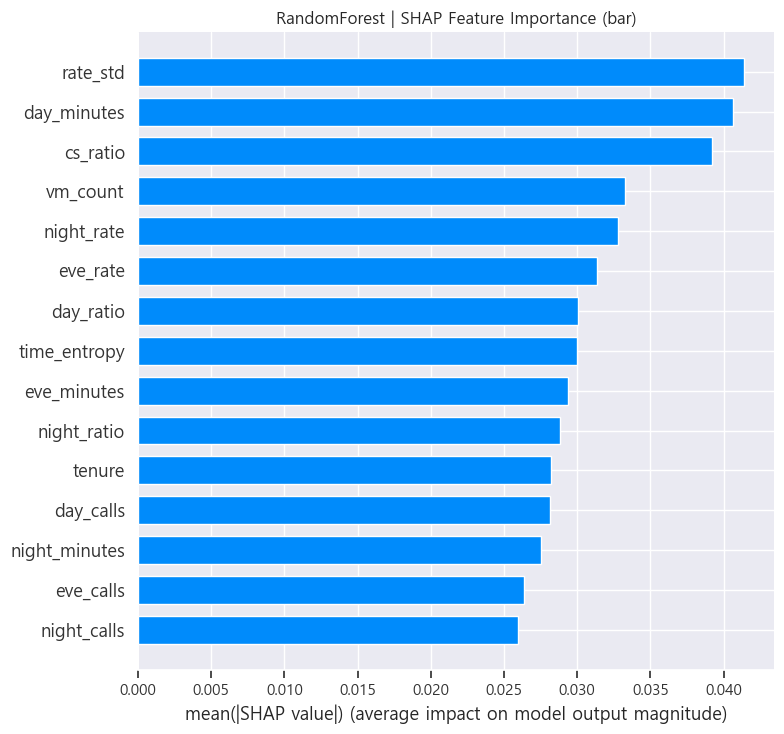

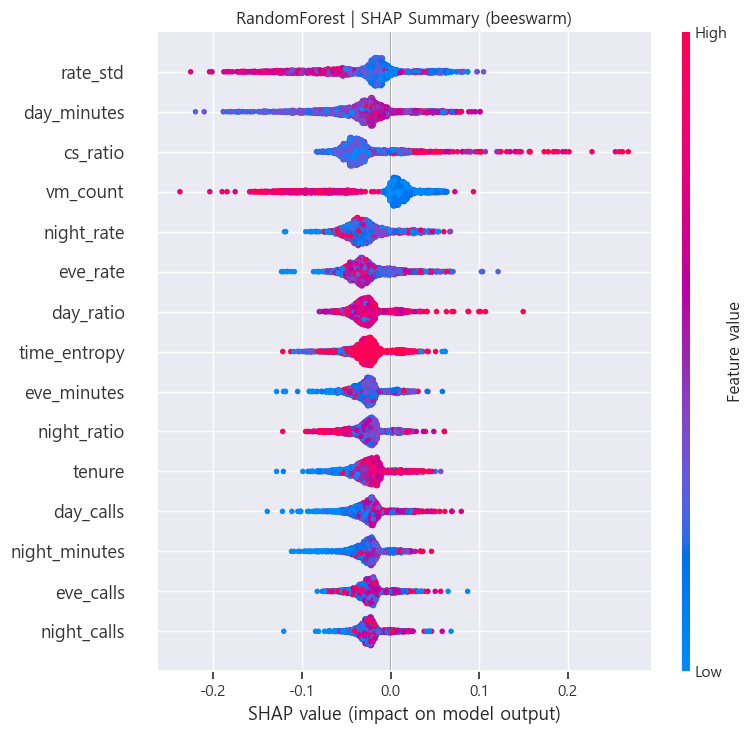

In [110]:
imp_top, imp_all = shap_feature_ranking_report(df, model_type="rf", top_n=20)
# print(imp_top, imp_all)